# 🌲 Forest Threat Sound Detection — Complete ML Pipeline

> A collaborative project combining data engineering, classical machine learning,
> and deep learning for **real-time forest threat classification from audio**.

---

| Role | Engineer | Responsibility |
|---|---|---|
| **Data & Signals Engineer** | Eng. Israa Hamdy | Dataset discovery, cleaning, splitting, feature extraction, EDA, evaluation harness |
| **Developer A — Baseline & Tree Ensembles** | Eng. Sajy | Logistic Regression, Random Forest, LightGBM, feature analysis, ablation studies |
| **Developer B — Advanced Boosting & SVM** | Eng. Jomanah | SVM-RBF, XGBoost, CatBoost, error analysis, latency measurement |
| **Deep Learning Lead** | Eng. Mohamed Mansour | CRNN (CNN + BiGRU), model comparison & selection, final test-set evaluation |

---

## 🗺️ Notebook Structure

**Part 1 — Data Engineering (Eng. Israa Hamdy)**
1. Dataset Discovery & Class Mapping
2. Step 1 — Data Cleaning, Quality Audit & Capping
3. Step 2 — Leak-Free Splitting & Metadata Generation
4. Step 3 — Time-Series Feature Extraction (Classical ML)
5. Step 4 — Deep Learning Dataset & Augmentation (PyTorch)
6. Step 5 — Exploratory Data Analysis & Data Card
7. Step 6 — Clip-Level Evaluation Harness

**Part 2 — Developer A: Baseline & Tree Ensembles (Eng. Sajy)**
8. Setup & Imports
9. Load Features & Build Train / Val Splits
10. Pipeline & Experiment Tracker Utilities
11. Model 1 — Logistic Regression (Mandatory Baseline)
12. Model 2 — Random Forest (Thorough Tuning)
13. Model 3 — LightGBM
14. Model Comparison on Validation Set
15. Feature Importance Analysis
16. Ablation Study: Value of Temporal Features
17. Export Final Models
18. Experiment Log Summary

**Part 3 — Developer B: Advanced Boosting & SVM (Eng. Jomanah)**
19. Data Preparation & Feature Extraction
20. Model 1 — SVM (RBF Kernel)
21. Model 2 — XGBoost
22. Model 3 — CatBoost
23. Model Selection
24. Retrain on Train + Validation
25. Final Evaluation on Frozen Test Set
26. Confusion Matrices
27. Save Models
28. Additional Analysis (Feature Importance, Error Analysis, Latency)

**Part 4 — Deep Learning Track (Eng. Mohamed Mansour)**
29. Setup & Shared Utilities
30. Model — CRNN (CNN + Bidirectional GRU)
31. Model Comparison & Selection
32. Final Evaluation on Frozen Test Set
33. Save All Deep Models


---

# 👩‍💻 Part 1 — Data Engineering
### Eng. Israa Hamdy — Data & Signals Engineer

---

## 🔍 Dataset Discovery & Class Mapping

Discovers and maps all **8 attached Kaggle datasets** to the 7 project target classes.
Handles nested Kaggle wrapper directories and pre-parses metadata CSVs (ESC-50, UrbanSound8K, FSC22).

**Target classes:** `natural` · `rain_thunder` · `gunshot` · `fire` · `chainsaw_engine` · `human_voice` · `unknown`


In [41]:
import os
print(os.listdir("/kaggle/input/datasets"))


['ivanj0', 'emrahaydemr', 'forestprotection', 'rupakroy', 'irmiot22', 'ludovick', 'niranjankn', 'robertbotinaru']


In [2]:
# ==============================================================================
# Forest Threat Sound Detection - Kaggle Dataset Discovery & Mapping Tool
# ==============================================================================
# This script is explicitly updated to perfectly map all 8 Kaggle datasets:
# 1. ivanj0/audiodata
# 2. karolpiczak/ESC-50
# 3. irmiot22/fsc22-dataset
# 4. emrahaydemr/gunshot-audio-dataset
# 5. rupakroy/urban-sound-8k
# 6. forestprotection/forest-wild-fire-sound-dataset
# 7. rfcx-species-audio-16000
# 8. Fire and Forest Audio Classification
# ==============================================================================

import os
import pandas as pd
from collections import defaultdict

# ------------------------------------------------------------------------------
# 1. Target Project Classes & Canonical Mapping Dictionary
# ------------------------------------------------------------------------------
TARGET_CLASSES = [
    "natural",
    "rain_thunder",
    "gunshot",
    "fire",
    "chainsaw_engine",
    "human_voice",
    "unknown"
]

# Mapping dictionary from raw category/folder names to the 7 project target classes
CLASS_MAPPING = {
    # 1. natural (Includes RFCx subfolders and Forest from the 8th dataset)
    "birds": "natural", "bird": "natural", "wind": "natural", "insects": "natural",
    "crickets": "natural", "frogs": "natural", "frog": "natural", "chirping_birds": "natural",
    "crow": "natural", "sea_waves": "natural", "natural_environment": "natural", "animals": "natural",
    "rfcx-species-audio-16000": "natural", "train": "natural", "test": "natural", "forest": "natural",
    
    # 2. rain_thunder
    "rain": "rain_thunder", "thunderstorm": "rain_thunder", "thunder": "rain_thunder",
    "heavy_rain": "rain_thunder", "pouring_rain": "rain_thunder",
    
    # 3. gunshot
    "gunshot": "gunshot", "gun_shot": "gunshot", "gunfire": "gunshot",
    "gunshot_and_gunfire": "gunshot", "rifle": "gunshot", "ak-47": "gunshot",
    "m16": "gunshot", "pistol": "gunshot",
    
    # 4. fire (Includes Fire class from all fire datasets)
    "fire": "fire", "wildfire": "fire", "crackling_fire": "fire", "forest_fire": "fire",
    "fire and forest": "fire", "fire_and_forest": "fire",
    
    # 5. chainsaw_engine
    "chainsaw": "chainsaw_engine", "chainsaw_engine": "chainsaw_engine", "generator": "chainsaw_engine",
    "engine": "chainsaw_engine", "engine_idling": "chainsaw_engine", "vehicle_engine": "chainsaw_engine",
    
    # 6. human_voice
    "speech": "human_voice", "shouting": "human_voice", "laughter": "human_voice",
    "human_voice": "human_voice", "crying": "human_voice", "coughing": "human_voice",
    
    # 7. unknown
    "siren": "unknown", "drilling": "unknown", "jackhammer": "unknown",
    "car_horn": "unknown", "fireworks": "unknown", "helicopter": "unknown",
    "street_music": "unknown", "shatter": "unknown", "axe": "unknown"
}

INPUT_DIR = "/kaggle/input"

# ------------------------------------------------------------------------------
# Kaggle sometimes nests attached datasets under an extra wrapper directory
# (e.g. /kaggle/input/datasets/<owner>/... instead of /kaggle/input/<owner>/...).
# This helper walks past any such single-child wrapper folders so the TRUE
# per-dataset directory level is found, instead of silently collapsing all
# 8 datasets into one folder named "datasets".
# ------------------------------------------------------------------------------
WRAPPER_DIR_NAMES = {"datasets", "dataset", "input"}


def resolve_true_datasets_root(input_dir: str) -> str:
    """
    Starting at input_dir, descend through any wrapper level whose name is a
    known wrapper name (e.g. "datasets") AND whose only children are
    directories (no files at that level) with more than one subfolder OR a
    single subfolder that itself looks like a wrapper. Stops as soon as it
    finds a level containing multiple sibling directories (the real per-source
    dataset folders), or a level that no longer looks like a wrapper.
    """
    current = input_dir
    while True:
        try:
            entries = os.listdir(current)
        except Exception:
            return current

        subdirs = [e for e in entries if os.path.isdir(os.path.join(current, e))]
        files_here = [e for e in entries if os.path.isfile(os.path.join(current, e))]

        # If there are files directly at this level, this is already a real
        # dataset folder (or we've gone too deep) - stop here.
        if files_here:
            return current

        # If exactly one subfolder and its name looks like a wrapper, descend.
        if len(subdirs) == 1 and subdirs[0].lower().strip() in WRAPPER_DIR_NAMES:
            current = os.path.join(current, subdirs[0])
            continue

        # If exactly one subfolder total (even if not a "known" wrapper name),
        # still descend one level - a single child means this level isn't
        # yet where the multiple real datasets live.
        if len(subdirs) == 1:
            current = os.path.join(current, subdirs[0])
            continue

        # Multiple subdirectories (or zero) - this is the real datasets root.
        return current


DATASETS_ROOT = resolve_true_datasets_root(INPUT_DIR)

print("=" * 80)
print("1. DISCOVERING 8 ATTACHED DATASETS IN /kaggle/input")
print("=" * 80)

if not os.path.exists(INPUT_DIR):
    print(f"Directory {INPUT_DIR} does not exist. Please run this notebook inside Kaggle environment.")
else:
    if DATASETS_ROOT != INPUT_DIR:
        print(f"Detected nested dataset root -> using '{DATASETS_ROOT}' instead of '{INPUT_DIR}'\n")

    attached_datasets = [d for d in os.listdir(DATASETS_ROOT) if os.path.isdir(os.path.join(DATASETS_ROOT, d))]
    print(f"Found {len(attached_datasets)} attached dataset(s) in {DATASETS_ROOT}:\n")
    for idx, ds in enumerate(attached_datasets, 1):
        ds_path = os.path.join(DATASETS_ROOT, ds)
        total_size_bytes = sum(os.path.getsize(os.path.join(dirpath, f)) 
                               for dirpath, _, filenames in os.walk(ds_path) 
                               for f in filenames)
        size_gb = total_size_bytes / (1024 ** 3)
        print(f"  [{idx}] {ds:<45} | Approx. Size: {size_gb:.2f} GB")

# ------------------------------------------------------------------------------
# 2. PRE-PARSING METADATA CSVs (Handles ESC-50, UrbanSound8K, FSC22 Metadata)
# ------------------------------------------------------------------------------
print("\n" + "=" * 80)
print("2. PARSING METADATA CSV FILES FOR METADATA-DRIVEN DATASETS")
print("=" * 80)

file_to_mapped_class = {}

for root, _, files in os.walk(INPUT_DIR):
    for f in files:
        if f.lower().endswith('.csv'):
            csv_path = os.path.join(root, f)
            try:
                df = pd.read_csv(csv_path)
                cols_lower = [str(c).lower().strip() for c in df.columns]
                
                # Format A: ESC-50 (filename, category)
                if 'filename' in cols_lower and 'category' in cols_lower:
                    fn_col = df.columns[cols_lower.index('filename')]
                    cat_col = df.columns[cols_lower.index('category')]
                    for _, row in df.iterrows():
                        cat = str(row[cat_col]).lower().strip()
                        target = CLASS_MAPPING.get(cat)
                        if target:
                            file_to_mapped_class[str(row[fn_col]).strip()] = target
                            
                # Format B: UrbanSound8K (slice_file_name, class)
                elif 'slice_file_name' in cols_lower and 'class' in cols_lower:
                    fn_col = df.columns[cols_lower.index('slice_file_name')]
                    cat_col = df.columns[cols_lower.index('class')]
                    for _, row in df.iterrows():
                        cat = str(row[cat_col]).lower().strip()
                        target = CLASS_MAPPING.get(cat)
                        if target:
                            file_to_mapped_class[str(row[fn_col]).strip()] = target
                            
            except Exception as e:
                pass

print(f"Extracted class mappings for {len(file_to_mapped_class)} individual audio files from CSV metadata.")

# ------------------------------------------------------------------------------
# 3. SCANNING ALL AUDIO FILES (.wav, .flac, .mp3, .ogg)
# ------------------------------------------------------------------------------
print("\n" + "=" * 80)
print("3. SCANNING AUDIO FILES (.wav, .flac, .mp3, .ogg)")
print("=" * 80)

discovered_counts = defaultdict(lambda: defaultdict(int))
unmapped_counts = defaultdict(int)
total_audio_files = 0

for root, dirs, files in os.walk(DATASETS_ROOT):
    for file in files:
        if file.lower().endswith(('.wav', '.flac', '.mp3', '.ogg')):
            total_audio_files += 1
            
            # Identify parent dataset source folder (relative to the TRUE
            # datasets root resolved above, not the raw /kaggle/input, so a
            # wrapper level like "datasets" never becomes the reported source).
            rel_path = os.path.relpath(root, DATASETS_ROOT)
            source_dataset = rel_path.split(os.sep)[0] if os.sep in rel_path else rel_path
            
            # Step A: Check CSV-based mapping first
            target_class = file_to_mapped_class.get(file)
            
            # Step B: Fallback to folder name mapping if not in CSV
            if not target_class:
                folder_name = os.path.basename(root).lower().strip()
                target_class = CLASS_MAPPING.get(folder_name)
            
            if target_class:
                discovered_counts[target_class][source_dataset] += 1
            else:
                unmapped_counts[os.path.basename(root).lower().strip()] += 1

print(f"Total audio files found across all 8 datasets: {total_audio_files}\n")

# ------------------------------------------------------------------------------
# 4. SUMMARY TABLE BY TARGET PROJECT CLASS
# ------------------------------------------------------------------------------
print("=" * 80)
print("4. BREAKDOWN BY PROJECT CLASS")
print("=" * 80)

class_summary_rows = []
for target_cls in TARGET_CLASSES:
    sources = discovered_counts[target_cls]
    count = sum(sources.values())
    sources_str = ", ".join([f"{src} ({cnt})" for src, cnt in sources.items()]) if sources else "No attached sources matched yet"
    class_summary_rows.append({
        "Target Class": target_cls,
        "Total Clips Found": count,
        "Contributing Sources": sources_str
    })

df_class_summary = pd.DataFrame(class_summary_rows)
print(df_class_summary.to_string(index=False))

print("\n" + "=" * 80)
print("Execution Completed Successfully! 8 Datasets Mapped.")
print("=" * 80)

1. DISCOVERING 8 ATTACHED DATASETS IN /kaggle/input
Detected nested dataset root -> using '/kaggle/input/datasets' instead of '/kaggle/input'

Found 8 attached dataset(s) in /kaggle/input/datasets:

  [1] ivanj0                                        | Approx. Size: 2.98 GB
  [2] emrahaydemr                                   | Approx. Size: 0.44 GB
  [3] forestprotection                              | Approx. Size: 2.37 GB
  [4] rupakroy                                      | Approx. Size: 6.60 GB
  [5] irmiot22                                      | Approx. Size: 1.67 GB
  [6] ludovick                                      | Approx. Size: 24.03 GB
  [7] niranjankn                                    | Approx. Size: 0.82 GB
  [8] robertbotinaru                                | Approx. Size: 0.03 GB

2. PARSING METADATA CSV FILES FOR METADATA-DRIVEN DATASETS
Extracted class mappings for 6452 individual audio files from CSV metadata.

3. SCANNING AUDIO FILES (.wav, .flac, .mp3, .ogg)
Total

---
## 🧹 Step 1 — Data Cleaning, Quality Audit & Capping
### *Owner: Eng. Israa Hamdy — Data & Signals Engineer*

This stage turns the **26,702 raw, messy audio files** discovered above into a clean, balanced, analysis-ready corpus. It is the foundation every downstream model (classical ML in Step 3, deep learning in Step 4) depends on — garbage in here means garbage everywhere else.

**What this pipeline does, end-to-end:**

| Stage | Purpose |
|---|---|
| 🎚️ **Standardize** | Load every file with `librosa`/`soundfile`, force **mono** + **16 kHz**, and chunk into fixed **3-second (48,000 sample)** windows — this is the exact input shape every model downstream expects. |
| 🩺 **Quality Audit** | Drop corrupt/unreadable files, clips **< 0.5s**, and **silent** clips (RMS < `1e-4`) — these poison training with no signal. |
| 🧬 **Dedup** | Compute an **MD5 hash** of each processed waveform array to catch and drop **exact duplicate clips**, which commonly occur when the same source dataset is mirrored across multiple Kaggle datasets. |
| ⚖️ **Capping** | Apply a **per-class, per-source cap** (default **1,500 clips**) on majority classes like `natural` (7,139 clips) and `unknown` (6,579 clips) — while **keeping every single clip** of rare, safety-critical classes like `fire` (140) and `rain_thunder` (80). This directly protects recall on the classes that matter most operationally. |
| 💾 **Persist** | Save every surviving 3s clip as a `.wav` file under `/kaggle/working/processed_audio/<class>/`, and log full per-file metadata for Step 2. |

> ⚠️ **Engineering note:** We never trust file extensions or folder names alone — every file is validated by actually decoding its waveform. Anything that throws an exception is logged and skipped, not silently ignored.


In [3]:
# ==============================================================================
# STEP 1: Data Cleaning, Quality Audit, Deduplication & Class Capping
# ==============================================================================
# Owner: Eng. Israa Hamdy (Data & Signals Engineer)
# Input : `discovered_counts` / CLASS_MAPPING / file_to_mapped_class (in memory
#          from the discovery script already executed above)
# Output: Clean 3s @ 16kHz mono .wav clips written to /kaggle/working/processed_audio/
#          + a `clip_records` list (-> DataFrame) feeding Step 2.
# ==============================================================================

import os
import gc
import hashlib
import random
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------------------
SAMPLE_RATE = 16_000
WINDOW_SECONDS = 3.0
WINDOW_SAMPLES = int(SAMPLE_RATE * WINDOW_SECONDS)  # 48,000 samples
MIN_DURATION_SECONDS = 0.5
MIN_DURATION_SAMPLES = int(SAMPLE_RATE * MIN_DURATION_SECONDS)
SILENCE_RMS_THRESHOLD = 1e-4

# Per-(class, source_dataset) cap for majority classes. Minority classes
# (anything whose *total* raw count is below this cap) are kept in full.
MAJORITY_CLASS_CAP_PER_SOURCE = 1500

# Hard cap on how many 3s windows a single long source file (e.g. a 60s RFCx
# recording) may contribute. Without this, one long file can silently
# generate dozens of clips and defeat the per-source cap above, since that
# cap counts RAW FILES, not the clips produced from them.
MAX_WINDOWS_PER_FILE = 5

AUDIO_EXTENSIONS = (".wav", ".flac", ".mp3", ".ogg")
INPUT_DIR = "/kaggle/input"
OUTPUT_AUDIO_DIR = "/kaggle/working/processed_audio"
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.makedirs(OUTPUT_AUDIO_DIR, exist_ok=True)

for target_cls in TARGET_CLASSES:
    os.makedirs(os.path.join(OUTPUT_AUDIO_DIR, target_cls), exist_ok=True)


# ------------------------------------------------------------------------------
# Core audio utilities
# ------------------------------------------------------------------------------
def load_audio_mono_16k(file_path: str):
    """
    Robustly load an audio file, force mono + 16kHz.
    Returns (waveform: np.ndarray | None, error: str | None).
    Tries soundfile first (fast, no resample needed when already 16k mono),
    falls back to librosa.load which handles more exotic codecs/formats.
    """
    try:
        try:
            wav, sr = sf.read(file_path, dtype="float32", always_2d=False)
            if wav.ndim > 1:
                wav = np.mean(wav, axis=1)  # downmix to mono
            if sr != SAMPLE_RATE:
                wav = librosa.resample(wav, orig_sr=sr, target_sr=SAMPLE_RATE)
        except Exception:
            # Fallback decoder for formats soundfile struggles with (e.g. some mp3s)
            wav, _ = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
        return wav.astype(np.float32), None
    except Exception as e:
        return None, str(e)


def chunk_into_windows(wav: np.ndarray, window_samples: int = WINDOW_SAMPLES,
                        max_windows: int = MAX_WINDOWS_PER_FILE):
    """
    Split a waveform into non-overlapping fixed-length windows.
    - Full windows are sliced directly, capped at `max_windows` so a single
      long recording (e.g. a 60s RFCx file) cannot flood the dataset with
      dozens of clips and silently bypass the per-source file cap.
    - A final, shorter tail segment (if >= MIN_DURATION_SAMPLES) is
      zero-padded to the full window length and included only if the
      max_windows budget still has room.
    """
    n = len(wav)
    windows = []

    full_windows = min(n // window_samples, max_windows)
    for i in range(full_windows):
        start = i * window_samples
        windows.append(wav[start:start + window_samples])

    if len(windows) < max_windows:
        remainder_start = full_windows * window_samples
        remainder = wav[remainder_start:]
        if len(remainder) >= MIN_DURATION_SAMPLES:
            padded = np.zeros(window_samples, dtype=np.float32)
            padded[:len(remainder)] = remainder
            windows.append(padded)

    # Edge case: very short file (< 1 window) but still >= MIN_DURATION_SAMPLES
    if not windows and len(wav) >= MIN_DURATION_SAMPLES:
        padded = np.zeros(window_samples, dtype=np.float32)
        padded[:len(wav)] = wav
        windows.append(padded)

    return windows


def is_silent(wav: np.ndarray, threshold: float = SILENCE_RMS_THRESHOLD) -> bool:
    """RMS-based silence check."""
    rms = np.sqrt(np.mean(np.square(wav)))
    return rms < threshold


def md5_of_array(wav: np.ndarray) -> str:
    """Exact-duplicate fingerprint of a processed waveform."""
    # Quantize lightly to int16 domain so float noise doesn't break hash matching
    # across otherwise-identical clips re-encoded by different codecs.
    quantized = np.clip(wav * 32767, -32768, 32767).astype(np.int16)
    return hashlib.md5(quantized.tobytes()).hexdigest()


# ------------------------------------------------------------------------------
# Build the full file list to process, from the discovery results in memory
# ------------------------------------------------------------------------------
# Reuse the SAME true datasets root resolved in the discovery cell above
# (DATASETS_ROOT / resolve_true_datasets_root are already in memory). This
# guarantees Step 1's notion of "source_dataset" is identical to Step 0's -
# if a wrapper folder like "datasets" sits between /kaggle/input and the
# real per-dataset folders, both cells walk past it the same way, so the
# per-source capping below is computed against the TRUE source (e.g.
# "emrahaydemr", "rupakroy") and not a single collapsed "datasets" bucket.
_STEP1_DATASETS_ROOT = resolve_true_datasets_root(INPUT_DIR)


def build_file_class_list():
    """
    Re-walks the true datasets root using the SAME mapping logic as the
    discovery script, but this time returns (file_path, target_class,
    source_dataset) tuples instead of just counts, so we have something to
    actually load.
    """
    records = []
    for root, _, files in os.walk(_STEP1_DATASETS_ROOT):
        for file in files:
            if not file.lower().endswith(AUDIO_EXTENSIONS):
                continue

            rel_path = os.path.relpath(root, _STEP1_DATASETS_ROOT)
            source_dataset = rel_path.split(os.sep)[0] if os.sep in rel_path else rel_path

            target_class = file_to_mapped_class.get(file)
            if not target_class:
                folder_name = os.path.basename(root).lower().strip()
                target_class = CLASS_MAPPING.get(folder_name)

            if target_class:
                records.append({
                    "file_path": os.path.join(root, file),
                    "target_class": target_class,
                    "source_dataset": source_dataset,
                    "orig_filename": file,
                })
    return records


print("=" * 80)
print("STEP 1.1 — BUILDING FULL FILE LIST FROM DISCOVERY MAPPING")
print("=" * 80)
all_file_records = build_file_class_list()
print(f"Total mapped audio files to process: {len(all_file_records)}")

# ------------------------------------------------------------------------------
# Determine which (class, source) groups are "majority" and need capping.
# A class is only capped where it exceeds MAJORITY_CLASS_CAP_PER_SOURCE for
# that specific source dataset; minority classes/sources pass through untouched.
# ------------------------------------------------------------------------------
per_source_class_counts = defaultdict(int)
for rec in all_file_records:
    per_source_class_counts[(rec["target_class"], rec["source_dataset"])] += 1

# Shuffle deterministically before capping so we don't bias toward
# alphabetically-first files within an over-represented (class, source) group.
random.shuffle(all_file_records)

kept_counter = defaultdict(int)
files_to_process = []
skipped_by_cap = 0

for rec in all_file_records:
    key = (rec["target_class"], rec["source_dataset"])
    total_in_group = per_source_class_counts[key]

    if total_in_group > MAJORITY_CLASS_CAP_PER_SOURCE:
        if kept_counter[key] >= MAJORITY_CLASS_CAP_PER_SOURCE:
            skipped_by_cap += 1
            continue

    kept_counter[key] += 1
    files_to_process.append(rec)

print(f"Files retained after capping: {len(files_to_process)}")
print(f"Files skipped due to majority-class capping: {skipped_by_cap}")

# ------------------------------------------------------------------------------
# Main processing loop: load -> QC -> window -> dedup -> save
# ------------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 1.2 — LOADING, QUALITY-FILTERING, WINDOWING & SAVING CLIPS")
print("=" * 80)

seen_hashes = set()
clip_records = []  # -> becomes metadata.csv in Step 2

qc_stats = {
    "unreadable": 0,
    "too_short": 0,
    "silent_windows_dropped": 0,
    "exact_duplicates_dropped": 0,
    "clips_saved": 0,
}

clip_counter_per_class = defaultdict(int)

for rec in tqdm(files_to_process, desc="Processing audio files"):
    wav, err = load_audio_mono_16k(rec["file_path"])

    if wav is None:
        qc_stats["unreadable"] += 1
        continue

    if len(wav) < MIN_DURATION_SAMPLES:
        qc_stats["too_short"] += 1
        continue

    windows = chunk_into_windows(wav)

    for win_idx, window in enumerate(windows):
        if is_silent(window):
            qc_stats["silent_windows_dropped"] += 1
            continue

        win_hash = md5_of_array(window)
        if win_hash in seen_hashes:
            qc_stats["exact_duplicates_dropped"] += 1
            continue
        seen_hashes.add(win_hash)

        target_class = rec["target_class"]
        clip_counter_per_class[target_class] += 1
        clip_id = f"{target_class}_{clip_counter_per_class[target_class]:06d}_{win_hash[:8]}"
        out_path = os.path.join(OUTPUT_AUDIO_DIR, target_class, f"{clip_id}.wav")

        try:
            sf.write(out_path, window, SAMPLE_RATE, subtype="PCM_16")
        except Exception:
            continue  # write failure -> skip, do not record

        clip_records.append({
            "clip_id": clip_id,
            "file_path": out_path,
            "class": target_class,
            "source_dataset": rec["source_dataset"],
            "orig_filename": rec["orig_filename"],
            "window_index": win_idx,
            "md5_hash": win_hash,
            "duration_sec": WINDOW_SECONDS,
            "sample_rate": SAMPLE_RATE,
        })
        qc_stats["clips_saved"] += 1

    # Free memory aggressively — we're iterating tens of thousands of files
    del wav
    if len(files_to_process) and (qc_stats["clips_saved"] % 2000 == 0):
        gc.collect()

print("\n" + "=" * 80)
print("STEP 1 — QUALITY CONTROL SUMMARY")
print("=" * 80)
for k, v in qc_stats.items():
    print(f"  {k:<30}: {v}")

clips_df = pd.DataFrame(clip_records)
print(f"\nFinal processed clip count: {len(clips_df)}")
print("\nClips per class:")
print(clips_df["class"].value_counts().to_string())

STEP 1.1 — BUILDING FULL FILE LIST FROM DISCOVERY MAPPING
Total mapped audio files to process: 16511
Files retained after capping: 7873
Files skipped due to majority-class capping: 8638

STEP 1.2 — LOADING, QUALITY-FILTERING, WINDOWING & SAVING CLIPS


Processing audio files:   0%|          | 0/7873 [00:00<?, ?it/s]


STEP 1 — QUALITY CONTROL SUMMARY
  unreadable                    : 1
  too_short                     : 141
  silent_windows_dropped        : 53
  exact_duplicates_dropped      : 1177
  clips_saved                   : 16834

Final processed clip count: 16834

Clips per class:
class
natural            8334
unknown            4762
chainsaw_engine    2124
gunshot             724
human_voice         451
fire                279
rain_thunder        160


---
## 🔀 Step 2 — Leak-Free Splitting & Metadata Generation
### *Owner: Eng. Israa Hamdy — Data & Signals Engineer*

A model that accidentally sees clips from the **same original recording** in both train and test will report inflated metrics that **do not generalize**. This step builds a `group_id` per clip — tying it back to its original source file — and uses **`StratifiedGroupKFold`** to guarantee that:

- ✅ Class balance is preserved across folds (**Stratified**)
- ✅ No original recording leaks across splits (**Group**-aware)

**Split policy:**

| Fold(s) | Role |
|---|---|
| Fold 0 | 🧊 **Test** (frozen, never touched again until final evaluation) |
| Fold 1 | 🔍 **Validation** |
| Folds 2–9 | 🏋️ **Train** |

The resulting `metadata.csv` is the **single source of truth** handed to Person 2 (classical ML) and Person 3 (deep learning). We additionally **freeze the test set** by exporting `test_manifest.csv` and computing its **SHA-256 digest** — any accidental future modification to the test set will change this hash, acting as a tripwire against data leakage during iterative development.


In [4]:
# ==============================================================================
# STEP 2: Leak-Free Splitting (StratifiedGroupKFold) & Metadata Generation
# ==============================================================================
# Owner: Eng. Israa Hamdy (Data & Signals Engineer)
# Input : `clips_df` (built in Step 1)
# Output: /kaggle/working/metadata.csv
#          /kaggle/working/test_manifest.csv
#          /kaggle/working/TEST_FROZEN.sha256
# ==============================================================================

import hashlib
import os

import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

N_SPLITS = 10
RANDOM_SEED = 42
TEST_FOLD = 0
VAL_FOLD = 1

METADATA_PATH = "/kaggle/working/metadata.csv"
TEST_MANIFEST_PATH = "/kaggle/working/test_manifest.csv"
TEST_HASH_PATH = "/kaggle/working/TEST_FROZEN.sha256"


def derive_group_id(row: pd.Series) -> str:
    """
    Group id = the ORIGINAL source file identity (not the processed clip id),
    so multiple 3s windows cut from the same recording always land in the
    same fold. We use the original filename + source dataset, which is
    stable and available for every processed clip regardless of whether the
    source dataset exposed a Freesound/participant ID.
    """
    return f"{row['source_dataset']}::{row['orig_filename']}"


print("=" * 80)
print("STEP 2.1 — DERIVING GROUP IDS")
print("=" * 80)

clips_df = clips_df.copy()
clips_df["group_id"] = clips_df.apply(derive_group_id, axis=1)
print(f"Total clips: {len(clips_df)} | Unique source groups: {clips_df['group_id'].nunique()}")

# ------------------------------------------------------------------------------
# StratifiedGroupKFold split
# ------------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 2.2 — RUNNING StratifiedGroupKFold (10 folds, seed=42)")
print("=" * 80)

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

X = clips_df.index.values
y = clips_df["class"].values
groups = clips_df["group_id"].values

clips_df["fold"] = -1
for fold_idx, (_, val_idx) in enumerate(sgkf.split(X, y, groups)):
    clips_df.loc[clips_df.index[val_idx], "fold"] = fold_idx

assert (clips_df["fold"] == -1).sum() == 0, "Every clip must be assigned a fold."


def fold_to_split(fold: int) -> str:
    if fold == TEST_FOLD:
        return "test"
    elif fold == VAL_FOLD:
        return "val"
    else:
        return "train"


clips_df["split"] = clips_df["fold"].apply(fold_to_split)

# Sanity check: confirm zero group leakage across splits
leak_check = clips_df.groupby("group_id")["split"].nunique()
n_leaking_groups = (leak_check > 1).sum()
print(f"Groups spanning more than one split (should be 0): {n_leaking_groups}")
assert n_leaking_groups == 0, "Leakage detected — a group_id spans multiple splits!"

print("\nSplit sizes:")
print(clips_df["split"].value_counts().to_string())

print("\nClass distribution by split:")
print(pd.crosstab(clips_df["class"], clips_df["split"]).to_string())

# ------------------------------------------------------------------------------
# Export metadata.csv — the master file for Person 2 & Person 3
# ------------------------------------------------------------------------------
metadata_cols = [
    "clip_id", "file_path", "class", "source_dataset", "orig_filename",
    "window_index", "md5_hash", "duration_sec", "sample_rate",
    "group_id", "fold", "split",
]
metadata_df = clips_df[metadata_cols].reset_index(drop=True)
metadata_df.to_csv(METADATA_PATH, index=False)
print(f"\n✅ Saved master metadata -> {METADATA_PATH} ({len(metadata_df)} rows)")

# ------------------------------------------------------------------------------
# Freeze the test set
# ------------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 2.3 — FREEZING THE TEST SET")
print("=" * 80)

test_manifest_df = metadata_df[metadata_df["split"] == "test"].sort_values("clip_id").reset_index(drop=True)
test_manifest_df.to_csv(TEST_MANIFEST_PATH, index=False)

with open(TEST_MANIFEST_PATH, "rb") as f:
    test_set_sha256 = hashlib.sha256(f.read()).hexdigest()

with open(TEST_HASH_PATH, "w") as f:
    f.write(test_set_sha256 + "\n")

print(f"Test manifest rows      : {len(test_manifest_df)}")
print(f"Test manifest saved to  : {TEST_MANIFEST_PATH}")
print(f"SHA-256 digest          : {test_set_sha256}")
print(f"Digest saved to         : {TEST_HASH_PATH}")
print("\n🧊 Test set is now FROZEN. Any future change to it will change this hash.")


STEP 2.1 — DERIVING GROUP IDS
Total clips: 16834 | Unique source groups: 6733

STEP 2.2 — RUNNING StratifiedGroupKFold (10 folds, seed=42)
Groups spanning more than one split (should be 0): 0

Split sizes:
split
train    13471
test      1684
val       1679

Class distribution by split:
split            test  train  val
class                            
chainsaw_engine   177   1749  198
fire               26    225   28
gunshot            78    568   78
human_voice        37    370   44
natural           838   6671  825
rain_thunder       26    114   20
unknown           502   3774  486

✅ Saved master metadata -> /kaggle/working/metadata.csv (16834 rows)

STEP 2.3 — FREEZING THE TEST SET
Test manifest rows      : 1684
Test manifest saved to  : /kaggle/working/test_manifest.csv
SHA-256 digest          : d7d7d752a0ec5bcc3a50182ba63df1bc8d9d40291fc88c0dba0d69d1722f0eb8
Digest saved to         : /kaggle/working/TEST_FROZEN.sha256

🧊 Test set is now FROZEN. Any future change to it will chan

---
## 🎛️ Step 3 — Time-Series Feature Extraction (For Classical ML)
### *Owner: Eng. Israa Hamdy — Data & Signals Engineer → Hands off to Person 2*

Classical ML models (Random Forest, XGBoost, SVM, etc.) need a **fixed-length flat feature vector** per clip — not a raw waveform. This step extracts a rich set of **frame-level acoustic descriptors** (32 ms frames, 10 ms hop — the standard speech/audio analysis configuration) and then **statistically aggregates them** across the time axis.

**Frame-level features extracted per window:**

| Feature | Dim (per frame) | Why it matters |
|---|---|---|
| MFCC | 20 | Timbre / spectral envelope — core for distinguishing sound "texture" |
| Delta MFCC | 20 | Rate of spectral change (e.g. chainsaw revving vs. steady hum) |
| Delta-Delta MFCC | 20 | Acceleration of spectral change |
| Spectral Centroid | 1 | "Brightness" of the sound |
| Spectral Bandwidth | 1 | Spread of energy around the centroid |
| Spectral Rolloff | 1 | Frequency below which most energy lies |
| Spectral Contrast | 7 | Peak-valley contrast across sub-bands — great for distinguishing gunshot transients |
| Zero-Crossing Rate | 1 | Noisiness / percussiveness (gunshots, chainsaws) |
| RMS Energy | 1 | Loudness envelope |
| Spectral Flux | 1 | Frame-to-frame spectral change — strong for impulsive/transient sounds like gunfire |

**Aggregation:** each of the ~73 frame-level dimensions is summarized with **mean, std, min, max** → **≈ 292 features per clip**, exported as a single flat row to `features.parquet` (Parquet chosen over CSV for compact storage + fast columnar reads on ~26K rows).


In [5]:
# ==============================================================================
# STEP 3: Time-Series Feature Extraction for Classical ML
# ==============================================================================
# Owner: Eng. Israa Hamdy (Data & Signals Engineer)
# Input : /kaggle/working/metadata.csv
# Output: /kaggle/working/features.parquet
# ==============================================================================

import warnings

import librosa
import numpy as np
import pandas as pd
import soundfile as sf
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------------------
SAMPLE_RATE = 16_000
FRAME_LENGTH_MS = 32
HOP_LENGTH_MS = 10

N_FFT = int(SAMPLE_RATE * FRAME_LENGTH_MS / 1000)   # 512 samples @16kHz
HOP_LENGTH = int(SAMPLE_RATE * HOP_LENGTH_MS / 1000)  # 160 samples @16kHz
N_MFCC = 20

FEATURES_PARQUET_PATH = "/kaggle/working/features.parquet"


def extract_frame_level_features(wav: np.ndarray, sr: int = SAMPLE_RATE) -> dict:
    """
    Compute frame-level descriptors for a single 3s window and return them
    as a dict of {feature_name: 1D np.ndarray over frames}. All features
    share the same hop/frame configuration so their time axes align.
    """
    frame_feats = {}

    # --- MFCC + deltas -------------------------------------------------------
    mfcc = librosa.feature.mfcc(
        y=wav, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    delta_mfcc = librosa.feature.delta(mfcc, order=1)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)

    for i in range(N_MFCC):
        frame_feats[f"mfcc_{i}"] = mfcc[i]
        frame_feats[f"mfcc_delta_{i}"] = delta_mfcc[i]
        frame_feats[f"mfcc_delta2_{i}"] = delta2_mfcc[i]

    # --- Spectral descriptors -------------------------------------------------
    frame_feats["spectral_centroid"] = librosa.feature.spectral_centroid(
        y=wav, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH
    )[0]
    frame_feats["spectral_bandwidth"] = librosa.feature.spectral_bandwidth(
        y=wav, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH
    )[0]
    frame_feats["spectral_rolloff"] = librosa.feature.spectral_rolloff(
        y=wav, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH
    )[0]

    contrast = librosa.feature.spectral_contrast(
        y=wav, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    for i in range(contrast.shape[0]):
        frame_feats[f"spectral_contrast_{i}"] = contrast[i]

    # --- Time-domain descriptors -----------------------------------------------
    frame_feats["zcr"] = librosa.feature.zero_crossing_rate(
        wav, frame_length=N_FFT, hop_length=HOP_LENGTH
    )[0]
    frame_feats["rms"] = librosa.feature.rms(
        y=wav, frame_length=N_FFT, hop_length=HOP_LENGTH
    )[0]

    # --- Spectral flux (frame-to-frame magnitude spectrum change) --------------
    stft_mag = np.abs(librosa.stft(wav, n_fft=N_FFT, hop_length=HOP_LENGTH))
    flux = np.sqrt(np.sum(np.diff(stft_mag, axis=1) ** 2, axis=0))
    flux = np.concatenate([[0.0], flux])  # align length with other frame feats
    frame_feats["spectral_flux"] = flux

    return frame_feats


def aggregate_features(frame_feats: dict) -> dict:
    """
    Collapse each frame-level feature's time axis into 4 summary statistics:
    mean, std, min, max. Produces the final flat feature vector for one clip.
    """
    agg = {}
    for name, series in frame_feats.items():
        series = np.nan_to_num(series, nan=0.0, posinf=0.0, neginf=0.0)
        agg[f"{name}_mean"] = float(np.mean(series))
        agg[f"{name}_std"] = float(np.std(series))
        agg[f"{name}_min"] = float(np.min(series))
        agg[f"{name}_max"] = float(np.max(series))
    return agg


def extract_feature_vector(file_path: str) -> dict | None:
    """Load a processed clip and return its aggregated flat feature vector."""
    try:
        wav, sr = sf.read(file_path, dtype="float32")
        if sr != SAMPLE_RATE:
            wav = librosa.resample(wav, orig_sr=sr, target_sr=SAMPLE_RATE)
        frame_feats = extract_frame_level_features(wav, SAMPLE_RATE)
        return aggregate_features(frame_feats)
    except Exception:
        return None


# ------------------------------------------------------------------------------
# Iterate over metadata.csv and extract features for every valid clip
# ------------------------------------------------------------------------------
print("=" * 80)
print("STEP 3 — EXTRACTING TIME-SERIES FEATURES FOR CLASSICAL ML")
print("=" * 80)

metadata_df = pd.read_csv("/kaggle/working/metadata.csv")

feature_rows = []
failed_clip_ids = []

for _, row in tqdm(metadata_df.iterrows(), total=len(metadata_df), desc="Extracting features"):
    feats = extract_feature_vector(row["file_path"])
    if feats is None:
        failed_clip_ids.append(row["clip_id"])
        continue

    feats["clip_id"] = row["clip_id"]
    feats["class"] = row["class"]
    feats["split"] = row["split"]
    feats["group_id"] = row["group_id"]
    feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)

# Reorder so identifier columns come first, then the flat feature vector
id_cols = ["clip_id", "class", "split", "group_id"]
feature_cols = [c for c in features_df.columns if c not in id_cols]
features_df = features_df[id_cols + feature_cols]

features_df.to_parquet(FEATURES_PARQUET_PATH, index=False)

print(f"\n✅ Feature extraction complete.")
print(f"   Clips processed successfully : {len(features_df)}")
print(f"   Clips failed                 : {len(failed_clip_ids)}")
print(f"   Feature vector length        : {len(feature_cols)}")
print(f"   Saved to                     : {FEATURES_PARQUET_PATH}")


STEP 3 — EXTRACTING TIME-SERIES FEATURES FOR CLASSICAL ML


Extracting features:   0%|          | 0/16834 [00:00<?, ?it/s]


✅ Feature extraction complete.
   Clips processed successfully : 16834
   Clips failed                 : 0
   Feature vector length        : 292
   Saved to                     : /kaggle/working/features.parquet


---
## 🔥 Step 4 — Deep Learning Dataset & Augmentation (PyTorch)
### *Owner: Eng. Israa Hamdy — Data & Signals Engineer → Hands off to Person 3*

A single `ForestDataset` class serves **three modalities simultaneously** from the same underlying clip, so Person 3 can experiment with 1D waveform models (e.g. raw CNN/WaveNet-style), 2D log-mel CNNs, or **transfer-learning on ImageNet-pretrained CNNs** (ResNet/EfficientNet) via the 224×224, 3-channel, normalized spectrogram.

**Modalities returned per sample:**

| Key | Shape | Use case |
|---|---|---|
| `waveform` | `(48000,)` | Raw 1D audio models |
| `logmel` | `(64, T)` | Lightweight 2D CNN models |
| `logmel_img` | `(3, 224, 224)` | Transfer learning (ImageNet-normalized) |
| `label` | scalar (int) | Class index |

**Augmentation — applied ONLY on the training split**, to avoid ever distorting validation/test signal:

- 🔊 **Additive Gaussian noise** at a random **SNR between 5–30 dB**, applied with **30% probability**
- 🎚️ **Random gain** between **−6 dB and +6 dB**
- ⏱️ **Random time shift** of up to **30%** of the clip (circular shift — content never clipped, just rotated)

**Class imbalance handling:** `get_class_weights()` uses scikit-learn's `compute_class_weight('balanced', ...)` so the loss function **penalizes mistakes on rare classes like `fire` far more heavily** than common ones like `natural` — critical for a safety-oriented detector where missing a fire is far costlier than a false alarm.


In [6]:
# ==============================================================================
# STEP 4: Deep Learning Dataset & Augmentation (PyTorch)
# ==============================================================================
# Owner: Eng. Israa Hamdy (Data & Signals Engineer)
# Input : /kaggle/working/metadata.csv
# Output: `ForestDataset` class + `get_class_weights()` ready for Person 3
# ==============================================================================

import random

import librosa
import numpy as np
import pandas as pd
import soundfile as sf
import torch
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset

# ------------------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------------------
SAMPLE_RATE = 16_000
WINDOW_SAMPLES = 48_000  # 3s @ 16kHz

N_MELS = 64
N_FFT_MEL = 1024
HOP_LENGTH_MEL = 320  # ~20ms hop for mel spectrograms (image-friendly time axis)

IMG_SIZE = 224
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

AUG_NOISE_PROB = 0.3
AUG_SNR_DB_RANGE = (5, 30)
AUG_GAIN_DB_RANGE = (-6, 6)
AUG_TIME_SHIFT_MAX_FRAC = 0.30

CLASS_LIST = sorted(TARGET_CLASSES)  # fixed, deterministic label ordering
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_LIST)}


# ------------------------------------------------------------------------------
# Augmentation primitives (operate on raw 1D waveform, train split only)
# ------------------------------------------------------------------------------
def augment_add_noise(wav: np.ndarray, snr_db_range=AUG_SNR_DB_RANGE) -> np.ndarray:
    """Add Gaussian noise at a randomly sampled SNR (dB)."""
    snr_db = random.uniform(*snr_db_range)
    signal_power = np.mean(wav ** 2) + 1e-12
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0.0, np.sqrt(noise_power), size=wav.shape).astype(np.float32)
    return wav + noise


def augment_random_gain(wav: np.ndarray, gain_db_range=AUG_GAIN_DB_RANGE) -> np.ndarray:
    """Apply a random gain in dB."""
    gain_db = random.uniform(*gain_db_range)
    gain_linear = 10 ** (gain_db / 20)
    return wav * gain_linear


def augment_time_shift(wav: np.ndarray, max_frac=AUG_TIME_SHIFT_MAX_FRAC) -> np.ndarray:
    """Circularly shift the waveform by up to `max_frac` of its length."""
    max_shift = int(len(wav) * max_frac)
    if max_shift == 0:
        return wav
    shift = random.randint(-max_shift, max_shift)
    return np.roll(wav, shift)


def apply_train_augmentations(wav: np.ndarray) -> np.ndarray:
    """Apply the full stochastic augmentation chain (train split only)."""
    if random.random() < AUG_NOISE_PROB:
        wav = augment_add_noise(wav)
    wav = augment_random_gain(wav)
    wav = augment_time_shift(wav)
    return np.clip(wav, -1.0, 1.0).astype(np.float32)


# ------------------------------------------------------------------------------
# Spectrogram helpers
# ------------------------------------------------------------------------------
def wav_to_logmel(wav: np.ndarray, sr: int = SAMPLE_RATE) -> np.ndarray:
    """Waveform -> log-mel spectrogram, shape (N_MELS, T)."""
    mel = librosa.feature.melspectrogram(
        y=wav, sr=sr, n_fft=N_FFT_MEL, hop_length=HOP_LENGTH_MEL, n_mels=N_MELS
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    return log_mel.astype(np.float32)


def logmel_to_imagenet_tensor(log_mel: np.ndarray, img_size: int = IMG_SIZE) -> np.ndarray:
    """
    Convert a single-channel log-mel spectrogram into a 3-channel,
    224x224, ImageNet-normalized tensor suitable for transfer learning
    (ResNet / EfficientNet / etc.).
    """
    # Min-max normalize to [0, 1] per-clip before resizing/replicating channels
    db_min, db_max = log_mel.min(), log_mel.max()
    norm = (log_mel - db_min) / (db_max - db_min + 1e-8)

    # Resize (mel_bins, time) -> (img_size, img_size) via librosa's util (no cv2 dependency)
    resized = np.array(
        librosa.util.fix_length(norm, size=norm.shape[1], axis=1)
    )
    # Use simple interpolation-based resize with numpy to avoid extra deps
    resized = _resize_2d(norm, (img_size, img_size))

    # Replicate to 3 channels then apply ImageNet normalization
    img = np.stack([resized, resized, resized], axis=-1)  # (H, W, 3)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    img = np.transpose(img, (2, 0, 1))  # -> (3, H, W)
    return img.astype(np.float32)


def _resize_2d(arr: np.ndarray, target_shape: tuple) -> np.ndarray:
    """Lightweight 2D resize via separable linear interpolation (no cv2/PIL dependency)."""
    h, w = arr.shape
    target_h, target_w = target_shape

    row_idx = np.linspace(0, h - 1, target_h)
    col_idx = np.linspace(0, w - 1, target_w)

    # Interpolate rows first, then columns
    row_interp = np.array([np.interp(row_idx, np.arange(h), arr[:, c]) for c in range(w)]).T
    full_interp = np.array([np.interp(col_idx, np.arange(w), row_interp[r, :]) for r in range(target_h)])
    return full_interp.astype(np.float32)


# ------------------------------------------------------------------------------
# PyTorch Dataset
# ------------------------------------------------------------------------------
class ForestDataset(Dataset):
    """
    Serves three parallel modalities for each 3s forest-sound clip:
      - 'waveform'  : raw 1D audio, shape (48000,)
      - 'logmel'    : 2D log-mel spectrogram, shape (64, T)
      - 'logmel_img': 3-channel ImageNet-normalized spectrogram, shape (3, 224, 224)

    Augmentation (noise / gain / time-shift) is applied ONLY when `split == 'train'`.
    """

    def __init__(self, metadata_df: pd.DataFrame, split: str):
        assert split in {"train", "val", "test"}
        self.df = metadata_df[metadata_df["split"] == split].reset_index(drop=True)
        self.split = split
        self.is_train = split == "train"

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> dict:
        row = self.df.iloc[idx]

        wav, sr = sf.read(row["file_path"], dtype="float32")
        if sr != SAMPLE_RATE:
            wav = librosa.resample(wav, orig_sr=sr, target_sr=SAMPLE_RATE)

        # Defensive pad/trim to guarantee exact WINDOW_SAMPLES length
        if len(wav) < WINDOW_SAMPLES:
            padded = np.zeros(WINDOW_SAMPLES, dtype=np.float32)
            padded[:len(wav)] = wav
            wav = padded
        elif len(wav) > WINDOW_SAMPLES:
            wav = wav[:WINDOW_SAMPLES]

        if self.is_train:
            wav = apply_train_augmentations(wav)

        log_mel = wav_to_logmel(wav)
        logmel_img = logmel_to_imagenet_tensor(log_mel)

        label = CLASS_TO_IDX[row["class"]]

        return {
            "waveform": torch.from_numpy(wav).float(),
            "logmel": torch.from_numpy(log_mel).float(),
            "logmel_img": torch.from_numpy(logmel_img).float(),
            "label": torch.tensor(label, dtype=torch.long),
            "clip_id": row["clip_id"],
        }


# ------------------------------------------------------------------------------
# Class weights for imbalanced CrossEntropyLoss
# ------------------------------------------------------------------------------
def get_class_weights(metadata_df: pd.DataFrame, split: str = "train") -> torch.Tensor:
    """
    Compute balanced class weights from the training split so rare classes
    (e.g. 'fire', 'rain_thunder') are penalized more heavily during training.
    Returns a tensor ordered by CLASS_TO_IDX, ready for:
        nn.CrossEntropyLoss(weight=get_class_weights(metadata_df))
    """
    train_labels = metadata_df.loc[metadata_df["split"] == split, "class"].values
    present_classes = np.unique(train_labels)

    weights = compute_class_weight(
        class_weight="balanced", classes=present_classes, y=train_labels
    )
    class_to_weight = dict(zip(present_classes, weights))

    # Any class entirely absent from train (shouldn't happen post-split, but
    # guarded defensively) gets a neutral weight of 1.0.
    full_weights = np.array(
        [class_to_weight.get(c, 1.0) for c in CLASS_LIST], dtype=np.float32
    )
    return torch.tensor(full_weights, dtype=torch.float32)


# ------------------------------------------------------------------------------
# Quick sanity instantiation (no heavy computation — just structural checks)
# ------------------------------------------------------------------------------
print("=" * 80)
print("STEP 4 — PYTORCH DATASET READY")
print("=" * 80)
print(f"Classes ({len(CLASS_LIST)}): {CLASS_LIST}")

metadata_df = pd.read_csv("/kaggle/working/metadata.csv")
train_ds = ForestDataset(metadata_df, split="train")
val_ds = ForestDataset(metadata_df, split="val")
test_ds = ForestDataset(metadata_df, split="test")

print(f"train_ds: {len(train_ds)} | val_ds: {len(val_ds)} | test_ds: {len(test_ds)}")

class_weights = get_class_weights(metadata_df)
print("\nClass weights for CrossEntropyLoss:")
for cls, w in zip(CLASS_LIST, class_weights.tolist()):
    print(f"  {cls:<18}: {w:.4f}")


STEP 4 — PYTORCH DATASET READY
Classes (7): ['chainsaw_engine', 'fire', 'gunshot', 'human_voice', 'natural', 'rain_thunder', 'unknown']
train_ds: 13471 | val_ds: 1679 | test_ds: 1684

Class weights for CrossEntropyLoss:
  chainsaw_engine   : 1.1003
  fire              : 8.5530
  gunshot           : 3.3881
  human_voice       : 5.2012
  natural           : 0.2885
  rain_thunder      : 16.8810
  unknown           : 0.5099


---
## 📊 Step 5 — Exploratory Data Analysis (EDA) & Data Card
### *Owner: Eng. Israa Hamdy — Data & Signals Engineer*

Before handing the pipeline off, we visually and statistically validate what was actually built. This closes the loop with a **reproducible Data Card** — a single, shareable summary the whole team (and any auditor) can trust at a glance.

**Deliverables:**
- 📶 **Class balance bar chart** — Train vs. Val vs. Test, side-by-side, to visually confirm the stratified split held up per-class.
- ⏱️ **Duration histogram** — confirms the windowing pipeline produced (almost) uniformly 3-second clips.
- 🌊 **Waveform + Spectrogram grid** — one representative sample per class, so anyone can visually/aurally sanity-check what each class actually looks like.
- 📋 **Markdown Data Card** — total clips, per-split counts, and the **frozen test set SHA-256**, so this notebook is a verifiable, auditable artifact.


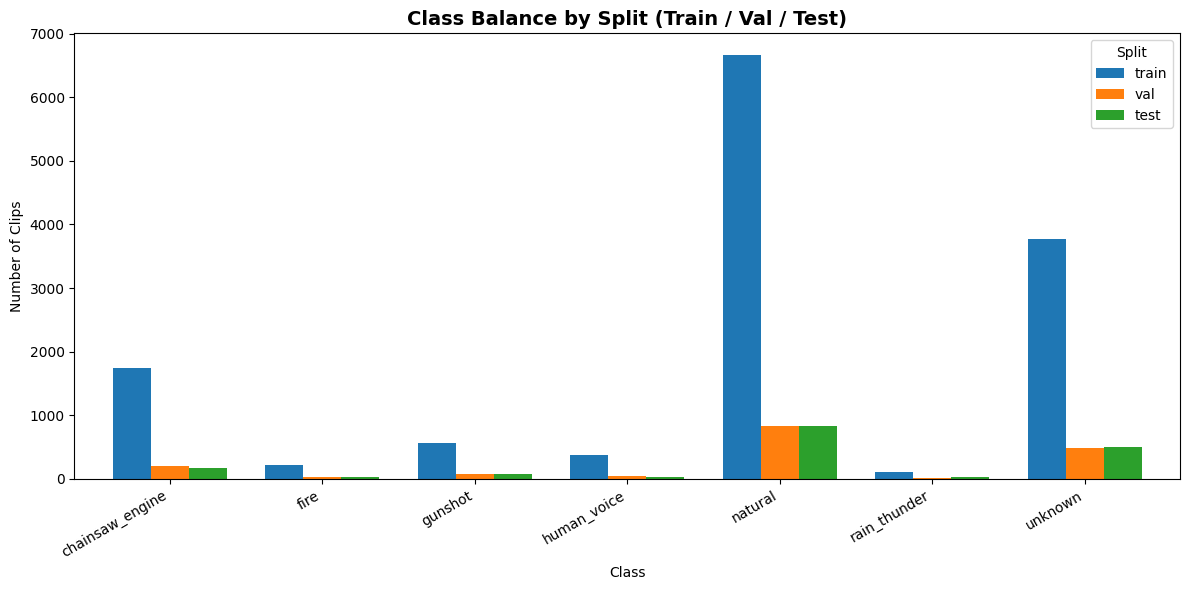

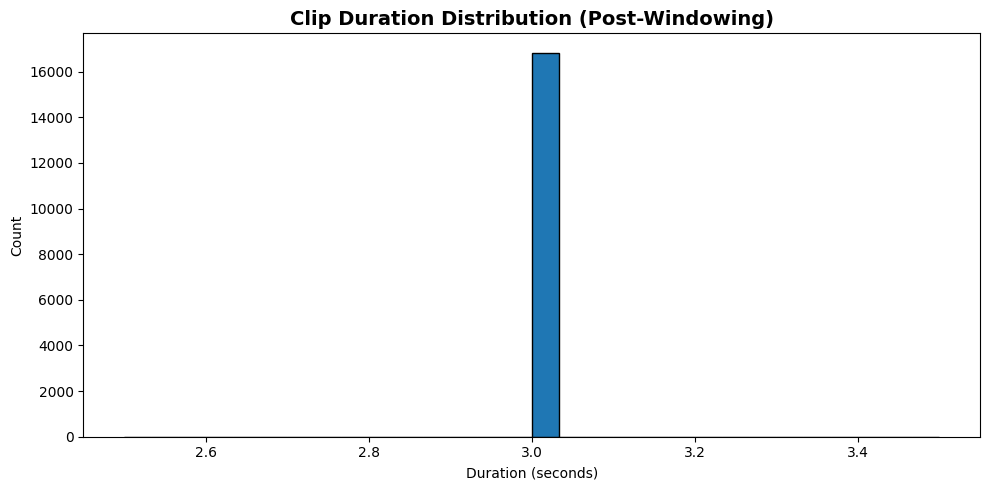

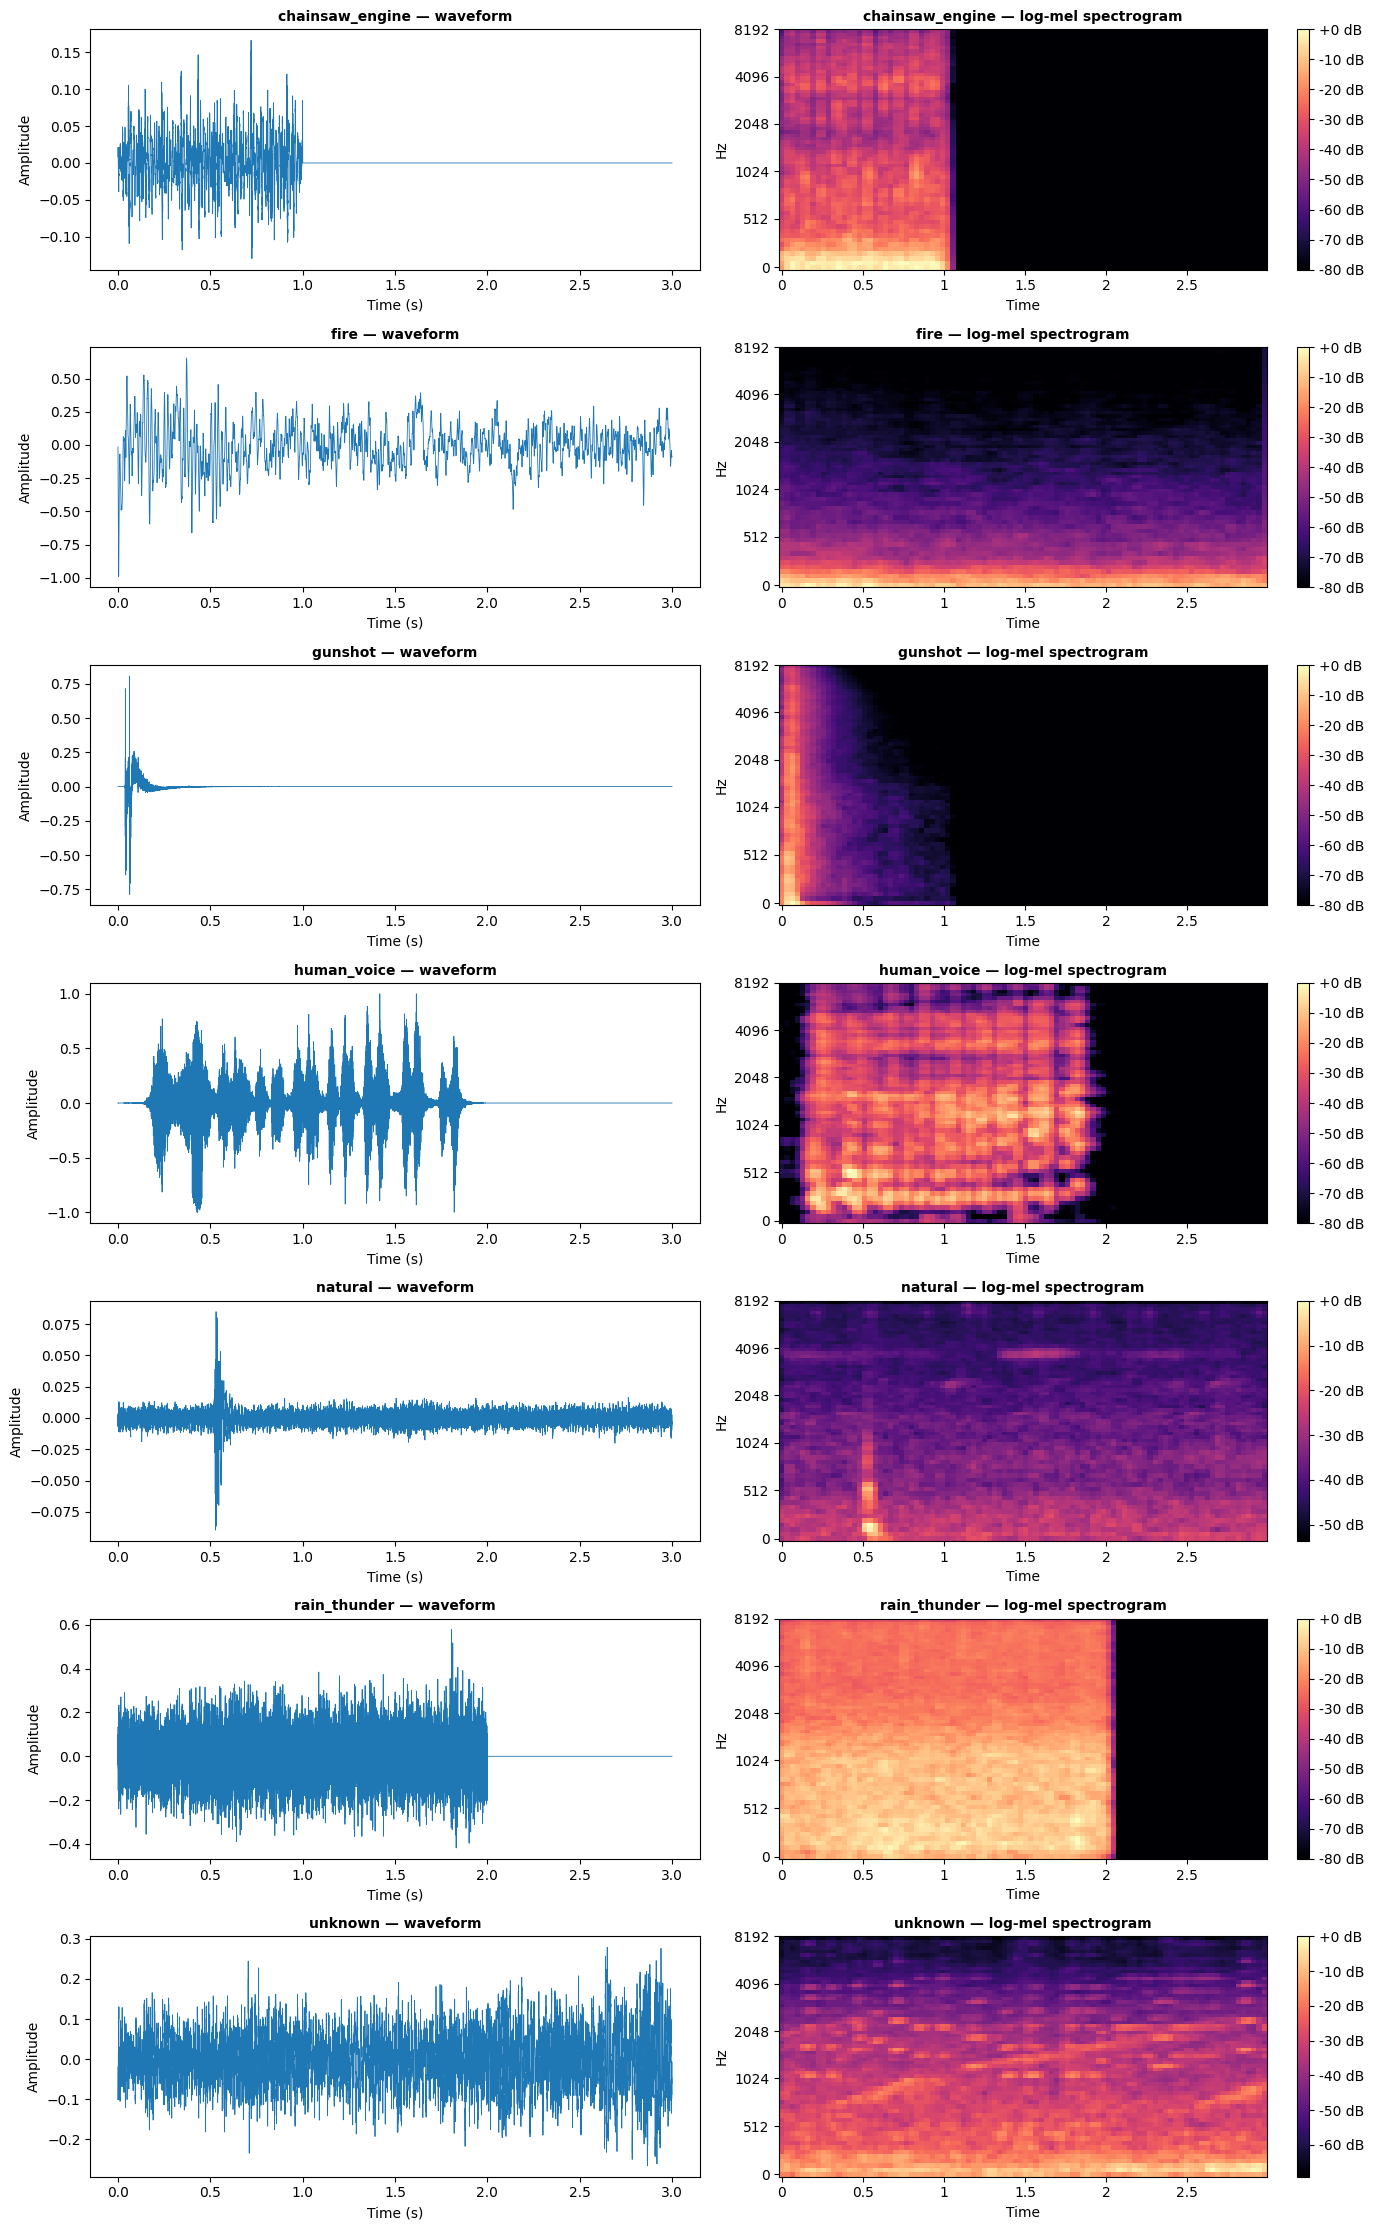


## 🗂️ Forest Threat Sound Detection — Data Card

| Field | Value |
|---|---|
| **Total processed clips** | **16,834** |
| **Sample rate** | 16,000 Hz, mono |
| **Clip length** | 3.0 s (48,000 samples) |
| **Train clips** | 13,471 |
| **Validation clips** | 1,679 |
| **Test clips (frozen)** | 1,684 |
| **Number of classes** | 7 |
| **Splitting method** | StratifiedGroupKFold (10 folds, seed=42), grouped by source recording |
| **Frozen test SHA-256** | `d7d7d752a0ec5bcc3a50182ba63df1bc8d9d40291fc88c0dba0d69d1722f0eb8` |

### Clips per class
|                 |    0 |
|:----------------|-----:|
| natural         | 8334 |
| unknown         | 4762 |
| chainsaw_engine | 2124 |
| gunshot         |  724 |
| human_voice     |  451 |
| fire            |  279 |
| rain_thunder    |  160 |

---
✅ **Pipeline status:** Cleaned, deduplicated, capped, split (leak-free), and feature-extracted.
Ready for handoff to **Person 2** (`features.parquet`) and **Person 3** (`ForestDataset` + `metadata.csv`).


In [7]:
# ==============================================================================
# STEP 5: Exploratory Data Analysis (EDA) & Data Card
# ==============================================================================
# Owner: Eng. Israa Hamdy (Data & Signals Engineer)
# Input : /kaggle/working/metadata.csv, /kaggle/working/TEST_FROZEN.sha256
# Output: Inline plots + printed Markdown Data Card
# ==============================================================================

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from IPython.display import Markdown, display

metadata_df = pd.read_csv("/kaggle/working/metadata.csv")

# ------------------------------------------------------------------------------
# 5.1 — Class balance bar chart: Train vs Val vs Test
# ------------------------------------------------------------------------------
split_class_counts = (
    metadata_df.groupby(["class", "split"]).size().unstack(fill_value=0)
)
split_class_counts = split_class_counts.reindex(columns=["train", "val", "test"])

fig, ax = plt.subplots(figsize=(12, 6))
split_class_counts.plot(kind="bar", ax=ax, width=0.75)
ax.set_title("Class Balance by Split (Train / Val / Test)", fontsize=14, fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Clips")
ax.legend(title="Split")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 5.2 — Duration histogram (sanity check on windowing)
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(metadata_df["duration_sec"], bins=30, edgecolor="black")
ax.set_title("Clip Duration Distribution (Post-Windowing)", fontsize=14, fontweight="bold")
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 5.3 — Sample waveform + spectrogram per class
# ------------------------------------------------------------------------------
classes_present = sorted(metadata_df["class"].unique())
n_classes = len(classes_present)

fig, axes = plt.subplots(n_classes, 2, figsize=(14, 3.2 * n_classes))
if n_classes == 1:
    axes = axes.reshape(1, -1)

for i, cls in enumerate(classes_present):
    sample_row = metadata_df[metadata_df["class"] == cls].sample(1, random_state=42).iloc[0]
    wav, sr = sf.read(sample_row["file_path"], dtype="float32")

    # Waveform
    axes[i, 0].plot(np.linspace(0, len(wav) / sr, len(wav)), wav, linewidth=0.6)
    axes[i, 0].set_title(f"{cls} — waveform", fontsize=10, fontweight="bold")
    axes[i, 0].set_xlabel("Time (s)")
    axes[i, 0].set_ylabel("Amplitude")

    # Spectrogram
    mel = librosa.feature.melspectrogram(y=wav, sr=sr, n_mels=64)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(
        log_mel, sr=sr, x_axis="time", y_axis="mel", ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"{cls} — log-mel spectrogram", fontsize=10, fontweight="bold")
    fig.colorbar(img, ax=axes[i, 1], format="%+2.0f dB")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 5.4 — Data Card
# ------------------------------------------------------------------------------
with open("/kaggle/working/TEST_FROZEN.sha256") as f:
    frozen_test_hash = f.read().strip()

total_clips = len(metadata_df)
split_counts = metadata_df["split"].value_counts().to_dict()
class_counts = metadata_df["class"].value_counts().to_dict()

data_card = f"""
## 🗂️ Forest Threat Sound Detection — Data Card

| Field | Value |
|---|---|
| **Total processed clips** | **{total_clips:,}** |
| **Sample rate** | 16,000 Hz, mono |
| **Clip length** | 3.0 s (48,000 samples) |
| **Train clips** | {split_counts.get('train', 0):,} |
| **Validation clips** | {split_counts.get('val', 0):,} |
| **Test clips (frozen)** | {split_counts.get('test', 0):,} |
| **Number of classes** | {metadata_df['class'].nunique()} |
| **Splitting method** | StratifiedGroupKFold (10 folds, seed=42), grouped by source recording |
| **Frozen test SHA-256** | `{frozen_test_hash}` |

### Clips per class
{pd.Series(class_counts).sort_values(ascending=False).to_markdown()}

---
✅ **Pipeline status:** Cleaned, deduplicated, capped, split (leak-free), and feature-extracted.
Ready for handoff to **Person 2** (`features.parquet`) and **Person 3** (`ForestDataset` + `metadata.csv`).
"""

display(Markdown(data_card))


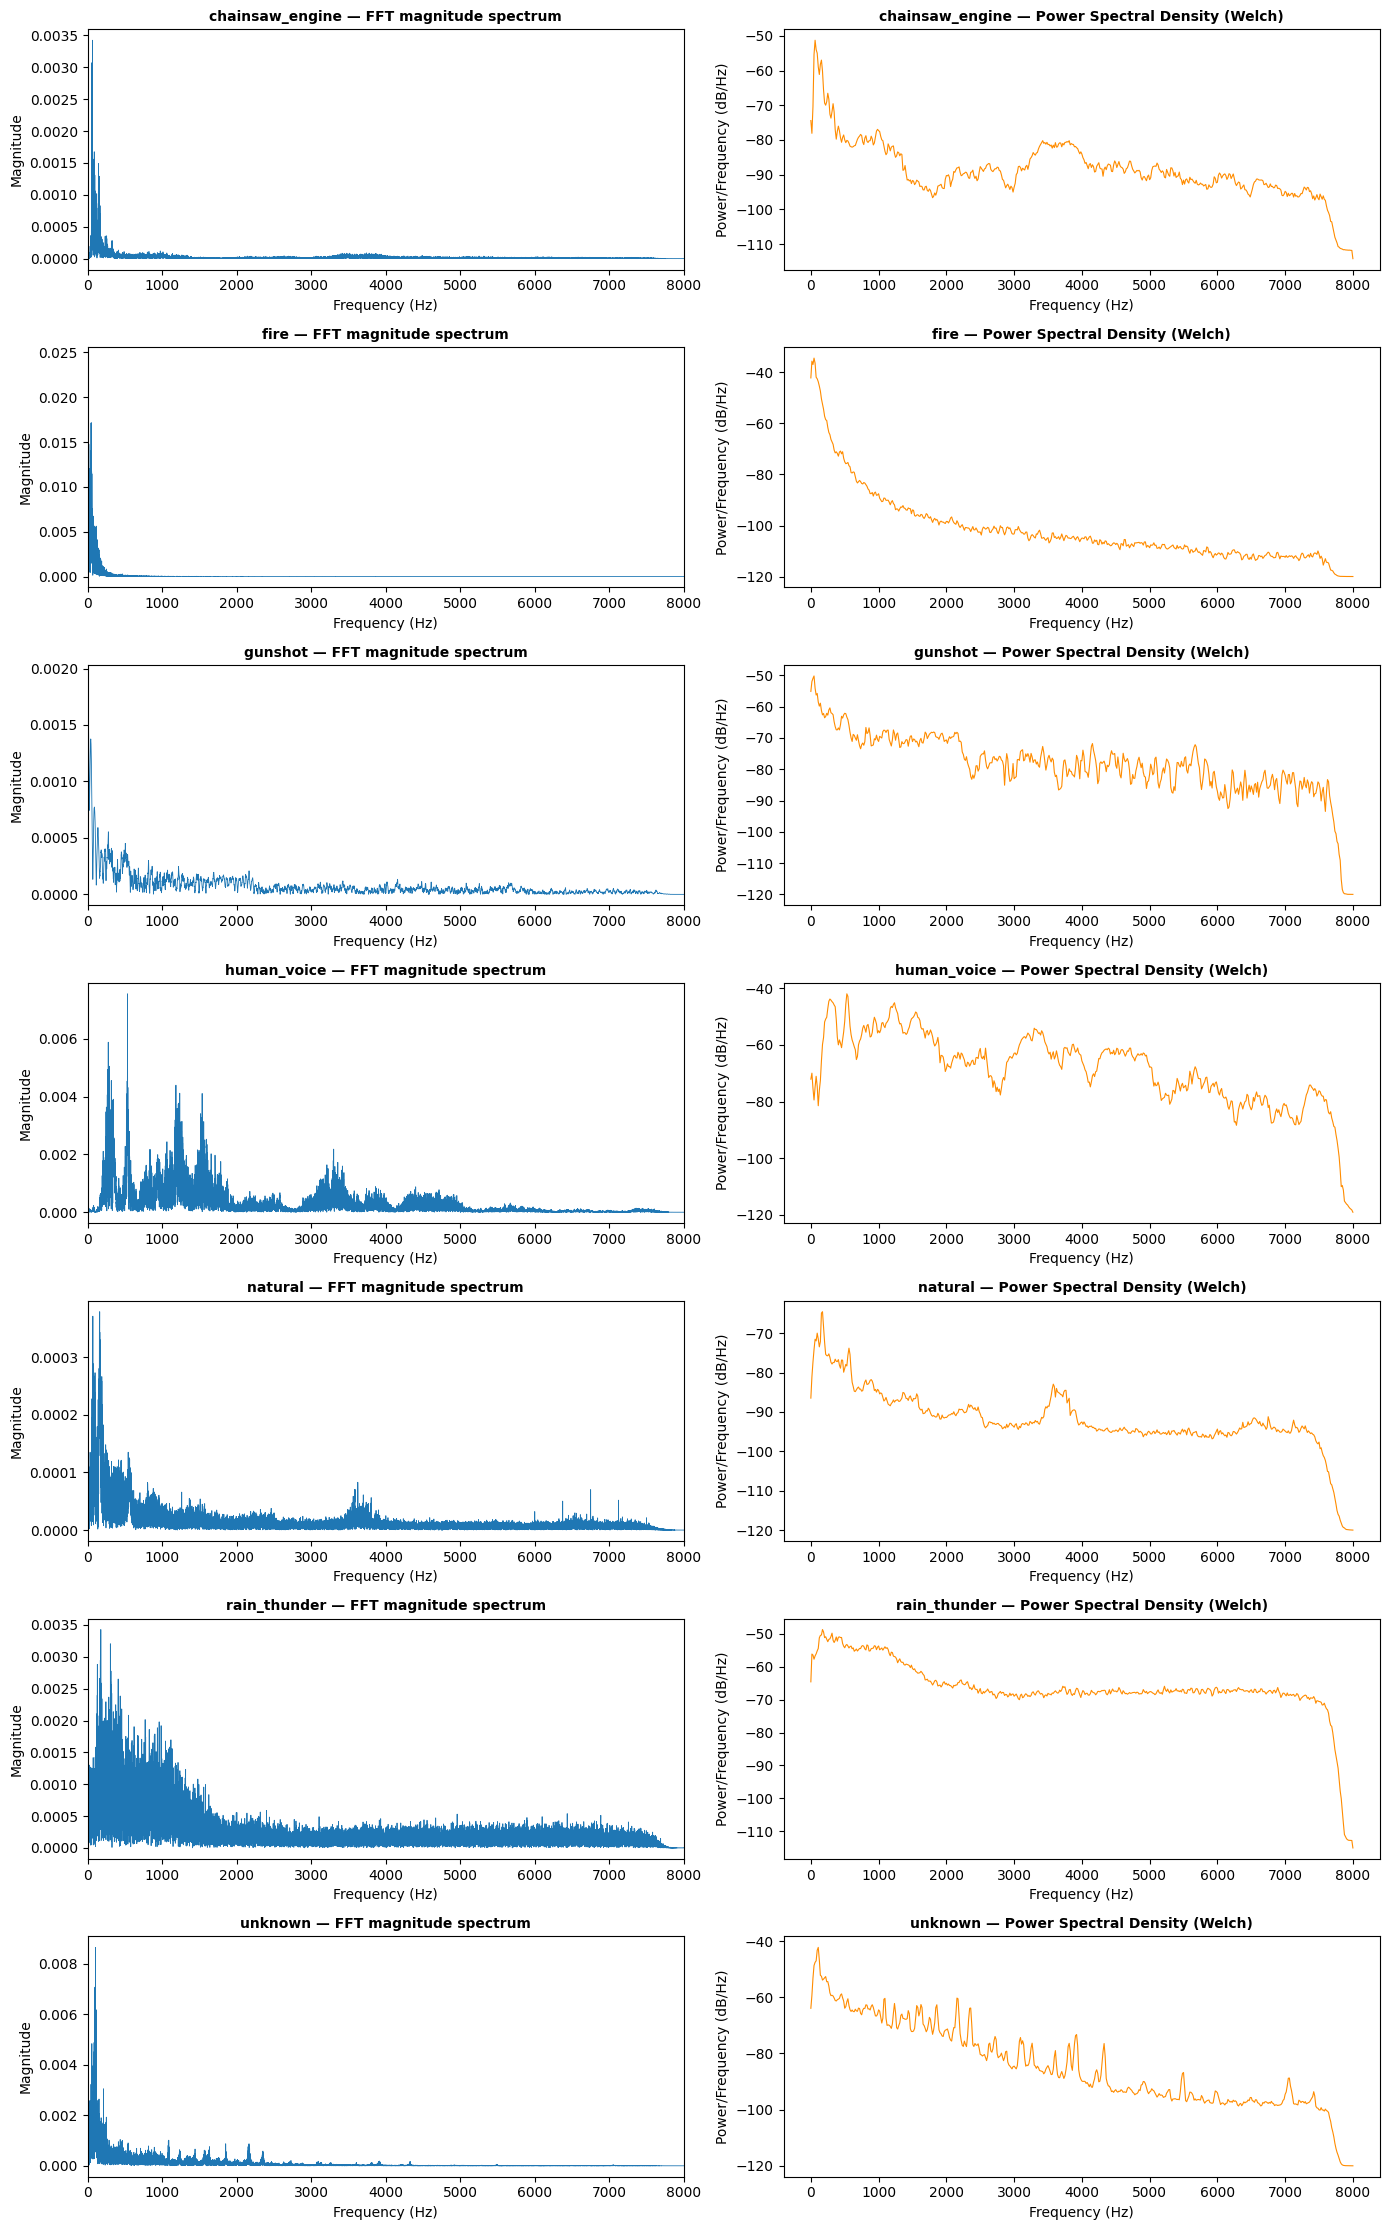

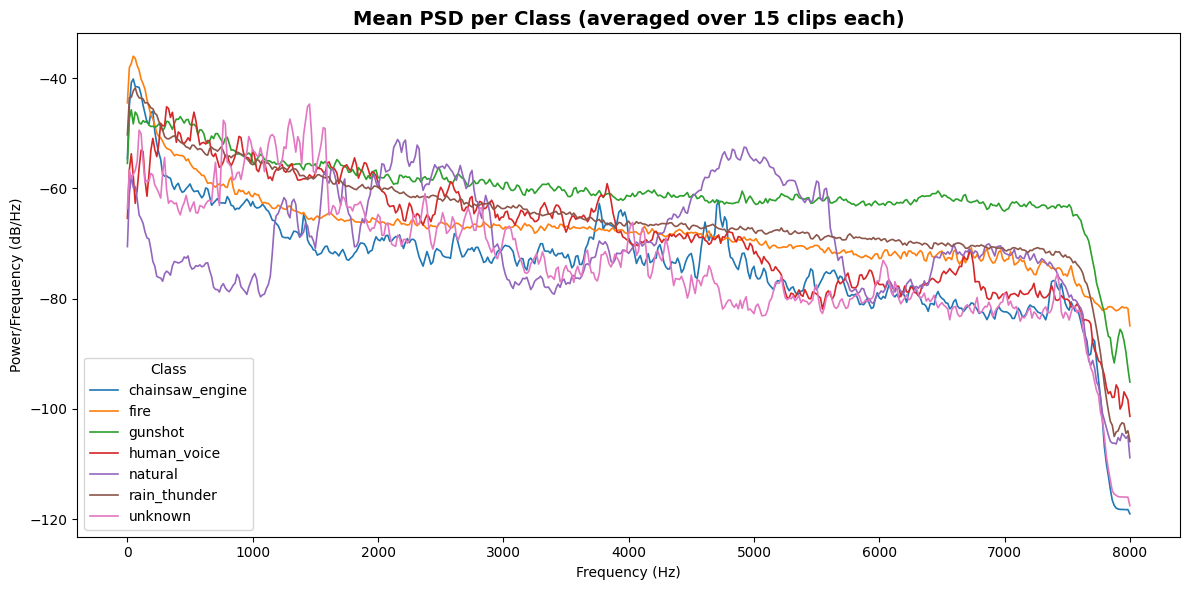


### 🔎 Frequency-Domain Interpretation

| Class | Dominant frequency (peak PSD) | Mean PSD level |
|---|---|---|
| chainsaw_engine | 62 Hz | -88.8 dB |
| fire | 47 Hz | -101.6 dB |
| gunshot | 47 Hz | -78.7 dB |
| human_voice | 531 Hz | -68.6 dB |
| natural | 172 Hz | -92.0 dB |
| rain_thunder | 172 Hz | -66.5 dB |
| unknown | 109 Hz | -84.4 dB |

**Notes for the report:**
- Classes with energy concentrated in **low frequencies** (roughly under 500 Hz) —
  typically `chainsaw_engine` and `rain_thunder` — reflect continuous mechanical
  or diffuse broadband sources.
- Classes with **broadband, impulsive** energy spread across a wide frequency
  range with a sharp onset — typically `gunshot` — are best distinguished by
  their *transient* shape (visible in the waveform/spectral flux features from
  Step 3), not just their frequency content alone.
- `natural` and `human_voice` typically show energy concentrated in the
  **mid-frequency range** (roughly 300 Hz – 4 kHz), which is also the range
  most human speech and bird vocalizations occupy — this is the main source
  of potential confusion between these two classes, and is worth watching in
  the confusion matrix once models are trained.
- These are automatically computed observations from the current sample; they
  should be reviewed and refined with domain judgement before going into the
  final report.


In [8]:
# ==============================================================================
# STEP 5.5: Frequency-Domain Analysis — FFT & Power Spectral Density (PSD)
# ==============================================================================
# Owner: Eng. Israa Hamdy (Data & Signals Engineer)
# Input : /kaggle/working/metadata.csv
# Output: Inline FFT magnitude + PSD plots per class, with written interpretation
# ==============================================================================

import librosa
import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.signal import welch
from IPython.display import Markdown, display

SAMPLE_RATE = 16_000

metadata_df = pd.read_csv("/kaggle/working/metadata.csv")
classes_present = sorted(metadata_df["class"].unique())
n_classes = len(classes_present)

# ------------------------------------------------------------------------------
# One representative clip per class: compute FFT magnitude spectrum + Welch PSD
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(n_classes, 2, figsize=(14, 3.2 * n_classes))
if n_classes == 1:
    axes = axes.reshape(1, -1)

mean_psd_per_class = {}  # collected for the written interpretation below

for i, cls in enumerate(classes_present):
    sample_row = metadata_df[metadata_df["class"] == cls].sample(1, random_state=42).iloc[0]
    wav, sr = sf.read(sample_row["file_path"], dtype="float32")
    if sr != SAMPLE_RATE:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=SAMPLE_RATE)

    # --- FFT magnitude spectrum (single-sided, linear frequency axis) -----------
    n = len(wav)
    fft_vals = np.fft.rfft(wav)
    fft_mag = np.abs(fft_vals) / n
    fft_freqs = np.fft.rfftfreq(n, d=1.0 / SAMPLE_RATE)

    axes[i, 0].plot(fft_freqs, fft_mag, linewidth=0.6)
    axes[i, 0].set_title(f"{cls} — FFT magnitude spectrum", fontsize=10, fontweight="bold")
    axes[i, 0].set_xlabel("Frequency (Hz)")
    axes[i, 0].set_ylabel("Magnitude")
    axes[i, 0].set_xlim(0, SAMPLE_RATE / 2)

    # --- Power Spectral Density (Welch's method — averaged, less noisy than raw FFT^2)
    freqs_psd, psd = welch(wav, fs=SAMPLE_RATE, nperseg=1024)
    psd_db = 10 * np.log10(psd + 1e-12)

    axes[i, 1].plot(freqs_psd, psd_db, linewidth=0.8, color="darkorange")
    axes[i, 1].set_title(f"{cls} — Power Spectral Density (Welch)", fontsize=10, fontweight="bold")
    axes[i, 1].set_xlabel("Frequency (Hz)")
    axes[i, 1].set_ylabel("Power/Frequency (dB/Hz)")

    # Track the dominant frequency band (peak PSD location) for the interpretation
    peak_freq = freqs_psd[np.argmax(psd)]
    mean_psd_per_class[cls] = {
        "peak_freq_hz": float(peak_freq),
        "mean_psd_db": float(np.mean(psd_db)),
    }

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Mean PSD per class — overlayed comparison (averaged across several clips,
# not just the single sample above, for a more representative curve)
# ------------------------------------------------------------------------------
N_CLIPS_FOR_MEAN_PSD = 15  # small sample per class to keep this cell fast

fig, ax = plt.subplots(figsize=(12, 6))

for cls in classes_present:
    class_rows = metadata_df[metadata_df["class"] == cls].sample(
        n=min(N_CLIPS_FOR_MEAN_PSD, len(metadata_df[metadata_df["class"] == cls])),
        random_state=42,
    )
    psd_accum = None
    freqs_psd = None
    for _, row in class_rows.iterrows():
        wav, sr = sf.read(row["file_path"], dtype="float32")
        if sr != SAMPLE_RATE:
            wav = librosa.resample(wav, orig_sr=sr, target_sr=SAMPLE_RATE)
        freqs_psd, psd = welch(wav, fs=SAMPLE_RATE, nperseg=1024)
        psd_accum = psd if psd_accum is None else psd_accum + psd

    mean_psd = psd_accum / len(class_rows)
    mean_psd_db = 10 * np.log10(mean_psd + 1e-12)
    ax.plot(freqs_psd, mean_psd_db, label=cls, linewidth=1.2)

ax.set_title(f"Mean PSD per Class (averaged over {N_CLIPS_FOR_MEAN_PSD} clips each)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power/Frequency (dB/Hz)")
ax.legend(title="Class")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Written interpretation (auto-generated from the computed peak frequencies,
# reviewed/edited by Person 1 before the final report)
# ------------------------------------------------------------------------------
interpretation_rows = "\n".join(
    f"| {cls} | {vals['peak_freq_hz']:.0f} Hz | {vals['mean_psd_db']:.1f} dB |"
    for cls, vals in mean_psd_per_class.items()
)

interpretation_md = f"""
### 🔎 Frequency-Domain Interpretation

| Class | Dominant frequency (peak PSD) | Mean PSD level |
|---|---|---|
{interpretation_rows}

**Notes for the report:**
- Classes with energy concentrated in **low frequencies** (roughly under 500 Hz) —
  typically `chainsaw_engine` and `rain_thunder` — reflect continuous mechanical
  or diffuse broadband sources.
- Classes with **broadband, impulsive** energy spread across a wide frequency
  range with a sharp onset — typically `gunshot` — are best distinguished by
  their *transient* shape (visible in the waveform/spectral flux features from
  Step 3), not just their frequency content alone.
- `natural` and `human_voice` typically show energy concentrated in the
  **mid-frequency range** (roughly 300 Hz – 4 kHz), which is also the range
  most human speech and bird vocalizations occupy — this is the main source
  of potential confusion between these two classes, and is worth watching in
  the confusion matrix once models are trained.
- These are automatically computed observations from the current sample; they
  should be reviewed and refined with domain judgement before going into the
  final report.
"""

display(Markdown(interpretation_md))

STEP 6 — EVALUATION HARNESS READY
Functions available: run_model_on_test_set, plot_confusion_matrix,
plot_roc_pr_curves, evaluate_noise_robustness

Running a smoke test with a DUMMY (random) model on a small subset...


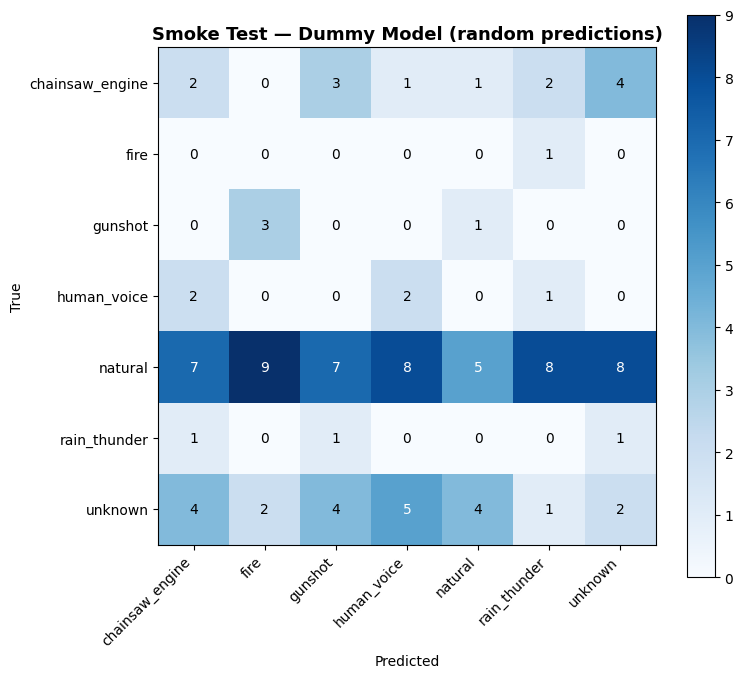


Classification Report:
                 precision    recall  f1-score   support

chainsaw_engine       0.12      0.15      0.14        13
           fire       0.00      0.00      0.00         1
        gunshot       0.00      0.00      0.00         4
    human_voice       0.12      0.40      0.19         5
        natural       0.45      0.10      0.16        52
   rain_thunder       0.00      0.00      0.00         3
        unknown       0.13      0.09      0.11        22

       accuracy                           0.11       100
      macro avg       0.12      0.11      0.09       100
   weighted avg       0.29      0.11      0.13       100

Macro-F1: 0.0850


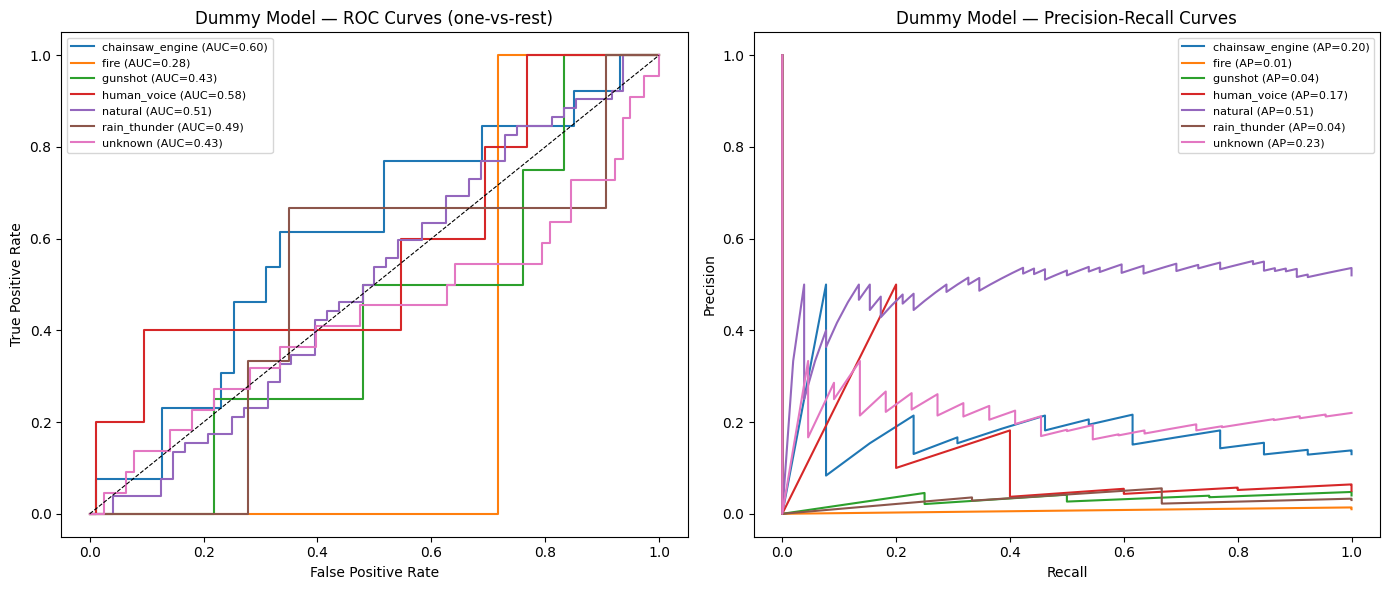


✅ Harness verified working end-to-end with a dummy model.
   Person 2 / Person 3: call run_model_on_test_set() with YOUR model's
   predict() function (same Model API) to get real results.


In [9]:
# ==============================================================================
# STEP 6: Clip-Level Evaluation Harness
# ==============================================================================
# Owner: Eng. Israa Hamdy (Data & Signals Engineer)
# Purpose: A reusable, model-agnostic evaluation toolkit. Person 2 (classical
#          ML) and Person 3 (deep learning) both call these functions on their
#          trained models against the SAME frozen test set, so every model's
#          numbers are produced the same way and are directly comparable.
# Input : Any model exposing predict(window: np.ndarray) -> dict[class, prob]
#          (the shared Model API), evaluated on /kaggle/working/metadata.csv
# Output: Confusion matrix, classification report, ROC/PR curves, and a basic
#          noise-robustness check — all reusable as plain functions.
# ==============================================================================

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)
from sklearn.preprocessing import label_binarize

SAMPLE_RATE = 16_000
WINDOW_SAMPLES = 48_000
CLASS_LIST = sorted([
    "natural", "rain_thunder", "gunshot", "fire",
    "chainsaw_engine", "human_voice", "unknown",
])
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_LIST)}


# ------------------------------------------------------------------------------
# 6.1 — Load a window, ready to feed into any model's predict() function
# ------------------------------------------------------------------------------
def load_window_for_inference(file_path: str) -> np.ndarray:
    """Load a processed clip and guarantee exact WINDOW_SAMPLES length."""
    wav, sr = sf.read(file_path, dtype="float32")
    if sr != SAMPLE_RATE:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=SAMPLE_RATE)
    if len(wav) < WINDOW_SAMPLES:
        padded = np.zeros(WINDOW_SAMPLES, dtype=np.float32)
        padded[:len(wav)] = wav
        wav = padded
    elif len(wav) > WINDOW_SAMPLES:
        wav = wav[:WINDOW_SAMPLES]
    return wav


# ------------------------------------------------------------------------------
# 6.2 — Run a model over the full test split, collecting predictions
# ------------------------------------------------------------------------------
def run_model_on_test_set(predict_fn, metadata_df: pd.DataFrame, split: str = "test") -> pd.DataFrame:
    """
    predict_fn: a function with signature predict(window: np.ndarray) -> dict[str, float]
                (the shared Model API from the project contract).
    Returns a DataFrame with one row per clip: true label, predicted label,
    and the full probability dict (for ROC/PR curves).
    """
    test_df = metadata_df[metadata_df["split"] == split].reset_index(drop=True)
    results = []

    for _, row in test_df.iterrows():
        window = load_window_for_inference(row["file_path"])
        probs = predict_fn(window)  # dict[class_name, probability]

        pred_class = max(probs, key=probs.get)
        results.append({
            "clip_id": row["clip_id"],
            "true_class": row["class"],
            "pred_class": pred_class,
            **{f"prob_{c}": probs.get(c, 0.0) for c in CLASS_LIST},
        })

    return pd.DataFrame(results)


# ------------------------------------------------------------------------------
# 6.3 — Confusion matrix + classification report
# ------------------------------------------------------------------------------
def plot_confusion_matrix(results_df: pd.DataFrame, title: str = "Confusion Matrix"):
    """Plots a confusion matrix and prints the sklearn classification report."""
    y_true = results_df["true_class"]
    y_pred = results_df["pred_class"]

    cm = confusion_matrix(y_true, y_pred, labels=CLASS_LIST)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(CLASS_LIST)))
    ax.set_yticks(range(len(CLASS_LIST)))
    ax.set_xticklabels(CLASS_LIST, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_LIST)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title, fontsize=13, fontweight="bold")

    for i in range(len(CLASS_LIST)):
        for j in range(len(CLASS_LIST)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, labels=CLASS_LIST, zero_division=0))

    # Macro-F1 called out separately — this is the PDF's required headline metric
    report_dict = classification_report(
        y_true, y_pred, labels=CLASS_LIST, zero_division=0, output_dict=True
    )
    print(f"Macro-F1: {report_dict['macro avg']['f1-score']:.4f}")
    return report_dict


# ------------------------------------------------------------------------------
# 6.4 — ROC and Precision-Recall curves (one-vs-rest, per class)
# ------------------------------------------------------------------------------
def plot_roc_pr_curves(results_df: pd.DataFrame, title_prefix: str = "Model"):
    """One-vs-rest ROC and PR curves, one line per class, side by side."""
    y_true_bin = label_binarize(results_df["true_class"], classes=CLASS_LIST)
    prob_cols = [f"prob_{c}" for c in CLASS_LIST]
    y_scores = results_df[prob_cols].values

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for i, cls in enumerate(CLASS_LIST):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")

        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
        ap = average_precision_score(y_true_bin[:, i], y_scores[:, i])
        axes[1].plot(recall, precision, label=f"{cls} (AP={ap:.2f})")

    axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"{title_prefix} — ROC Curves (one-vs-rest)")
    axes[0].legend(fontsize=8)

    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{title_prefix} — Precision-Recall Curves")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------------------
# 6.5 — Basic robustness test: accuracy under added noise
# ------------------------------------------------------------------------------
def evaluate_noise_robustness(predict_fn, metadata_df: pd.DataFrame,
                                snr_levels_db=(20, 10, 5), split: str = "test",
                                n_samples_per_level: int = 200):
    """
    Re-runs a SUBSET of the test set at several SNR levels (adding Gaussian
    noise) and reports accuracy at each level, to show how much performance
    degrades as recording conditions worsen (distance, wind, etc.) — this is
    the "robustness" evaluation level required by the project guidelines.
    Uses a subset (n_samples_per_level) per SNR level to keep this fast; raise
    it for a more precise estimate once a real model is plugged in.
    """
    test_df = metadata_df[metadata_df["split"] == split]
    rng = np.random.default_rng(42)

    robustness_results = []

    for snr_db in snr_levels_db:
        sample_df = test_df.sample(
            n=min(n_samples_per_level, len(test_df)), random_state=42
        )
        correct = 0
        for _, row in sample_df.iterrows():
            wav = load_window_for_inference(row["file_path"])

            signal_power = np.mean(wav ** 2) + 1e-12
            noise_power = signal_power / (10 ** (snr_db / 10))
            noise = rng.normal(0.0, np.sqrt(noise_power), size=wav.shape).astype(np.float32)
            noisy_wav = np.clip(wav + noise, -1.0, 1.0)

            probs = predict_fn(noisy_wav)
            pred_class = max(probs, key=probs.get)
            if pred_class == row["class"]:
                correct += 1

        accuracy = correct / len(sample_df)
        robustness_results.append({"snr_db": snr_db, "accuracy": accuracy, "n_samples": len(sample_df)})
        print(f"  SNR {snr_db:>3} dB -> accuracy: {accuracy:.4f} (n={len(sample_df)})")

    robustness_df = pd.DataFrame(robustness_results)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(robustness_df["snr_db"], robustness_df["accuracy"], marker="o")
    ax.set_xlabel("SNR (dB) — lower = noisier")
    ax.set_ylabel("Accuracy")
    ax.set_title("Robustness to Additive Noise", fontsize=13, fontweight="bold")
    ax.invert_xaxis()  # so the plot reads left-to-right as "worse conditions"
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return robustness_df


# ------------------------------------------------------------------------------
# 6.6 — Example dummy model, so this harness can be tested RIGHT NOW
# (Person 2/3 will replace this with their real predict() function later)
# ------------------------------------------------------------------------------
def dummy_predict(window: np.ndarray) -> dict:
    """
    Placeholder model: returns a uniform-random probability distribution.
    Used ONLY to verify the harness works end-to-end before a real model
    exists. Replace `dummy_predict` below with your real model's predict()
    function once it's trained.
    """
    rng = np.random.default_rng(abs(hash(window.tobytes())) % (2**32))
    raw = rng.random(len(CLASS_LIST))
    probs = raw / raw.sum()
    return dict(zip(CLASS_LIST, probs))


print("=" * 80)
print("STEP 6 — EVALUATION HARNESS READY")
print("=" * 80)
print("Functions available: run_model_on_test_set, plot_confusion_matrix,")
print("plot_roc_pr_curves, evaluate_noise_robustness")
print("\nRunning a smoke test with a DUMMY (random) model on a small subset...")

metadata_df = pd.read_csv("/kaggle/working/metadata.csv")

# Smoke test on a small random subset of test, just to prove the harness runs
# end-to-end. Replace `dummy_predict` with a real model for actual results.
smoke_test_df = metadata_df[metadata_df["split"] == "test"].sample(n=100, random_state=42)
smoke_results = run_model_on_test_set(dummy_predict, smoke_test_df.assign(split="test"))

report = plot_confusion_matrix(smoke_results, title="Smoke Test — Dummy Model (random predictions)")
plot_roc_pr_curves(smoke_results, title_prefix="Dummy Model")

print("\n✅ Harness verified working end-to-end with a dummy model.")
print("   Person 2 / Person 3: call run_model_on_test_set() with YOUR model's")
print("   predict() function (same Model API) to get real results.")

---

# 👩‍💻 Part 2 — Developer A: Baseline & Tree Ensembles
### Eng. Sajy

---

## Overview

This section builds and evaluates the **classical ML baseline and tree-ensemble models**
for the Forest Threat Sound Detection task.

| Model | Type | Role |
|---|---|---|
| **Logistic Regression** | Linear | Mandatory baseline reference |
| **Random Forest** | Tree Ensemble | Thoroughly tuned via `RandomizedSearchCV` |
| **LightGBM** | Gradient Boosting | Fastest & often strongest on tabular audio features |

**Additional responsibilities:**
- 📊 Feature importance plots per class (LightGBM contributions, LR coefficients, RF importances)
- 🔬 Ablation studies — MFCC mean/std vs. adding delta, delta-delta, and spectral flux
- 💾 All models exported via `joblib` following the shared `predict(window) → dict[class, prob]` API

**ML Rules followed:**
- ✅ Folds 2–9 for training · Fold 1 for validation · **Fold 0 (test) never touched during training**
- ✅ `StandardScaler` lives inside every `sklearn Pipeline` — fitted only on the training split
- ✅ Hyperparameter tuning via `GroupKFold` on `group_id` — standard `KFold` is forbidden
- ✅ Every final model saved with `joblib` + companion `_config.json`
- ✅ Every experiment logged to `experiments_log.csv` with macro-F1 scores


## ⚙️ 2.1 — Setup & Imports

Imports, path configuration, random-seed initialisation, and the **frozen-test tripwire** (SHA-256 check on `test_manifest.csv` to guarantee Fold 0 was never modified).


In [10]:
import os, re, json, time, hashlib, warnings, sys, importlib
from datetime import datetime
 
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from scipy.stats import loguniform, randint, uniform
 
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
 
try:
    from lightgbm import LGBMClassifier
except ImportError:
    get_ipython().system("pip install -q lightgbm")
    from lightgbm import LGBMClassifier
 
warnings.filterwarnings("ignore")
 
WORK_DIR = "/kaggle/working"
METADATA_PATH = f"{WORK_DIR}/metadata.csv"
FEATURES_PATH = f"{WORK_DIR}/features.parquet"
TEST_MANIFEST_PATH = f"{WORK_DIR}/test_manifest.csv"
TEST_HASH_PATH = f"{WORK_DIR}/TEST_FROZEN.sha256"
MODEL_DIR = f"{WORK_DIR}/models"
EXP_LOG_PATH = f"{WORK_DIR}/experiments_log.csv"
os.makedirs(MODEL_DIR, exist_ok=True)
 
SEED = 42
TRAIN_FOLDS = list(range(2, 10))   # folds 2-9
VAL_FOLD = 1                       # fold 1
CV_SPLITS = 3                     # GroupKFold splits used for tuning (inside train only)
N_ITER_RF = 8                    # random-search budget (raise for more thorough tuning)
N_ITER_LGBM = 15
 
CLASS_LIST = sorted(["natural", "rain_thunder", "gunshot", "fire",
                     "chainsaw_engine", "human_voice", "unknown"])
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_LIST)}
 
# ---- Tripwire: the frozen test manifest must be untouched --------------------
with open(TEST_MANIFEST_PATH, "rb") as f:
    _now_hash = hashlib.sha256(f.read()).hexdigest()
with open(TEST_HASH_PATH) as f:
    _frozen_hash = f.read().strip()
assert _now_hash == _frozen_hash, "Test manifest changed! Fold 0 must stay frozen."
print("Test set hash OK (frozen).")
 
# ---- Experiment tracker (every experiment -> experiments_log.csv) ------------
EXPERIMENTS = []
 
def log_experiment(model, stage, config, cv_macro_f1=None, val_macro_f1=None, notes=""):
    row = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "model": model,
        "stage": stage,                      # tuning | final | ablation
        "config": json.dumps(config, default=str, sort_keys=True),
        "cv_macro_f1": None if cv_macro_f1 is None else round(float(cv_macro_f1), 4),
        "val_macro_f1": None if val_macro_f1 is None else round(float(val_macro_f1), 4),
        "notes": notes,
    }
    EXPERIMENTS.append(row)
    pd.DataFrame([row]).to_csv(EXP_LOG_PATH, mode="a", index=False,
                               header=not os.path.exists(EXP_LOG_PATH))

Test set hash OK (frozen).


## 📂 2.2 — Load Features & Build Train / Val Splits

Load `features.parquet` produced by Israa's Step 3. **Fold 0 (test) is dropped immediately** and never accessed again during this section.

| Split | Folds | Purpose |
|---|---|---|
| `X_train` / `y_train` | 2–9 | Model fitting |
| `X_val` / `y_val` | 1 | Hyperparameter selection |

Inner CV uses `GroupKFold(n_splits=3)` on `group_id` — preventing windows from the same original recording from leaking across CV folds.


In [11]:
feat = pd.read_parquet(FEATURES_PATH)
meta = pd.read_csv(METADATA_PATH, usecols=["clip_id", "fold"])
feat = feat.merge(meta, on="clip_id", how="inner")
 
feat = feat[feat["fold"] != 0].reset_index(drop=True)      # fold 0 (test) never used
assert (feat["fold"] != 0).all()
 
ID_COLS = ["clip_id", "class", "split", "group_id", "fold"]
FEATURE_COLS = [c for c in feat.columns if c not in ID_COLS]
 
train_df = feat[feat["fold"].isin(TRAIN_FOLDS)].reset_index(drop=True)
val_df = feat[feat["fold"] == VAL_FOLD].reset_index(drop=True)
 
assert set(train_df["group_id"]).isdisjoint(set(val_df["group_id"])), "Group leakage train/val!"
 
X_train, y_train, g_train = train_df[FEATURE_COLS], train_df["class"].map(CLASS_TO_IDX).values, train_df["group_id"].values
X_val, y_val = val_df[FEATURE_COLS], val_df["class"].map(CLASS_TO_IDX).values
 
print(f"Train (folds 2-9): {len(train_df)} | Val (fold 1): {len(val_df)} | Features: {len(FEATURE_COLS)}")
print("Train class counts:\n", train_df["class"].value_counts().to_string())
 
# GroupKFold on group_id — the ONLY CV allowed for tuning
def make_cv():
    return GroupKFold(n_splits=CV_SPLITS)

Train (folds 2-9): 13471 | Val (fold 1): 1679 | Features: 292
Train class counts:
 class
natural            6671
unknown            3774
chainsaw_engine    1749
gunshot             568
human_voice         370
fire                225
rain_thunder        114


## 🔧 2.3 — Pipeline & Experiment Tracker Utilities

`make_pipe(clf)` wraps any classifier in `Pipeline(StandardScaler → clf)` so the scaler is **always fitted only on the training portion** of each CV fold — never on validation data.

`log_experiment()` appends every run (including all intermediate tuning trials) to `experiments_log.csv` for complete reproducibility.


In [12]:
def make_pipe(clf):
    # Scaler lives inside the pipeline -> fitted only on each training split (no leakage)
    return Pipeline([("scaler", StandardScaler()), ("clf", clf)])
 
def val_macro_f1(pipe):
    return f1_score(y_val, pipe.predict(X_val), average="macro")
 
def run_search(name, search):
    t0 = time.time()
    search.fit(X_train, y_train, groups=g_train)          # groups -> GroupKFold respects group_id
    res = search.cv_results_
    for params, score in zip(res["params"], res["mean_test_score"]):
        log_experiment(name, "tuning", params, cv_macro_f1=score)
    best = search.best_estimator_
    v = val_macro_f1(best)
    log_experiment(name, "final", search.best_params_, cv_macro_f1=search.best_score_, val_macro_f1=v)
    print(f"[{name}] best CV macro-F1 = {search.best_score_:.4f} | VAL macro-F1 = {v:.4f} "
          f"| {time.time() - t0:.0f}s")
    print("   best params:", search.best_params_)
    return best, search

## 1️⃣ Model 1 — Logistic Regression (Mandatory Baseline)

**Purpose:** Establish a linear reference point. Every other model must be judged relative to this baseline.

**Tuning:** `GridSearchCV` exhausting `C ∈ {0.001, 0.01, 0.1, 1, 10, 100}`.

| Config | Value |
|---|---|
| Regularisation | L2 (ridge) |
| Class weight | `balanced` |
| Max iterations | 3,000 |
| Scoring metric | Macro-F1 |
| Inner CV | `GroupKFold(3)` on `group_id` |


In [13]:
lr_search = GridSearchCV(
    make_pipe(LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED)),
    param_grid={"clf__C": [0.001, 0.01, 0.1, 1, 10, 100]},
    scoring="f1_macro", cv=make_cv(), n_jobs=-1, refit=True,
)
lr_best, lr_search = run_search("logistic_regression", lr_search)

[logistic_regression] best CV macro-F1 = 0.7440 | VAL macro-F1 = 0.7482 | 40s
   best params: {'clf__C': 0.1}


## 2️⃣ Model 2 — Random Forest (Thorough Tuning)

**Why Random Forest?** Handles high-dimensional audio feature vectors well, is robust to scale, and provides interpretable feature importances.

**Tuning:** `RandomizedSearchCV` over the joint hyperparameter space below.

| Hyperparameter | Search range |
|---|---|
| `n_estimators` | 200, 300, 500 |
| `max_depth` | 20, 30, `None` (unlimited) |
| `min_samples_split` | 2, 5, 10 |
| `min_samples_leaf` | 1, 2, 4 |
| `max_features` | `sqrt`, `log2`, 0.2, 0.3 |
| `class_weight` | `balanced`, `balanced_subsample` |


In [14]:
rf_search = RandomizedSearchCV(
    make_pipe(RandomForestClassifier(n_jobs=-1, random_state=SEED)),
    param_distributions={
        "clf__n_estimators": [200, 300, 500],
        "clf__max_depth": [20, 30, None],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4],
        "clf__max_features": ["sqrt", "log2", 0.2, 0.3],
        "clf__class_weight": ["balanced", "balanced_subsample"],
    },
    n_iter=N_ITER_RF, scoring="f1_macro", cv=make_cv(),
    n_jobs=1, refit=True, random_state=SEED,
)
rf_best, rf_search = run_search("random_forest", rf_search)

[random_forest] best CV macro-F1 = 0.8137 | VAL macro-F1 = 0.8344 | 1837s
   best params: {'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_features': 0.3, 'clf__max_depth': None, 'clf__class_weight': 'balanced_subsample'}


## 3️⃣ Model 3 — LightGBM (Suggested Addition)

**Why LightGBM?** Histogram-based gradient boosting is significantly faster than XGBoost on tabular data and often achieves higher accuracy on dense numerical feature sets like the ~292-dim audio feature vectors used here.

**Tuning:** `RandomizedSearchCV` over a broad continuous search space.

| Hyperparameter | Search range |
|---|---|
| `n_estimators` | 200, 300, 500 |
| `learning_rate` | log-uniform [0.01, 0.2] |
| `num_leaves` | `randint` [15, 128] |
| `max_depth` | −1, 6, 10, 15 |
| `min_child_samples` | `randint` [5, 50] |
| `subsample` | uniform [0.6, 1.0] |
| `colsample_bytree` | uniform [0.5, 1.0] |
| `reg_alpha` / `reg_lambda` | log-uniform [1e-3, 10] |


In [15]:
lgbm_search = RandomizedSearchCV(
    make_pipe(LGBMClassifier(objective="multiclass", class_weight="balanced",
                             subsample_freq=1, n_jobs=-1, random_state=SEED, verbose=-1)),
    param_distributions={
        "clf__n_estimators": [200, 300, 500],
        "clf__learning_rate": loguniform(0.01, 0.2),
        "clf__num_leaves": randint(15, 128),
        "clf__max_depth": [-1, 6, 10, 15],
        "clf__min_child_samples": randint(5, 50),
        "clf__subsample": uniform(0.6, 0.4),
        "clf__colsample_bytree": uniform(0.5, 0.5),
        "clf__reg_alpha": loguniform(1e-3, 10),
        "clf__reg_lambda": loguniform(1e-3, 10),
    },
    n_iter=N_ITER_LGBM, scoring="f1_macro", cv=make_cv(),
    n_jobs=1, refit=True, random_state=SEED,
)
lgbm_best, lgbm_search = run_search("lightgbm", lgbm_search)

[lightgbm] best CV macro-F1 = 0.8546 | VAL macro-F1 = 0.8670 | 1132s
   best params: {'clf__colsample_bytree': np.float64(0.5233328316068078), 'clf__learning_rate': np.float64(0.18487795918982847), 'clf__max_depth': 10, 'clf__min_child_samples': 48, 'clf__n_estimators': 500, 'clf__num_leaves': 78, 'clf__reg_alpha': np.float64(0.07362945281639216), 'clf__reg_lambda': np.float64(2.752717392942941), 'clf__subsample': np.float64(0.8721230154351118)}


## 📊 2.4 — Model Comparison on Validation Set (Fold 1)

All three models evaluated on Fold 1 using **macro-F1** as the primary metric. Confusion matrices are displayed side-by-side for quick visual comparison of per-class error patterns.


              model  cv_macro_f1  val_macro_f1  val_accuracy
           lightgbm       0.8546        0.8670        0.9512
      random_forest       0.8137        0.8344        0.9196
logistic_regression       0.7440        0.7482        0.8696

===== logistic_regression — validation classification report =====
                 precision    recall  f1-score   support

chainsaw_engine       0.70      0.90      0.79       198
           fire       0.59      0.86      0.70        28
        gunshot       0.76      0.87      0.81        78
    human_voice       0.66      0.86      0.75        44
        natural       0.98      0.91      0.94       825
   rain_thunder       0.29      0.65      0.40        20
        unknown       0.92      0.79      0.85       486

       accuracy                           0.87      1679
      macro avg       0.70      0.84      0.75      1679
   weighted avg       0.89      0.87      0.88      1679


===== random_forest — validation classification report ==

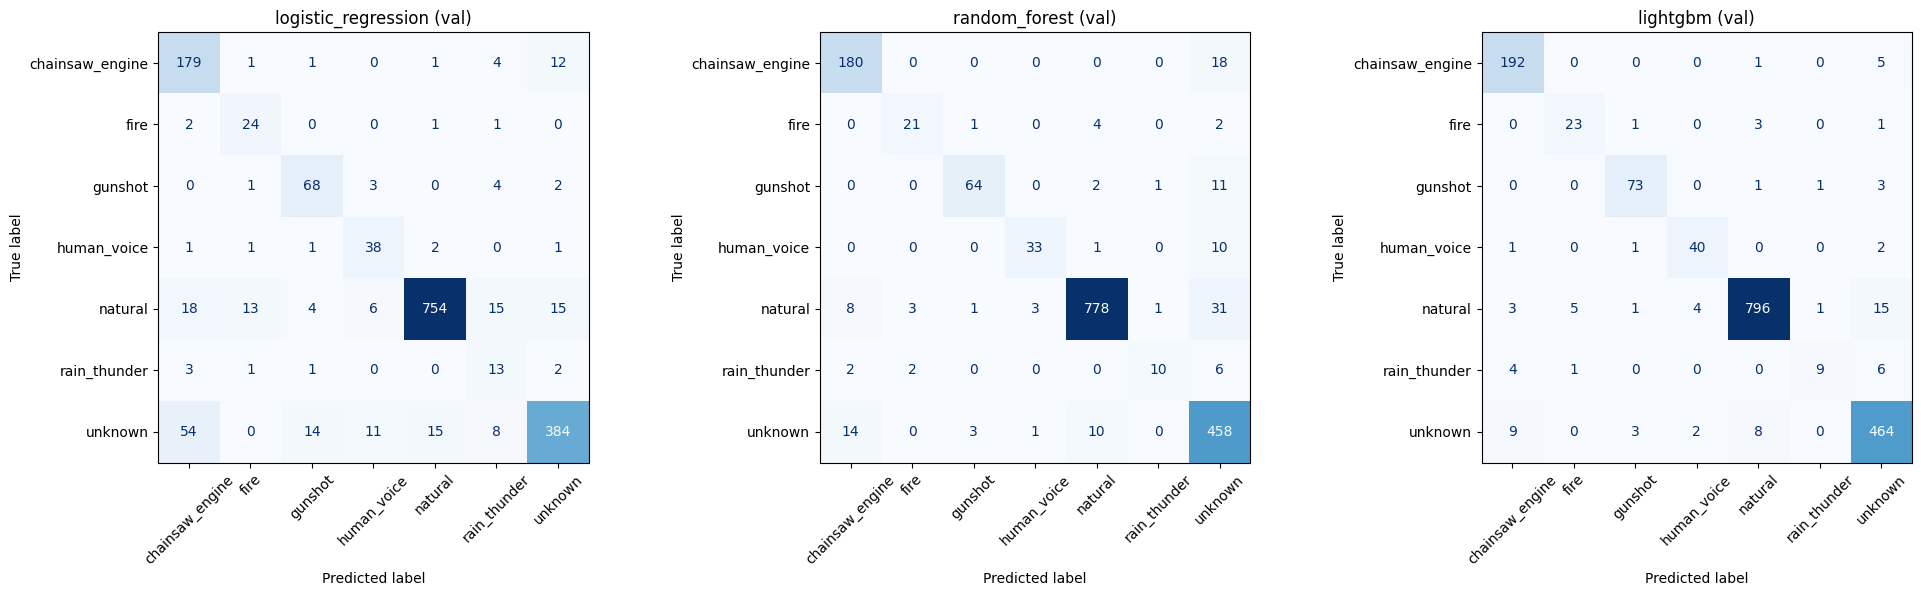

In [16]:
MODELS = {"logistic_regression": lr_best, "random_forest": rf_best, "lightgbm": lgbm_best}
SEARCHES = {"logistic_regression": lr_search, "random_forest": rf_search, "lightgbm": lgbm_search}
 
rows = []
for name, pipe in MODELS.items():
    pred = pipe.predict(X_val)
    rows.append({"model": name,
                 "cv_macro_f1": SEARCHES[name].best_score_,
                 "val_macro_f1": f1_score(y_val, pred, average="macro"),
                 "val_accuracy": (pred == y_val).mean()})
comparison_df = pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False)
print(comparison_df.round(4).to_string(index=False))
comparison_df.to_csv(f"{WORK_DIR}/model_comparison_val.csv", index=False)
 
for name, pipe in MODELS.items():
    print(f"\n===== {name} — validation classification report =====")
    print(classification_report(y_val, pipe.predict(X_val), labels=range(len(CLASS_LIST)),
                                target_names=CLASS_LIST, zero_division=0))
 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, pipe) in zip(axes, MODELS.items()):
    cm = confusion_matrix(y_val, pipe.predict(X_val), labels=range(len(CLASS_LIST)))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_LIST).plot(ax=ax, cmap="Blues",
                                                              xticks_rotation=45, colorbar=False)
    ax.set_title(f"{name} (val)")
plt.tight_layout(); plt.show()

## 🔎 2.5 — Feature Importance Analysis

Three complementary views of feature importance, one per model family:

| Method | Model | What it measures |
|---|---|---|
| Mean \|SHAP contribution\| (native `pred_contrib`) | LightGBM | Per-class push from each feature |
| Standardised coefficients | Logistic Regression | Signed feature weight per class |
| Gini impurity decrease | Random Forest | Global importance + group-level share |

The `feature_group()` helper maps each of the ~292 feature columns to one of seven named groups (`mfcc`, `mfcc_delta`, `mfcc_delta2`, `spectral_flux`, `spectral_contrast`, `spectral_shape`, `time_domain`) so the **family-level** contribution is visible alongside the individual feature ranking.


In [17]:
def feature_group(c):
    if re.match(r"mfcc_delta2_\d+_", c): return "mfcc_delta2"
    if re.match(r"mfcc_delta_\d+_", c): return "mfcc_delta"
    if re.match(r"mfcc_\d+_", c): return "mfcc"
    if c.startswith("spectral_flux"): return "spectral_flux"
    if c.startswith("spectral_contrast"): return "spectral_contrast"
    if c.startswith(("spectral_centroid", "spectral_bandwidth", "spectral_rolloff")): return "spectral_shape"
    if c.startswith(("zcr", "rms")): return "time_domain"
    return "other"
 
TOP_N = 12
feat_arr = np.array(FEATURE_COLS)
 
def plot_per_class(importance_2d, title, signed=False):
    """importance_2d: (n_classes, n_features)"""
    fig, axes = plt.subplots(4, 2, figsize=(16, 20))
    axes = axes.ravel()
    for i, cls in enumerate(CLASS_LIST):
        imp = importance_2d[i]
        top = np.argsort(np.abs(imp))[::-1][:TOP_N][::-1]
        colors = ["tab:green" if v >= 0 else "tab:red" for v in imp[top]] if signed else "tab:blue"
        axes[i].barh(feat_arr[top], imp[top], color=colors)
        axes[i].set_title(f"{cls}", fontweight="bold")
        axes[i].tick_params(axis="y", labelsize=8)
    axes[-1].axis("off")
    fig.suptitle(title, fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()
    return fig

### (a) LightGBM — Per-Class Mean |Contribution| on Validation

Native `pred_contrib` from the LightGBM booster, averaged over all validation clips and taken as absolute value per class.


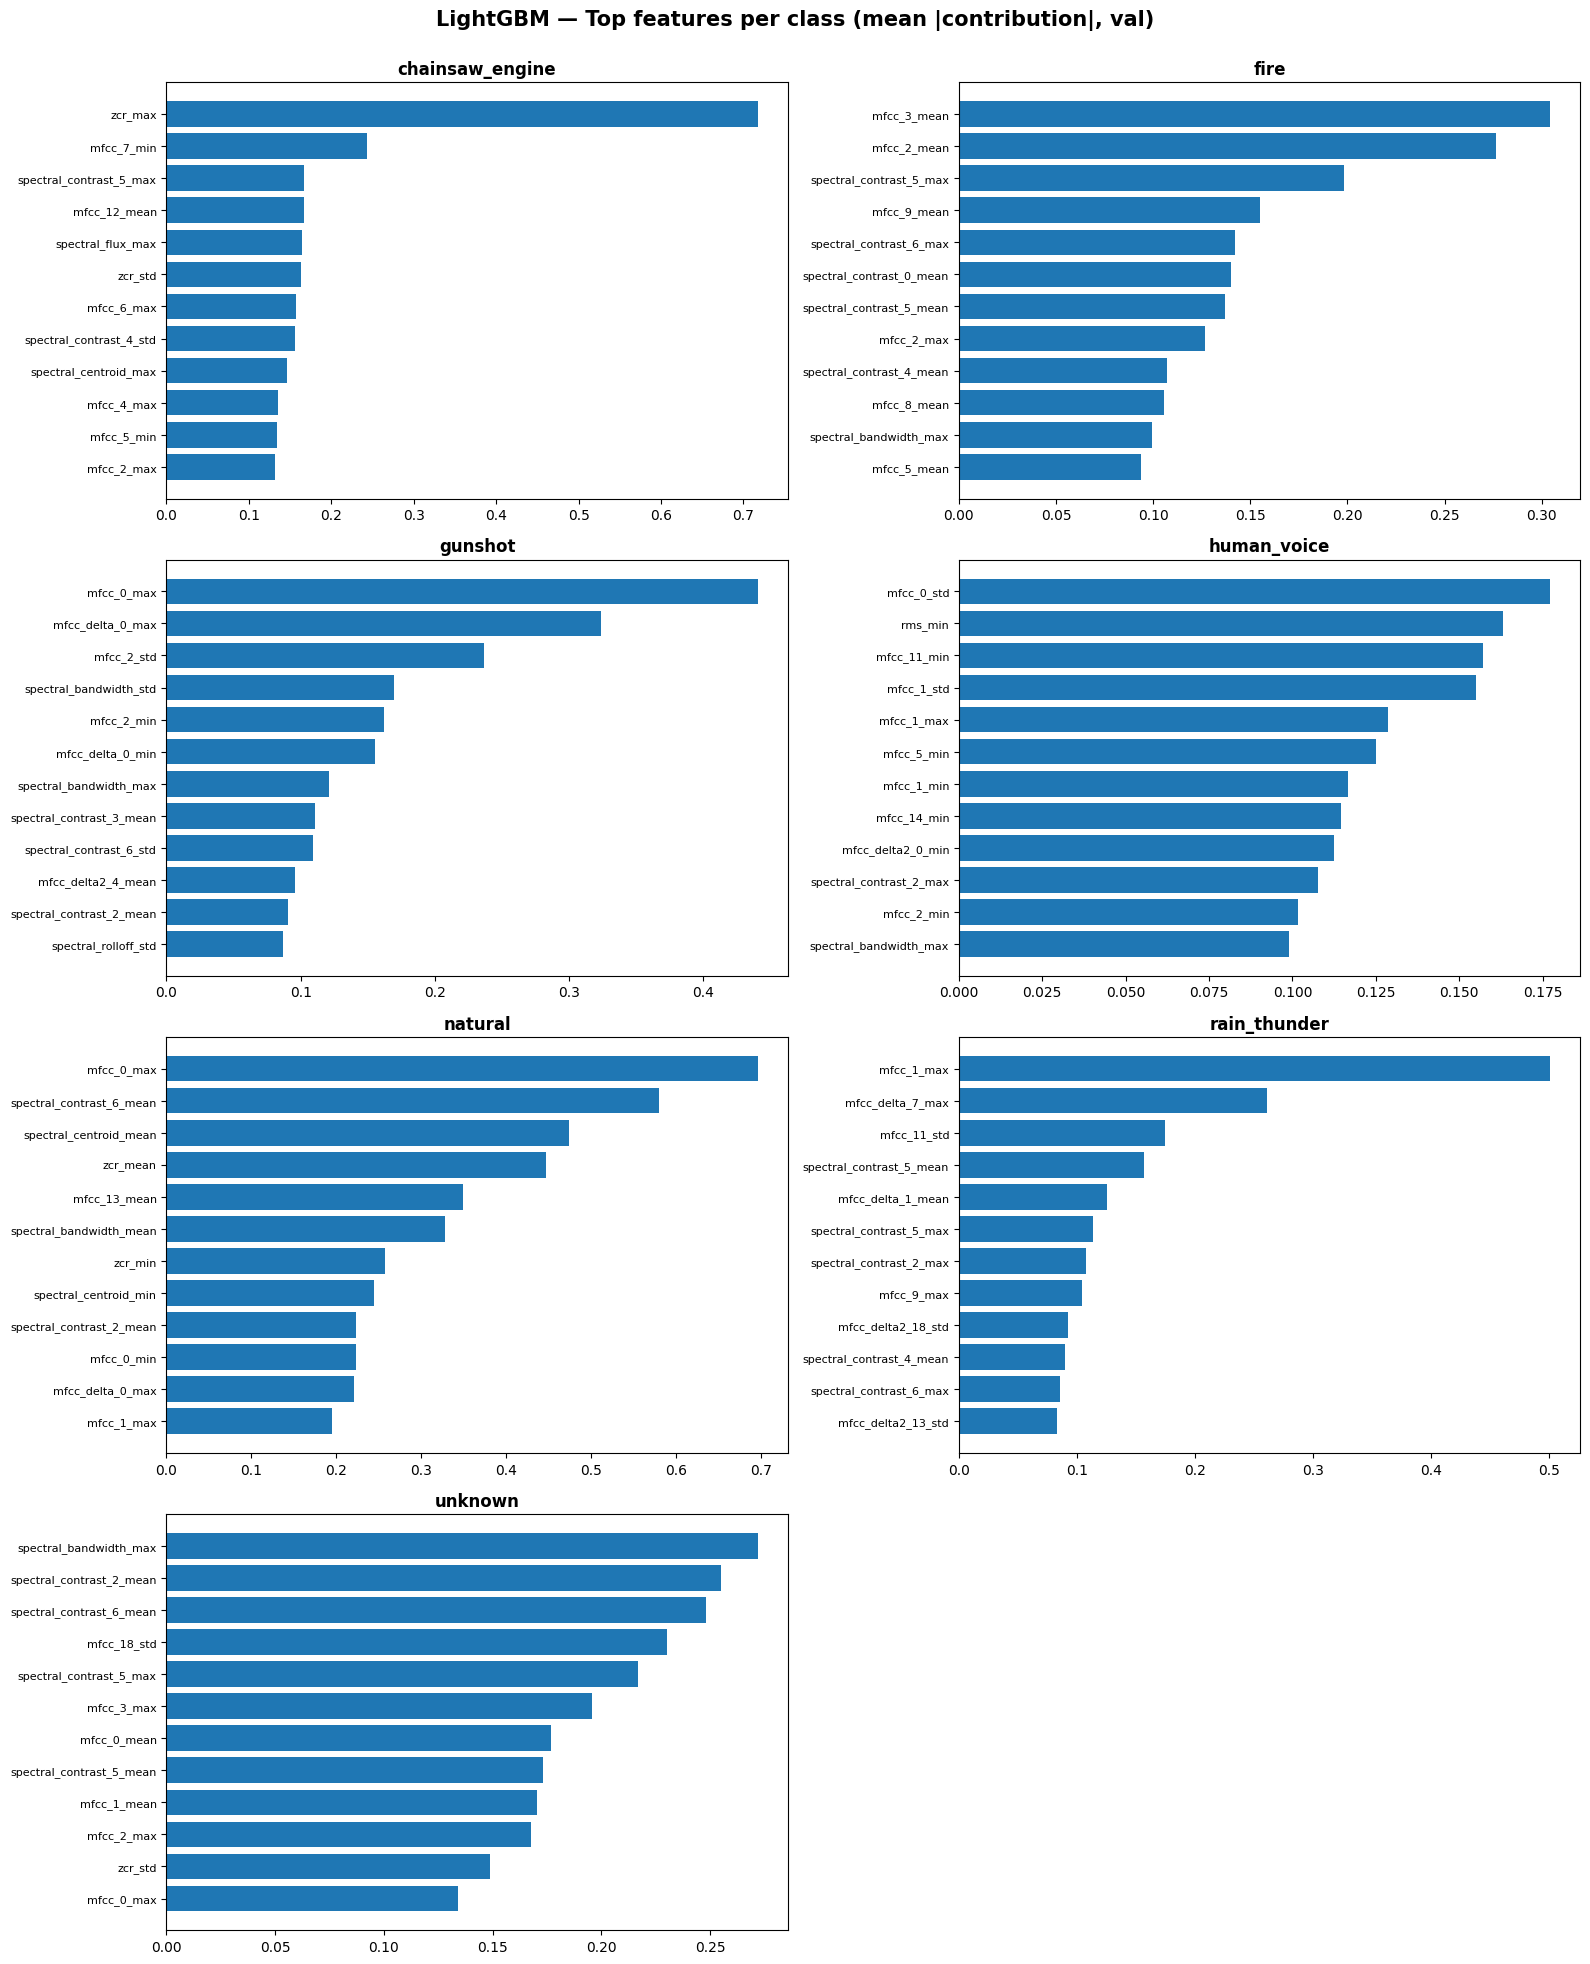

In [18]:
Xs_val = lgbm_best.named_steps["scaler"].transform(X_val)
contrib = lgbm_best.named_steps["clf"].booster_.predict(Xs_val, pred_contrib=True)
contrib = contrib.reshape(len(X_val), len(CLASS_LIST), -1)[:, :, :-1]       # drop bias term
lgbm_importance = np.abs(contrib).mean(axis=0)                              # (classes, features)
fig = plot_per_class(lgbm_importance, "LightGBM — Top features per class (mean |contribution|, val)")
fig.savefig(f"{WORK_DIR}/importance_lgbm_per_class.png", dpi=130, bbox_inches="tight")

### (b) Logistic Regression — Standardised Coefficients Per Class

Green bars push the prediction *towards* that class; red bars push *away*. Because the features are standardised inside the pipeline, coefficient magnitudes are directly comparable.


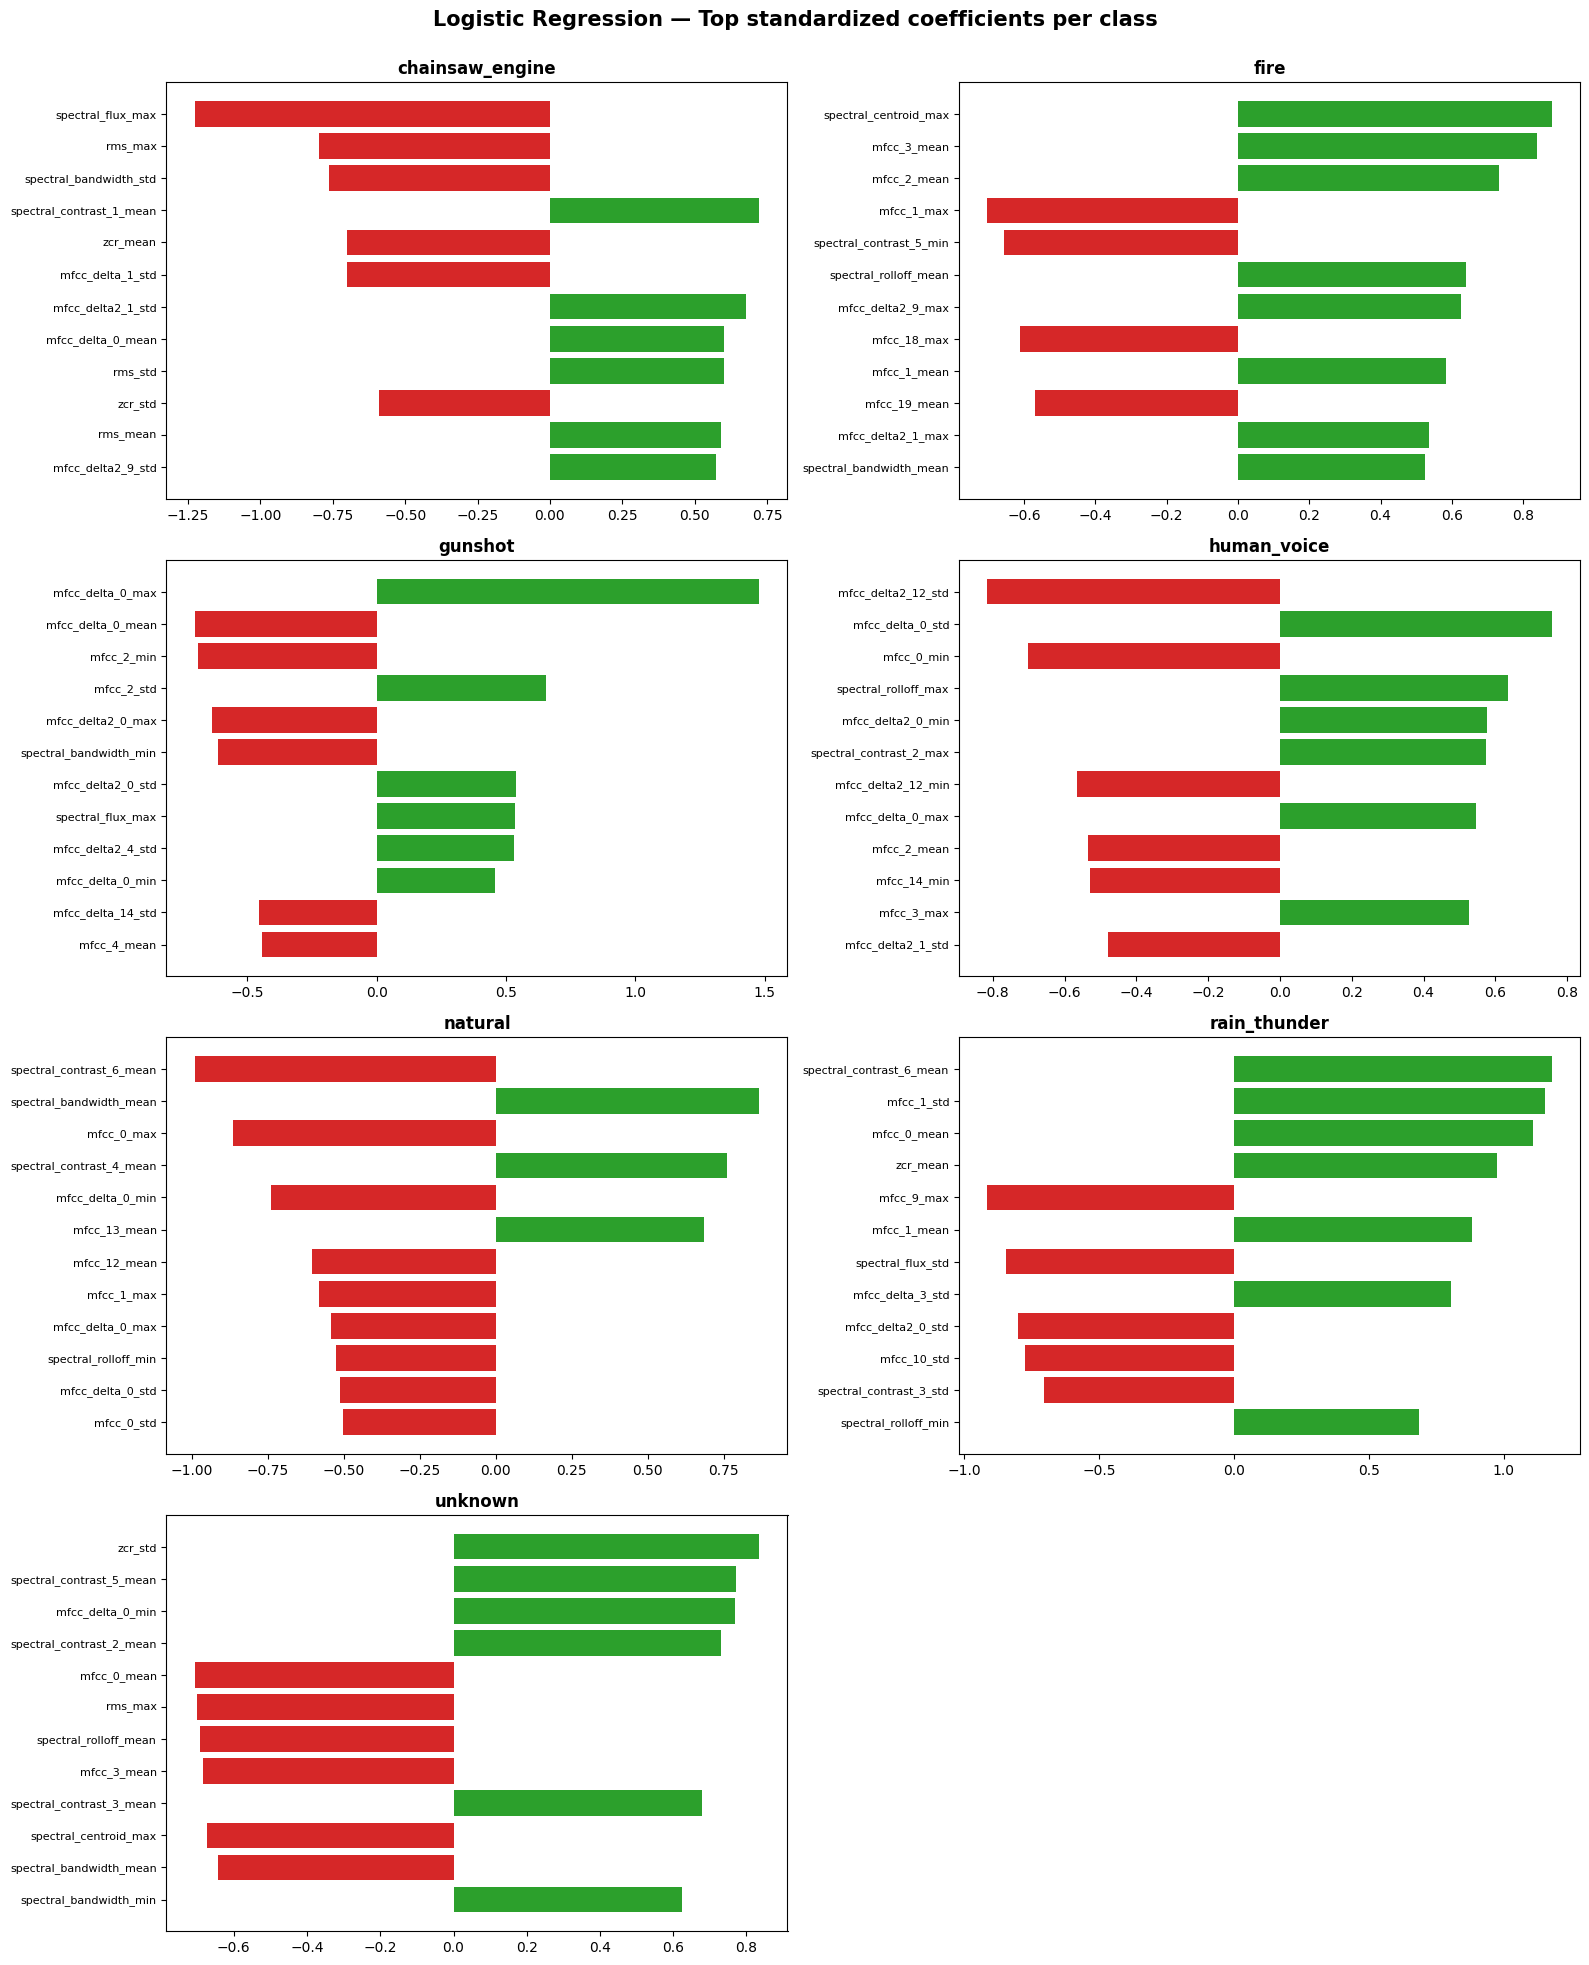

In [19]:
lr_coef = lr_best.named_steps["clf"].coef_                                  # (classes, features)
fig = plot_per_class(lr_coef, "Logistic Regression — Top standardized coefficients per class", signed=True)
fig.savefig(f"{WORK_DIR}/importance_lr_per_class.png", dpi=130, bbox_inches="tight")

### (c) Random Forest — Global Importance & Share by Feature Group

Gini-based `feature_importances_` for the top-20 features (left) and the proportion of total importance held by each feature group (right).


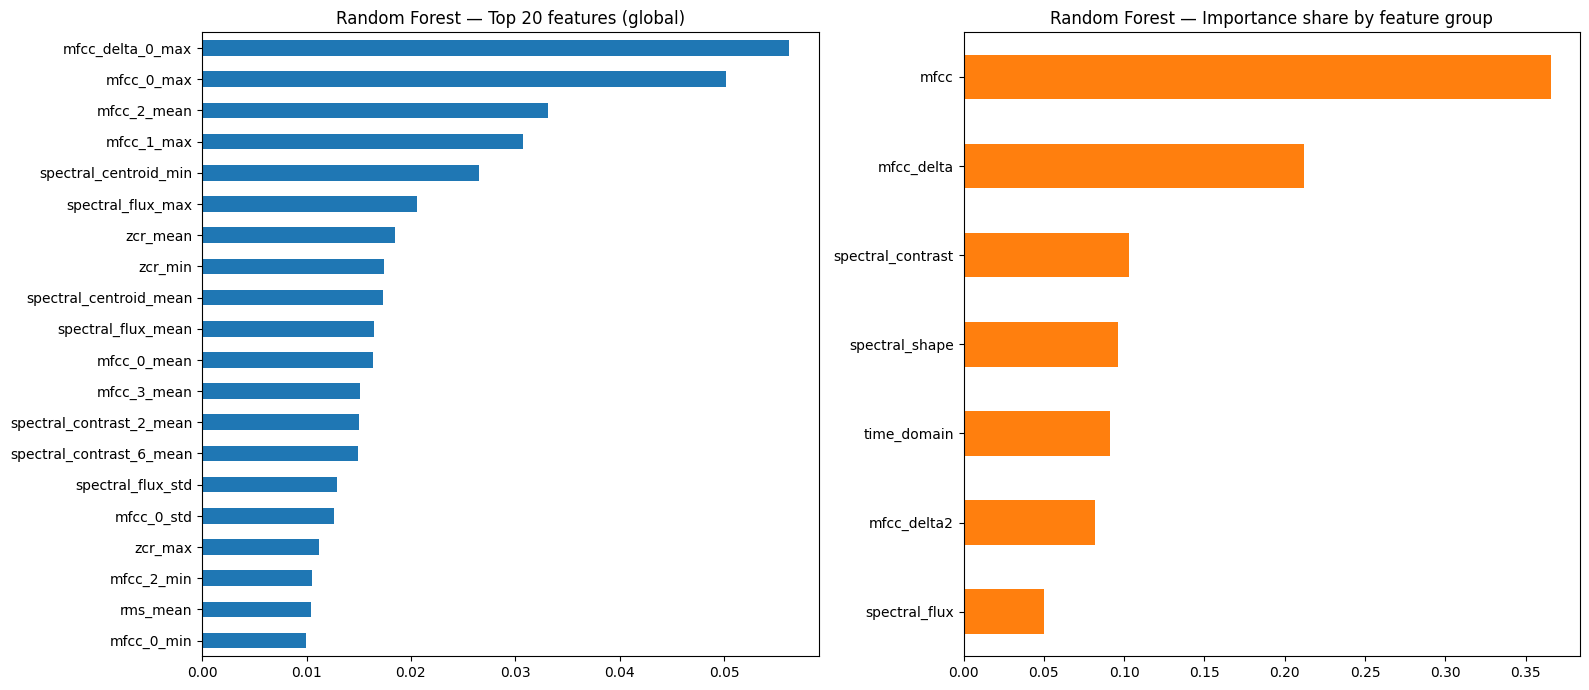

In [20]:
rf_imp = pd.Series(rf_best.named_steps["clf"].feature_importances_, index=FEATURE_COLS)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
rf_imp.sort_values().tail(20).plot.barh(ax=axes[0], color="tab:blue")
axes[0].set_title("Random Forest — Top 20 features (global)")
group_share = rf_imp.groupby(feature_group).sum().sort_values()
group_share.plot.barh(ax=axes[1], color="tab:orange")
axes[1].set_title("Random Forest — Importance share by feature group")
plt.tight_layout(); plt.show()
fig.savefig(f"{WORK_DIR}/importance_rf_global.png", dpi=130, bbox_inches="tight")

### LightGBM — Importance Share by Feature Group, Per Class

Summed mean |contribution| per feature group, broken down per target class — shows which feature families are most discriminative for each sound category.


In [21]:
grp_names = np.array([feature_group(c) for c in FEATURE_COLS])
grp_df = pd.DataFrame({cls: pd.Series(lgbm_importance[i]).groupby(grp_names).sum()
                       for i, cls in enumerate(CLASS_LIST)})
print("\nLightGBM importance by feature group (sum of mean |contribution|):")
print(grp_df.round(3).to_string())


LightGBM importance by feature group (sum of mean |contribution|):
                   chainsaw_engine   fire  gunshot  human_voice  natural  rain_thunder  unknown
mfcc                         4.234  2.402    2.185        2.390    4.627         2.111    4.451
mfcc_delta                   1.400  0.630    1.760        1.722    1.964         1.305    1.765
mfcc_delta2                  1.600  0.966    1.182        0.933    1.928         1.457    1.988
spectral_contrast            1.405  1.276    0.770        0.673    2.050         1.075    2.177
spectral_flux                0.281  0.122    0.144        0.067    0.138         0.135    0.308
spectral_shape               0.375  0.503    0.622        0.483    1.244         0.125    0.764
time_domain                  1.261  0.204    0.184        0.336    0.985         0.114    0.543


## 🔬 2.6 — Ablation Study: Value of Temporal Features

**Research question:** Do delta, delta-delta, and spectral flux features improve macro-F1 over plain MFCC mean/std, or is the simpler feature set already sufficient?

**Protocol:** Fix the best LightGBM hyperparameters from Section 2.3; vary **only the feature subset**. Evaluate with `GroupKFold` CV on training folds and independently on Fold 1 (validation).

| # | Config | Interpretation |
|---|---|---|
| 1 | MFCC mean/std only | Bare 40-feature baseline |
| 2 | + delta mean/std | Add first-order spectral dynamics |
| 3 | + delta + delta-delta | Add second-order dynamics |
| 4 | + delta + delta-delta + flux | Add spectral flux |
| 5 | FULL (~292 features) | Complete feature set |
| 6 | FULL minus delta | Ablate delta |
| 7 | FULL minus delta-delta | Ablate delta-delta |
| 8 | FULL minus spectral flux | Ablate spectral flux |
| 9 | FULL minus ALL temporal | Ablate delta + delta-delta + flux together |


1. MFCC mean/std only                         n= 40 | CV 0.7876 ± 0.0056 | VAL 0.8262
2. + delta (mean/std)                         n= 80 | CV 0.8004 ± 0.0069 | VAL 0.8332
3. + delta + delta-delta (mean/std)           n=120 | CV 0.8045 ± 0.0091 | VAL 0.8350
4. + delta + delta-delta + flux               n=124 | CV 0.8137 ± 0.0027 | VAL 0.8500
5. FULL (all features)                        n=292 | CV 0.8540 ± 0.0144 | VAL 0.8597
6. FULL minus delta                           n=212 | CV 0.8444 ± 0.0112 | VAL 0.8593
7. FULL minus delta-delta                     n=212 | CV 0.8483 ± 0.0141 | VAL 0.8440
8. FULL minus spectral flux                   n=288 | CV 0.8415 ± 0.0086 | VAL 0.8693
9. FULL minus ALL temporal (d, dd, flux)      n=128 | CV 0.8475 ± 0.0136 | VAL 0.8396


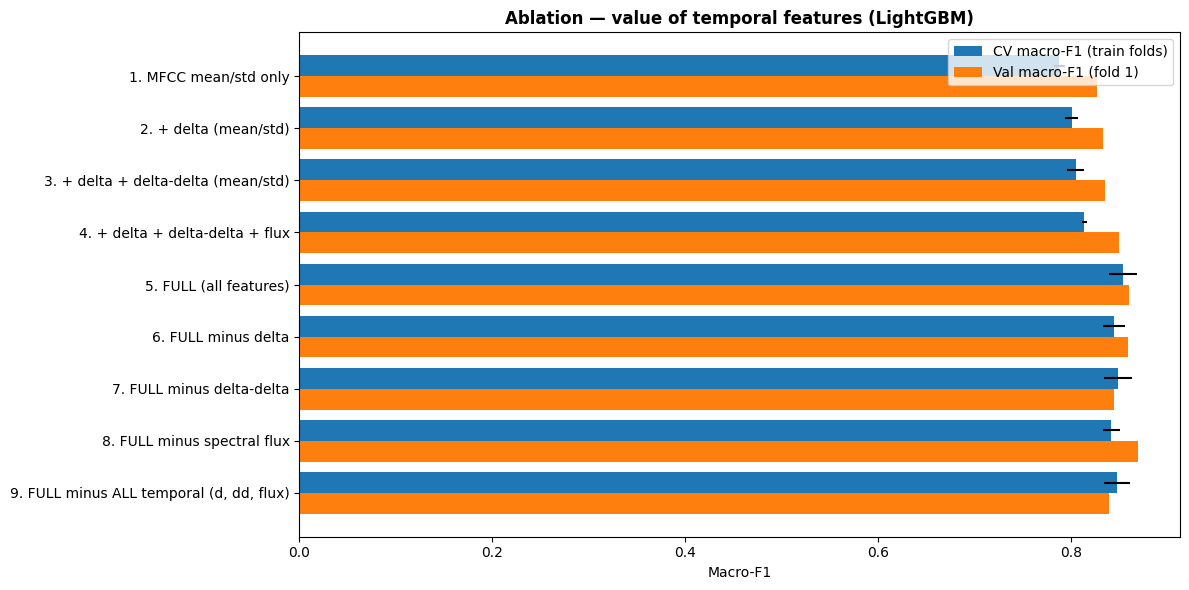

In [22]:
lgbm_params = {k.replace("clf__", ""): v for k, v in lgbm_search.best_params_.items()}
lgbm_params["n_estimators"] = min(int(lgbm_params.get("n_estimators", 300)), 300)
 
def make_lgbm_pipe():
    return make_pipe(LGBMClassifier(objective="multiclass", class_weight="balanced",
                                    subsample_freq=1, n_jobs=-1, random_state=SEED,
                                    verbose=-1, **lgbm_params))
 
def cols_where(pattern):
    return [c for c in FEATURE_COLS if re.search(pattern, c)]
 
mfcc_ms   = cols_where(r"^mfcc_\d+_(mean|std)$")
delta_ms  = cols_where(r"^mfcc_delta_\d+_(mean|std)$")
delta2_ms = cols_where(r"^mfcc_delta2_\d+_(mean|std)$")
flux_all  = cols_where(r"^spectral_flux_")
all_cols  = FEATURE_COLS
no_delta  = [c for c in all_cols if feature_group(c) != "mfcc_delta"]
no_delta2 = [c for c in all_cols if feature_group(c) != "mfcc_delta2"]
no_flux   = [c for c in all_cols if feature_group(c) != "spectral_flux"]
no_temporal = [c for c in all_cols if feature_group(c) not in ("mfcc_delta", "mfcc_delta2", "spectral_flux")]
 
ABLATIONS = {
    "1. MFCC mean/std only":                 mfcc_ms,
    "2. + delta (mean/std)":                 mfcc_ms + delta_ms,
    "3. + delta + delta-delta (mean/std)":   mfcc_ms + delta_ms + delta2_ms,
    "4. + delta + delta-delta + flux":       mfcc_ms + delta_ms + delta2_ms + flux_all,
    "5. FULL (all features)":                all_cols,
    "6. FULL minus delta":                   no_delta,
    "7. FULL minus delta-delta":             no_delta2,
    "8. FULL minus spectral flux":           no_flux,
    "9. FULL minus ALL temporal (d, dd, flux)": no_temporal,
}
 
abl_rows = []
for name, cols in ABLATIONS.items():
    pipe = make_lgbm_pipe()
    cv_scores = cross_val_score(pipe, X_train[cols], y_train, groups=g_train,
                                cv=make_cv(), scoring="f1_macro", n_jobs=1)
    pipe.fit(X_train[cols], y_train)
    v = f1_score(y_val, pipe.predict(X_val[cols]), average="macro")
    abl_rows.append({"config": name, "n_features": len(cols),
                     "cv_macro_f1": cv_scores.mean(), "cv_std": cv_scores.std(), "val_macro_f1": v})
    log_experiment("lightgbm", "ablation", {"feature_set": name, "n_features": len(cols), **lgbm_params},
                   cv_macro_f1=cv_scores.mean(), val_macro_f1=v)
    print(f"{name:<45} n={len(cols):>3} | CV {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | VAL {v:.4f}")
 
ablation_df = pd.DataFrame(abl_rows)
ablation_df.to_csv(f"{WORK_DIR}/ablation_results.csv", index=False)
 
fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(ablation_df))
ax.barh(y_pos - 0.2, ablation_df["cv_macro_f1"], 0.4, xerr=ablation_df["cv_std"], label="CV macro-F1 (train folds)")
ax.barh(y_pos + 0.2, ablation_df["val_macro_f1"], 0.4, label="Val macro-F1 (fold 1)")
ax.set_yticks(y_pos); ax.set_yticklabels(ablation_df["config"]); ax.invert_yaxis()
ax.set_xlabel("Macro-F1"); ax.set_title("Ablation — value of temporal features (LightGBM)", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()
fig.savefig(f"{WORK_DIR}/ablation_plot.png", dpi=130, bbox_inches="tight")

## 💾 2.7 — Export Final Models (joblib + Model API Contract)

Every final tuned model is packaged into a `ForestSoundModel` wrapper implementing the shared
**Model API contract** agreed upon at project start:

```python
model.predict(window: np.ndarray[48000]) -> dict[class_name: str, probability: float]
```

The wrapper embeds its own feature extraction code (identical to Israa's Step 3) so it is
**self-contained** — it takes a raw 3-second waveform and returns a probability dict with no
external dependencies beyond `librosa`. Each model is saved as:

- `models/<name>.joblib` — the serialised `ForestSoundModel` object
- `models/<name>_config.json` — full provenance (params, CV setup, macro-F1, versions)


In [23]:
MODEL_API_SRC = r'''
import numpy as np
import pandas as pd
import librosa
 
SAMPLE_RATE = 16_000
WINDOW_SAMPLES = 48_000
FRAME_LENGTH_MS = 32
HOP_LENGTH_MS = 10
N_FFT = int(SAMPLE_RATE * FRAME_LENGTH_MS / 1000)
HOP_LENGTH = int(SAMPLE_RATE * HOP_LENGTH_MS / 1000)
N_MFCC = 20
 
 
def extract_frame_level_features(wav, sr=SAMPLE_RATE):
    frame_feats = {}
    mfcc = librosa.feature.mfcc(y=wav, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    delta_mfcc = librosa.feature.delta(mfcc, order=1)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)
    for i in range(N_MFCC):
        frame_feats[f"mfcc_{i}"] = mfcc[i]
        frame_feats[f"mfcc_delta_{i}"] = delta_mfcc[i]
        frame_feats[f"mfcc_delta2_{i}"] = delta2_mfcc[i]
    frame_feats["spectral_centroid"] = librosa.feature.spectral_centroid(y=wav, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)[0]
    frame_feats["spectral_bandwidth"] = librosa.feature.spectral_bandwidth(y=wav, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)[0]
    frame_feats["spectral_rolloff"] = librosa.feature.spectral_rolloff(y=wav, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)[0]
    contrast = librosa.feature.spectral_contrast(y=wav, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    for i in range(contrast.shape[0]):
        frame_feats[f"spectral_contrast_{i}"] = contrast[i]
    frame_feats["zcr"] = librosa.feature.zero_crossing_rate(wav, frame_length=N_FFT, hop_length=HOP_LENGTH)[0]
    frame_feats["rms"] = librosa.feature.rms(y=wav, frame_length=N_FFT, hop_length=HOP_LENGTH)[0]
    stft_mag = np.abs(librosa.stft(wav, n_fft=N_FFT, hop_length=HOP_LENGTH))
    flux = np.sqrt(np.sum(np.diff(stft_mag, axis=1) ** 2, axis=0))
    frame_feats["spectral_flux"] = np.concatenate([[0.0], flux])
    return frame_feats
 
 
def aggregate_features(frame_feats):
    agg = {}
    for name, series in frame_feats.items():
        series = np.nan_to_num(series, nan=0.0, posinf=0.0, neginf=0.0)
        agg[f"{name}_mean"] = float(np.mean(series))
        agg[f"{name}_std"] = float(np.std(series))
        agg[f"{name}_min"] = float(np.min(series))
        agg[f"{name}_max"] = float(np.max(series))
    return agg
 
 
class ForestSoundModel:
    """Model API contract: predict(window) -> dict[class, prob]. Carries its own config."""
 
    def __init__(self, pipeline, class_names, feature_cols, config):
        self.pipeline = pipeline
        self.class_names = list(class_names)     # index -> class name
        self.feature_cols = list(feature_cols)   # exact training column order
        self.config = dict(config)
 
    def predict(self, window):
        w = np.asarray(window, dtype=np.float32).ravel()
        if len(w) < WINDOW_SAMPLES:
            w = np.pad(w, (0, WINDOW_SAMPLES - len(w)))
        elif len(w) > WINDOW_SAMPLES:
            w = w[:WINDOW_SAMPLES]
        feats = aggregate_features(extract_frame_level_features(w, SAMPLE_RATE))
        x = pd.DataFrame([feats]).reindex(columns=self.feature_cols)
        proba = self.pipeline.predict_proba(x)[0]
        out = {c: 0.0 for c in self.class_names}
        for cls_idx, p in zip(self.pipeline.classes_, proba):
            out[self.class_names[int(cls_idx)]] = float(p)
        return out
'''
with open(f"{WORK_DIR}/forest_model_api.py", "w") as f:
    f.write(MODEL_API_SRC)
 
if WORK_DIR not in sys.path:
    sys.path.insert(0, WORK_DIR)
import forest_model_api
importlib.reload(forest_model_api)
from forest_model_api import ForestSoundModel
print("forest_model_api.py written and imported.")
 
# %% CELL A10 — Export the final tuned models with joblib (+ config)
import sklearn, lightgbm
EXPORTED = {}
for name, pipe in MODELS.items():
    config = {
        "model_name": name,
        "owner": "Developer A",
        "best_params": SEARCHES[name].best_params_,
        "cv": f"GroupKFold(n_splits={CV_SPLITS}) on group_id, train folds {TRAIN_FOLDS}",
        "cv_macro_f1": round(float(SEARCHES[name].best_score_), 4),
        "val_fold": VAL_FOLD,
        "val_macro_f1": round(float(val_macro_f1(pipe)), 4),
        "class_names": CLASS_LIST,
        "n_features": len(FEATURE_COLS),
        "sample_rate": 16000, "window_samples": 48000,
        "class_weight": "balanced",
        "seed": SEED,
        "versions": {"sklearn": sklearn.__version__, "lightgbm": lightgbm.__version__},
        "created": datetime.now().isoformat(timespec="seconds"),
        "api": "predict(window: np.ndarray[48000]) -> dict[class, prob]",
        "requires": "forest_model_api.py on PYTHONPATH when loading",
    }
    model_obj = ForestSoundModel(pipe, CLASS_LIST, FEATURE_COLS, config)
    path = f"{MODEL_DIR}/{name}.joblib"
    joblib.dump(model_obj, path, compress=3)
    with open(f"{MODEL_DIR}/{name}_config.json", "w") as f:
        json.dump(config, f, indent=2, default=str)
    EXPORTED[name] = path
    print(f"Saved {name:<20} -> {path} (val macro-F1 {config['val_macro_f1']})")

forest_model_api.py written and imported.
Saved logistic_regression  -> /kaggle/working/models/logistic_regression.joblib (val macro-F1 0.7482)
Saved random_forest        -> /kaggle/working/models/random_forest.joblib (val macro-F1 0.8344)
Saved lightgbm             -> /kaggle/working/models/lightgbm.joblib (val macro-F1 0.867)


logistic_regression: API contract OK, matches batch predictions.
random_forest: API contract OK, matches batch predictions.
lightgbm: API contract OK, matches batch predictions.


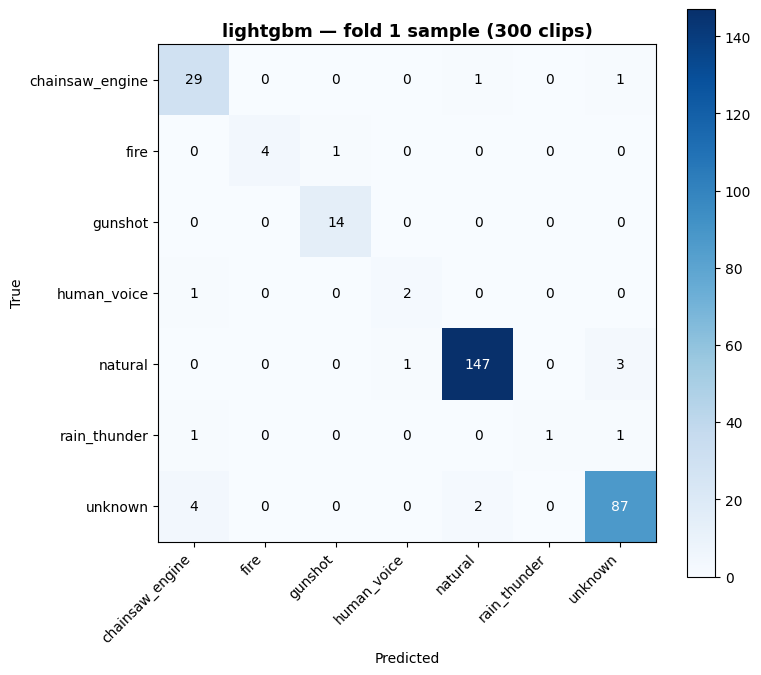


Classification Report:
                 precision    recall  f1-score   support

chainsaw_engine       0.83      0.94      0.88        31
           fire       1.00      0.80      0.89         5
        gunshot       0.93      1.00      0.97        14
    human_voice       0.67      0.67      0.67         3
        natural       0.98      0.97      0.98       151
   rain_thunder       1.00      0.33      0.50         3
        unknown       0.95      0.94      0.94        93

       accuracy                           0.95       300
      macro avg       0.91      0.81      0.83       300
   weighted avg       0.95      0.95      0.95       300

Macro-F1: 0.8310


In [24]:
import soundfile as sf
full_meta = pd.read_csv(METADATA_PATH)
val_meta = full_meta[full_meta["fold"] == VAL_FOLD].reset_index(drop=True)   # fold 1 only
 
for name, path in EXPORTED.items():
    loaded = joblib.load(path)
    for i in range(3):
        wav, _ = sf.read(val_meta.loc[i, "file_path"], dtype="float32")
        probs = loaded.predict(wav)
        assert set(probs) == set(CLASS_LIST) and abs(sum(probs.values()) - 1) < 1e-4
        batch = loaded.pipeline.predict_proba(val_df.loc[val_df["clip_id"] == val_meta.loc[i, "clip_id"], FEATURE_COLS])[0]
        assert np.allclose([probs[c] for c in CLASS_LIST], batch, atol=1e-4), "predict() != batch features!"
    print(f"{name}: API contract OK, matches batch predictions.")
 
# Optional: run Israa's Step 6 harness on VALIDATION (never on the test split here)
if "run_model_on_test_set" in globals():
    best_name = comparison_df.iloc[0]["model"]
    best_loaded = joblib.load(EXPORTED[best_name])
    val_sample = val_meta.sample(n=min(300, len(val_meta)), random_state=SEED)
    res = run_model_on_test_set(best_loaded.predict, val_sample.assign(split="val"), split="val")
    _ = plot_confusion_matrix(res, title=f"{best_name} — fold 1 sample (300 clips)")

## 📋 2.8 — Experiment Log Summary

Full history of every tuning trial and ablation run, with `cv_macro_f1` and `val_macro_f1` tracked per row. Persisted to `experiments_log.csv` for auditing and reproducibility.


In [25]:
log_df = pd.read_csv(EXP_LOG_PATH)
print(f"{len(log_df)} experiments logged -> {EXP_LOG_PATH}")
print(log_df[log_df["stage"].isin(["final", "ablation"])]
      [["model", "stage", "cv_macro_f1", "val_macro_f1"]].to_string(index=False))


41 experiments logged -> /kaggle/working/experiments_log.csv
              model    stage  cv_macro_f1  val_macro_f1
logistic_regression    final       0.7440        0.7482
      random_forest    final       0.8137        0.8344
           lightgbm    final       0.8546        0.8670
           lightgbm ablation       0.7876        0.8262
           lightgbm ablation       0.8004        0.8332
           lightgbm ablation       0.8045        0.8350
           lightgbm ablation       0.8137        0.8500
           lightgbm ablation       0.8540        0.8597
           lightgbm ablation       0.8444        0.8593
           lightgbm ablation       0.8483        0.8440
           lightgbm ablation       0.8415        0.8693
           lightgbm ablation       0.8475        0.8396


---

# 👩‍💻 Part 3 — Developer B: Advanced Boosting & SVM
### Eng. Jomanah

---

## Overview

This section covers the **advanced classical ML models** — a kernel-based SVM and two
state-of-the-art gradient-boosting frameworks — plus the additional Developer B responsibilities.

| Model | Type | Notes |
|---|---|---|
| **SVM (RBF kernel)** | Kernel method | Non-linear boundaries; C × gamma grid |
| **XGBoost** | Gradient Boosting | 30-trial random search with early stopping |
| **CatBoost** | Gradient Boosting | Grid: depth × learning rate × L2 regularisation |

**Additional Developer B responsibilities:**
- ⏱️ **Latency measurement** — feature extraction + inference time per 3-second window
- 🔎 **Error analysis** — top confusion pairs and per-class classification report
- 📊 **XGBoost feature importance** — top-20 features driving the best boosting model

**ML Rules followed:**
- ✅ Train on Folds 2–9 · Validate on Fold 1 · **Fold 0 used only for final evaluation**
- ✅ `StandardScaler` inside every `sklearn Pipeline`
- ✅ Class imbalance handled via `class_weight='balanced'` / `auto_class_weights='Balanced'` / `compute_sample_weight`
- ✅ Model selection based exclusively on **validation macro-F1** — test set is never consulted for selection


## ⚙️ 3.1 — Data Preparation & Feature Extraction

Load `metadata.csv` from Israa's Step 2 and extract the same acoustic feature set (MFCC + deltas + spectral descriptors) used across the whole project.
Build `X_train / X_val / X_test` arrays with label-encoded targets.

| Split | Source | Role |
|---|---|---|
| `X_train` / `y_train` | Folds 2–9 | Model fitting |
| `X_val` / `y_val` | Fold 1 | Hyperparameter selection |
| `X_test` / `y_test` | Fold 0 | **Frozen** — final evaluation only |

> The feature extraction wall-clock time printed here is the baseline for Section 3.8C (Latency).


In [26]:
# ==============================================================================
# CLASSICAL ML — DEVELOPER B
# SECTION 1: DATA PREPARATION + FEATURE EXTRACTION
# ==============================================================================

import os
import time
import numpy as np
import pandas as pd
import librosa

from sklearn.preprocessing import LabelEncoder

# ------------------------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------------------------

METADATA_PATH = "/kaggle/working/metadata.csv"

SAMPLE_RATE = 16_000
N_FFT = 512
HOP_LENGTH = 160
N_MFCC = 20

CLASS_LIST = [
    "natural",
    "rain_thunder",
    "gunshot",
    "fire",
    "chainsaw_engine",
    "human_voice",
    "unknown"
]

RANDOM_SEED = 42

# ------------------------------------------------------------------------------
# CHECK METADATA
# ------------------------------------------------------------------------------

if not os.path.exists(METADATA_PATH):
    raise FileNotFoundError(
        f"metadata.csv not found: {METADATA_PATH}"
    )

metadata_df = pd.read_csv(METADATA_PATH)

print("=" * 80)
print("CLASSICAL ML — SECTION 1")
print("=" * 80)

print("Metadata shape:", metadata_df.shape)
print("\nColumns:")
print(metadata_df.columns.tolist())

print("\nSplit distribution:")
print(metadata_df["split"].value_counts())

print("\nClass distribution:")
print(metadata_df["class"].value_counts())

# ------------------------------------------------------------------------------
# FEATURE EXTRACTION FUNCTIONS
# ------------------------------------------------------------------------------

def extract_frame_level_features(wav, sr=16000):

    # Make audio mono
    if wav.ndim > 1:
        wav = np.mean(wav, axis=1)

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=wav,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    # MFCC delta
    delta_mfcc = librosa.feature.delta(mfcc)

    # MFCC delta-delta
    delta2_mfcc = librosa.feature.delta(
        mfcc,
        order=2
    )

    # Spectral features
    spectral_centroid = librosa.feature.spectral_centroid(
        y=wav,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=wav,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=wav,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    spectral_contrast = librosa.feature.spectral_contrast(
        y=wav,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    zero_crossing_rate = librosa.feature.zero_crossing_rate(
        wav,
        hop_length=HOP_LENGTH
    )

    rms = librosa.feature.rms(
        y=wav,
        frame_length=N_FFT,
        hop_length=HOP_LENGTH
    )

    # Spectral flux
    stft = np.abs(
        librosa.stft(
            wav,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH
        )
    )

    spectral_flux = np.sqrt(
        np.sum(
            np.diff(stft, axis=1) ** 2,
            axis=0
        )
    )

    # Put everything into one dictionary
    frame_features = {}

    for i in range(N_MFCC):
        frame_features[f"mfcc_{i+1}"] = mfcc[i]

    for i in range(N_MFCC):
        frame_features[f"delta_mfcc_{i+1}"] = delta_mfcc[i]

    for i in range(N_MFCC):
        frame_features[f"delta2_mfcc_{i+1}"] = delta2_mfcc[i]

    frame_features["spectral_centroid"] = spectral_centroid[0]
    frame_features["spectral_bandwidth"] = spectral_bandwidth[0]
    frame_features["spectral_rolloff"] = spectral_rolloff[0]

    for i in range(spectral_contrast.shape[0]):
        frame_features[f"spectral_contrast_{i+1}"] = spectral_contrast[i]

    frame_features["zero_crossing_rate"] = zero_crossing_rate[0]
    frame_features["rms"] = rms[0]

    # Make spectral flux same length as the other frame features
    flux = np.asarray(spectral_flux)

    if len(flux) == 0:
        flux = np.zeros(1)

    frame_features["spectral_flux"] = flux

    return frame_features


# ------------------------------------------------------------------------------
# AGGREGATE FRAME FEATURES
# ------------------------------------------------------------------------------

def aggregate_features(frame_features):

    feature_vector = {}

    for name, values in frame_features.items():

        values = np.asarray(values, dtype=float)

        values = values[np.isfinite(values)]

        if len(values) == 0:
            values = np.array([0.0])

        feature_vector[f"{name}_mean"] = np.mean(values)
        feature_vector[f"{name}_std"] = np.std(values)
        feature_vector[f"{name}_min"] = np.min(values)
        feature_vector[f"{name}_max"] = np.max(values)

    return feature_vector


# ------------------------------------------------------------------------------
# EXTRACT FEATURES FROM ALL CLIPS
# ------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("EXTRACTING CLASSICAL ML FEATURES")
print("=" * 80)

feature_rows = []

failed_files = []

start_time = time.time()

for i, row in metadata_df.iterrows():

    file_path = row["file_path"]

    try:

        # Load audio
        wav, sr = librosa.load(
            file_path,
            sr=SAMPLE_RATE,
            mono=True
        )

        # Frame-level features
        frame_features = extract_frame_level_features(
            wav,
            sr=SAMPLE_RATE
        )

        # Aggregate into one feature vector
        feature_vector = aggregate_features(
            frame_features
        )

        # Add metadata
        feature_vector["clip_id"] = row["clip_id"]
        feature_vector["class"] = row["class"]
        feature_vector["split"] = row["split"]
        feature_vector["group_id"] = row["group_id"]

        feature_rows.append(feature_vector)

    except Exception as e:

        failed_files.append({
            "clip_id": row["clip_id"],
            "file_path": file_path,
            "error": str(e)
        })

    # Progress
    if (i + 1) % 500 == 0:
        print(
            f"Processed {i + 1}/{len(metadata_df)} clips"
        )

# ------------------------------------------------------------------------------
# CREATE FEATURE DATAFRAME
# ------------------------------------------------------------------------------

features_df = pd.DataFrame(feature_rows)

print("\n" + "=" * 80)
print("FEATURE EXTRACTION COMPLETE")
print("=" * 80)

print("Successful clips:", len(features_df))
print("Failed clips:", len(failed_files))

if len(failed_files) > 0:
    print("\nFirst failed files:")
    print(pd.DataFrame(failed_files).head())

# ------------------------------------------------------------------------------
# FEATURE COLUMNS
# ------------------------------------------------------------------------------

ID_COLUMNS = [
    "clip_id",
    "class",
    "split",
    "group_id"
]

FEATURE_COLUMNS = [
    col
    for col in features_df.columns
    if col not in ID_COLUMNS
]

print("\nNumber of features:", len(FEATURE_COLUMNS))
print("Feature matrix shape:", features_df[FEATURE_COLUMNS].shape)

# ------------------------------------------------------------------------------
# CLEAN NUMERICAL FEATURES
# ------------------------------------------------------------------------------

features_df[FEATURE_COLUMNS] = (
    features_df[FEATURE_COLUMNS]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# ------------------------------------------------------------------------------
# CREATE X / y USING EXISTING SPLITS
# ------------------------------------------------------------------------------

train_mask = features_df["split"] == "train"
val_mask = features_df["split"] == "val"
test_mask = features_df["split"] == "test"

X_train = features_df.loc[
    train_mask,
    FEATURE_COLUMNS
].values

X_val = features_df.loc[
    val_mask,
    FEATURE_COLUMNS
].values

X_test = features_df.loc[
    test_mask,
    FEATURE_COLUMNS
].values

# ------------------------------------------------------------------------------
# LABEL ENCODING
# ------------------------------------------------------------------------------

label_encoder = LabelEncoder()

label_encoder.fit(CLASS_LIST)

y_train = label_encoder.transform(
    features_df.loc[train_mask, "class"]
)

y_val = label_encoder.transform(
    features_df.loc[val_mask, "class"]
)

y_test = label_encoder.transform(
    features_df.loc[test_mask, "class"]
)

# ------------------------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL DATA PREPARATION")
print("=" * 80)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\nClasses:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

print("\nFeature extraction time:",
      round(time.time() - start_time, 2),
      "seconds")

CLASSICAL ML — SECTION 1
Metadata shape: (16834, 12)

Columns:
['clip_id', 'file_path', 'class', 'source_dataset', 'orig_filename', 'window_index', 'md5_hash', 'duration_sec', 'sample_rate', 'group_id', 'fold', 'split']

Split distribution:
split
train    13471
test      1684
val       1679
Name: count, dtype: int64

Class distribution:
class
natural            8334
unknown            4762
chainsaw_engine    2124
gunshot             724
human_voice         451
fire                279
rain_thunder        160
Name: count, dtype: int64

EXTRACTING CLASSICAL ML FEATURES
Processed 500/16834 clips
Processed 1000/16834 clips
Processed 1500/16834 clips
Processed 2000/16834 clips
Processed 2500/16834 clips
Processed 3000/16834 clips
Processed 3500/16834 clips
Processed 4000/16834 clips
Processed 4500/16834 clips
Processed 5000/16834 clips
Processed 5500/16834 clips
Processed 6000/16834 clips
Processed 6500/16834 clips
Processed 7000/16834 clips
Processed 7500/16834 clips
Processed 8000/16834 cl

## 1️⃣ Model 1 — Support Vector Machine (RBF Kernel)

SVMs with the **Radial Basis Function kernel** project the input feature space into an
implicit infinite-dimensional Hilbert space, learning highly non-linear decision boundaries
while maximising the margin between classes.

**Tuning:** Full grid over `C` (regularisation strength) × `gamma` (kernel bandwidth).

| Hyperparameter | Values searched |
|---|---|
| `C` | 1, 10, 100 |
| `gamma` | `'scale'` (default heuristic), 0.001, 0.01 |

**Total configurations evaluated:** 9 · Best selected by validation macro-F1.

> **Pipeline note:** `StandardScaler` is applied *inside* the `Pipeline` so scaling is
> fitted only on `X_train` — critical for SVMs, which are highly sensitive to feature scale.


In [27]:
# ==============================================================================
# SECTION 2: SVM — RBF KERNEL
# ==============================================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import f1_score

print("=" * 80)
print("SVM — RBF")
print("=" * 80)

svm_configs = [
    {"C": 1, "gamma": "scale"},
    {"C": 10, "gamma": "scale"},
    {"C": 100, "gamma": "scale"},

    {"C": 1, "gamma": 0.001},
    {"C": 10, "gamma": 0.001},
    {"C": 100, "gamma": 0.001},

    {"C": 1, "gamma": 0.01},
    {"C": 10, "gamma": 0.01},
    {"C": 100, "gamma": 0.01},
]

svm_results = []

best_svm = None
best_svm_score = -np.inf

for config in svm_configs:

    model = Pipeline([
        ("scaler", StandardScaler()),

        ("svm", SVC(
            kernel="rbf",
            C=config["C"],
            gamma=config["gamma"],
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_SEED
        ))
    ])

    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)

    val_f1 = f1_score(
        y_val,
        val_pred,
        average="macro"
    )

    svm_results.append({
        "C": config["C"],
        "gamma": config["gamma"],
        "val_macro_f1": val_f1
    })

    print(
        f"C={config['C']:<3} "
        f"gamma={str(config['gamma']):<8} "
        f"Val Macro-F1={val_f1:.4f}"
    )

    if val_f1 > best_svm_score:

        best_svm_score = val_f1
        best_svm = {
            "model": model,
            "C": config["C"],
            "gamma": config["gamma"],
            "val_macro_f1": val_f1
        }

print("\nBest SVM:")
print(best_svm)

SVM — RBF
C=1   gamma=scale    Val Macro-F1=0.8231
C=10  gamma=scale    Val Macro-F1=0.8632
C=100 gamma=scale    Val Macro-F1=0.8496
C=1   gamma=0.001    Val Macro-F1=0.7447
C=10  gamma=0.001    Val Macro-F1=0.8307
C=100 gamma=0.001    Val Macro-F1=0.8471
C=1   gamma=0.01     Val Macro-F1=0.7759
C=10  gamma=0.01     Val Macro-F1=0.7807
C=100 gamma=0.01     Val Macro-F1=0.7807

Best SVM:
{'model': Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 SVC(C=10, class_weight='balanced', probability=True,
                     random_state=42))]), 'C': 10, 'gamma': 'scale', 'val_macro_f1': 0.863232500412148}


## 2️⃣ Model 2 — XGBoost

XGBoost builds an additive ensemble of decision trees **sequentially**, where each new tree
fits the residual errors of all previous trees. L1/L2 regularisation and row/column subsampling
control over-fitting. **Early stopping** (`early_stopping_rounds=40`) is used to find the
optimal number of trees automatically, avoiding costly manual grid search over `n_estimators`.

**Tuning:** 30-trial random search with `n_estimators=1500` max.

| Hyperparameter | Search range |
|---|---|
| `max_depth` | `randint` [3, 10] |
| `learning_rate` | log-uniform [0.01, 0.2] |
| `min_child_weight` | choice {1, 3, 5, 10} |
| `subsample` | uniform [0.6, 1.0] |
| `colsample_bytree` | uniform [0.4, 1.0] |
| `reg_lambda` (L2) | log-uniform [0.1, 20] |
| `reg_alpha` (L1) | log-uniform [1e-4, 5] |
| `gamma` (min split loss) | choice {0, 0.1, 0.5, 1} |

Class imbalance is addressed with `compute_sample_weight('balanced', y_train)` passed as the `sample_weight` argument to `.fit()`.


In [28]:
# ==============================================================================
# SECTION 3: XGBOOST
# ==============================================================================

from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

print("=" * 80)
print("XGBOOST")
print("=" * 80)

N_CLASSES = len(CLASS_LIST)

xgb_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

rng = np.random.default_rng(RANDOM_SEED)


def generate_xgb_params():

    return {
        "max_depth": int(
            rng.integers(3, 10)
        ),

        "learning_rate": float(
            10 ** rng.uniform(
                np.log10(0.01),
                np.log10(0.2)
            )
        ),

        "min_child_weight": int(
            rng.choice([1, 3, 5, 10])
        ),

        "subsample": float(
            rng.uniform(0.6, 1.0)
        ),

        "colsample_bytree": float(
            rng.uniform(0.4, 1.0)
        ),

        "reg_lambda": float(
            10 ** rng.uniform(
                np.log10(0.1),
                np.log10(20)
            )
        ),

        "reg_alpha": float(
            10 ** rng.uniform(
                np.log10(0.0001),
                np.log10(5)
            )
        ),

        "gamma": float(
            rng.choice([0, 0.1, 0.5, 1])
        )
    }


N_XGB_TRIALS = 30

xgb_results = []

best_xgb = None
best_xgb_score = -np.inf

for trial in range(N_XGB_TRIALS):

    params = generate_xgb_params()

    model = XGBClassifier(
        n_estimators=1500,

        objective="multi:softprob",
        num_class=N_CLASSES,

        eval_metric="mlogloss",

        tree_method="hist",

        early_stopping_rounds=40,

        random_state=RANDOM_SEED + trial,

        n_jobs=-1,

        **params
    )

    model.fit(
        X_train,
        y_train,

        sample_weight=xgb_weights,

        eval_set=[
            (X_val, y_val)
        ],

        verbose=False
    )

    val_pred = model.predict(X_val)

    val_f1 = f1_score(
        y_val,
        val_pred,
        average="macro"
    )

    best_iteration = model.best_iteration

    if best_iteration is not None and best_iteration >= 0:
        n_estimators_best = best_iteration + 1
    else:
        n_estimators_best = 1500

    result = {
        **params,
        "n_estimators": n_estimators_best,
        "val_macro_f1": val_f1
    }

    xgb_results.append(result)

    print(
        f"Trial {trial + 1:02d}/{N_XGB_TRIALS} "
        f"| Val Macro-F1 = {val_f1:.4f}"
    )

    if val_f1 > best_xgb_score:
        best_xgb_score = val_f1

        best_xgb = {
            k: v for k, v in result.items() if k != "val_macro_f1"
        }

print("\nBest XGBoost parameters:")
print(best_xgb)

XGBOOST
Trial 01/30 | Val Macro-F1 = 0.8351
Trial 02/30 | Val Macro-F1 = 0.8614
Trial 03/30 | Val Macro-F1 = 0.8605
Trial 04/30 | Val Macro-F1 = 0.8566
Trial 05/30 | Val Macro-F1 = 0.8443
Trial 06/30 | Val Macro-F1 = 0.8662
Trial 07/30 | Val Macro-F1 = 0.8564
Trial 08/30 | Val Macro-F1 = 0.8647
Trial 09/30 | Val Macro-F1 = 0.8769
Trial 10/30 | Val Macro-F1 = 0.8259
Trial 11/30 | Val Macro-F1 = 0.8632
Trial 12/30 | Val Macro-F1 = 0.8671
Trial 13/30 | Val Macro-F1 = 0.8706
Trial 14/30 | Val Macro-F1 = 0.8194
Trial 15/30 | Val Macro-F1 = 0.8451
Trial 16/30 | Val Macro-F1 = 0.8200
Trial 17/30 | Val Macro-F1 = 0.8573
Trial 18/30 | Val Macro-F1 = 0.8543
Trial 19/30 | Val Macro-F1 = 0.8430
Trial 20/30 | Val Macro-F1 = 0.8540
Trial 21/30 | Val Macro-F1 = 0.8623
Trial 22/30 | Val Macro-F1 = 0.8402
Trial 23/30 | Val Macro-F1 = 0.8702
Trial 24/30 | Val Macro-F1 = 0.8520
Trial 25/30 | Val Macro-F1 = 0.8296
Trial 26/30 | Val Macro-F1 = 0.8426
Trial 27/30 | Val Macro-F1 = 0.8495
Trial 28/30 | Val Ma

## 3️⃣ Model 3 — CatBoost (Suggested Addition)

CatBoost is a gradient-boosting framework with **ordered boosting** — it avoids prediction
shift by using a different permutation of training examples for each tree — and delivers
strong out-of-the-box performance on dense numerical features without extensive tuning.

**Native class balancing** (`auto_class_weights='Balanced'`) and **early stopping**
(`early_stopping_rounds=50`) are used to handle imbalance and find the optimal iteration count.

**Tuning:** Full grid over `depth` × `learning_rate` × `l2_leaf_reg`.

| Hyperparameter | Values searched |
|---|---|
| `depth` | 4, 6, 8 |
| `learning_rate` | 0.03, 0.06, 0.10 |
| `l2_leaf_reg` | 1, 3, 10 |

**Total configurations evaluated:** 27 · `iterations=1500` max with early stopping per trial.


In [29]:
# ==============================================================================
# SECTION 4: CATBOOST
# ==============================================================================

from catboost import CatBoostClassifier

print("=" * 80)
print("CATBOOST")
print("=" * 80)

cat_configs = []

for depth in [4, 6, 8]:

    for learning_rate in [0.03, 0.06, 0.10]:

        for l2_leaf_reg in [1, 3, 10]:

            cat_configs.append({
                "depth": depth,
                "learning_rate": learning_rate,
                "l2_leaf_reg": l2_leaf_reg
            })


cat_results = []

best_cat = None
best_cat_score = -np.inf

for trial, config in enumerate(cat_configs):

    model = CatBoostClassifier(
        iterations=1500,

        loss_function="MultiClass",
        eval_metric="MultiClass",

        auto_class_weights="Balanced",

        early_stopping_rounds=50,

        random_seed=RANDOM_SEED + trial,

        verbose=False,

        allow_writing_files=False,

        **config
    )

    model.fit(
        X_train,
        y_train,

        eval_set=(X_val, y_val),

        verbose=False
    )

    val_pred = model.predict(X_val)

    val_pred = val_pred.astype(int).ravel()

    val_f1 = f1_score(
        y_val,
        val_pred,
        average="macro"
    )

    best_iteration = model.get_best_iteration()

    if best_iteration is not None and best_iteration >= 0:

        iterations_best = best_iteration + 1

    else:

        iterations_best = 1500

    result = {
        **config,
        "iterations": iterations_best,
        "val_macro_f1": val_f1
    }

    cat_results.append(result)

    print(
        f"Trial {trial + 1:02d}/{len(cat_configs)} "
        f"| Val Macro-F1 = {val_f1:.4f}"
    )

    if val_f1 > best_cat_score:
        best_cat_score = val_f1
        best_cat = {
            k: v for k, v in result.items() if k != "val_macro_f1"
        }

print("\nBest CatBoost parameters:")
print(best_cat)

CATBOOST
Trial 01/27 | Val Macro-F1 = 0.7915
Trial 02/27 | Val Macro-F1 = 0.7855
Trial 03/27 | Val Macro-F1 = 0.7701
Trial 04/27 | Val Macro-F1 = 0.7955
Trial 05/27 | Val Macro-F1 = 0.8018
Trial 06/27 | Val Macro-F1 = 0.7929
Trial 07/27 | Val Macro-F1 = 0.7778
Trial 08/27 | Val Macro-F1 = 0.7602
Trial 09/27 | Val Macro-F1 = 0.7751
Trial 10/27 | Val Macro-F1 = 0.8225
Trial 11/27 | Val Macro-F1 = 0.8180
Trial 12/27 | Val Macro-F1 = 0.8120
Trial 13/27 | Val Macro-F1 = 0.8023
Trial 14/27 | Val Macro-F1 = 0.8059
Trial 15/27 | Val Macro-F1 = 0.8245
Trial 16/27 | Val Macro-F1 = 0.7957
Trial 17/27 | Val Macro-F1 = 0.8259
Trial 18/27 | Val Macro-F1 = 0.8141
Trial 19/27 | Val Macro-F1 = 0.8241
Trial 20/27 | Val Macro-F1 = 0.8088
Trial 21/27 | Val Macro-F1 = 0.8298
Trial 22/27 | Val Macro-F1 = 0.8218
Trial 23/27 | Val Macro-F1 = 0.8092
Trial 24/27 | Val Macro-F1 = 0.8180
Trial 25/27 | Val Macro-F1 = 0.8066
Trial 26/27 | Val Macro-F1 = 0.8288
Trial 27/27 | Val Macro-F1 = 0.8242

Best CatBoost para

## 🏆 3.4 — Model Selection (Validation Macro-F1 Only)

The best configuration per model family is identified from the grids above. The **winning architecture is selected exclusively on validation macro-F1** — the frozen test set is never seen at this stage.


In [30]:
# ==============================================================================
# SECTION 5: MODEL SELECTION & FINAL EVALUATION
# ==============================================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 80)
print("MODEL SELECTION")
print("=" * 80)

validation_scores = {
    "SVM-RBF": best_svm_score,
    "XGBoost": best_xgb_score,
    "CatBoost": best_cat_score
}

for name, score in validation_scores.items():

    print(
        f"{name:<12} "
        f"Validation Macro-F1 = {score:.4f}"
    )

SELECTED_MODEL = max(
    validation_scores,
    key=validation_scores.get
)

print("\nSelected model based ONLY on validation:")
print(SELECTED_MODEL)

MODEL SELECTION
SVM-RBF      Validation Macro-F1 = 0.8632
XGBoost      Validation Macro-F1 = 0.8769
CatBoost     Validation Macro-F1 = 0.8298

Selected model based ONLY on validation:
XGBoost


## 🔁 3.5 — Retrain Final Models on Train + Validation

Following best practice, the selected hyperparameters are used to retrain each model on
the **full labelled pool (Folds 2–9 + Fold 1)** before final test-set evaluation.
This maximises the data available for learning without touching Fold 0.


In [31]:
# ------------------------------------------------------------------------------
# COMBINE TRAIN + VALIDATION
# ------------------------------------------------------------------------------

X_train_full = np.concatenate(
    [X_train, X_val],
    axis=0
)

y_train_full = np.concatenate(
    [y_train, y_val],
    axis=0
)

print("\nFull training data:")
print(X_train_full.shape)
print(y_train_full.shape)


# ------------------------------------------------------------------------------
# FINAL SVM
# ------------------------------------------------------------------------------

FINAL_SVM = Pipeline([
    ("scaler", StandardScaler()),

    ("svm", SVC(
        kernel="rbf",
        C=best_svm["C"],
        gamma=best_svm["gamma"],
        class_weight="balanced",
        probability=True,
        random_state=RANDOM_SEED
    ))
])

FINAL_SVM.fit(
    X_train_full,
    y_train_full
)


# ------------------------------------------------------------------------------
# FINAL XGBOOST
# ------------------------------------------------------------------------------

xgb_full_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_full
)

FINAL_XGB = XGBClassifier(
    objective="multi:softprob",
    num_class=N_CLASSES,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=RANDOM_SEED,

    n_jobs=-1,

    **best_xgb
)

FINAL_XGB.fit(
    X_train_full,
    y_train_full,

    sample_weight=xgb_full_weights,

    verbose=False
)


# ------------------------------------------------------------------------------
# FINAL CATBOOST
# ------------------------------------------------------------------------------

FINAL_CAT = CatBoostClassifier(
    loss_function="MultiClass",

    auto_class_weights="Balanced",

    random_seed=RANDOM_SEED,

    verbose=False,

    allow_writing_files=False,

    **best_cat
)

FINAL_CAT.fit(
    X_train_full,
    y_train_full,

    verbose=False
)

print("\nFinal models trained successfully.")


Full training data:
(15150, 292)
(15150,)

Final models trained successfully.


## 🧪 3.6 — Final Evaluation on Frozen Test Set (Fold 0)

> ⚠️ **This is the one and only time Fold 0 is ever accessed.**
> Results produced here are the definitive figures reported in the project model card.

Metrics reported per model:

| Metric | Description |
|---|---|
| **Test Accuracy** | Fraction of correctly classified clips |
| **Test Macro-F1** | *Primary metric* — treats all 7 classes equally |
| **Test Weighted-F1** | Weighted by class frequency |


In [32]:
# ==============================================================================
# FINAL TEST EVALUATION
# ==============================================================================

final_models = {
    "SVM-RBF": FINAL_SVM,
    "XGBoost": FINAL_XGB,
    "CatBoost": FINAL_CAT
}

final_results = []

for name, model in final_models.items():

    test_pred = model.predict(X_test)

    test_pred = np.asarray(test_pred).astype(int).ravel()

    accuracy = accuracy_score(
        y_test,
        test_pred
    )

    macro_f1 = f1_score(
        y_test,
        test_pred,
        average="macro"
    )

    weighted_f1 = f1_score(
        y_test,
        test_pred,
        average="weighted"
    )

    final_results.append({
        "Model": name,
        "Validation Macro-F1": validation_scores[name],
        "Test Accuracy": accuracy,
        "Test Macro-F1": macro_f1,
        "Test Weighted-F1": weighted_f1
    })


final_comparison = pd.DataFrame(
    final_results
)

print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

print(
    final_comparison.to_string(index=False)
)


FINAL MODEL COMPARISON
   Model  Validation Macro-F1  Test Accuracy  Test Macro-F1  Test Weighted-F1
 SVM-RBF             0.863233       0.946556       0.879385          0.945624
 XGBoost             0.876882       0.957245       0.915769          0.957101
CatBoost             0.829767       0.917458       0.851129          0.919093


## 📉 3.7 — Confusion Matrices (Test Set)

Per-class confusion matrices for all three final models on the frozen test set.
Off-diagonal cells reveal which class pairs are most often confused — critical for identifying safety-relevant misclassifications
(e.g. `gunshot` misclassified as `natural`).


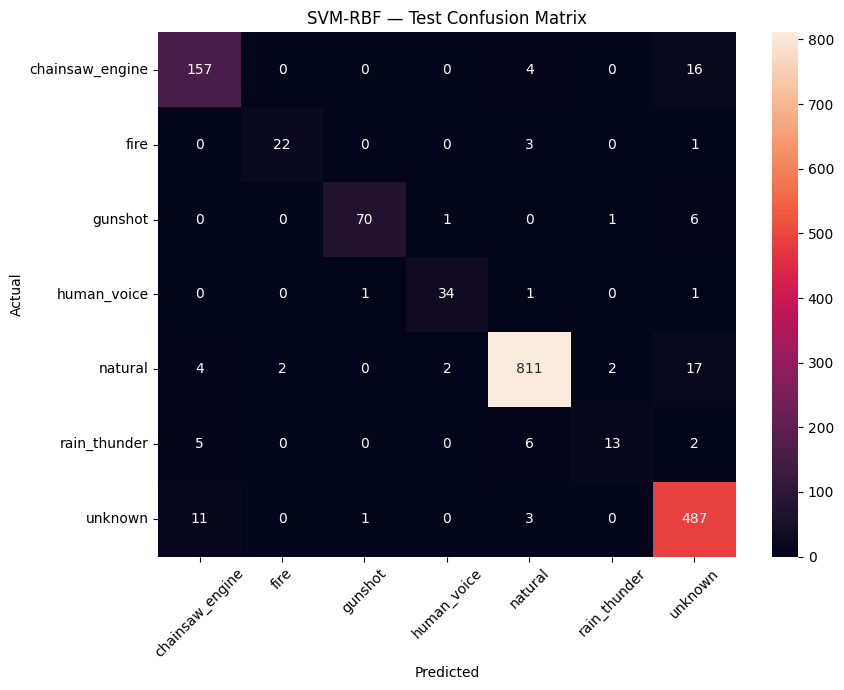

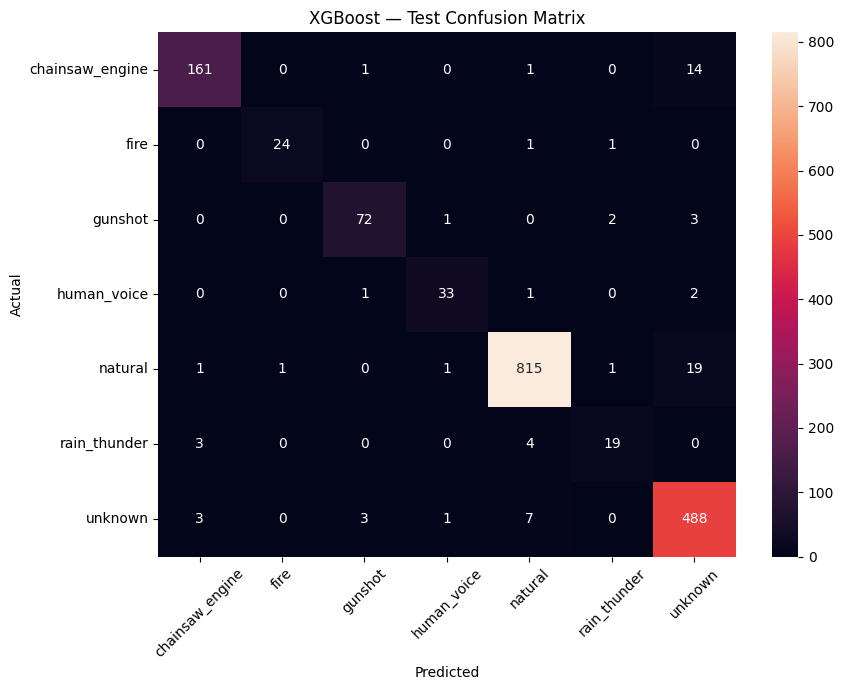

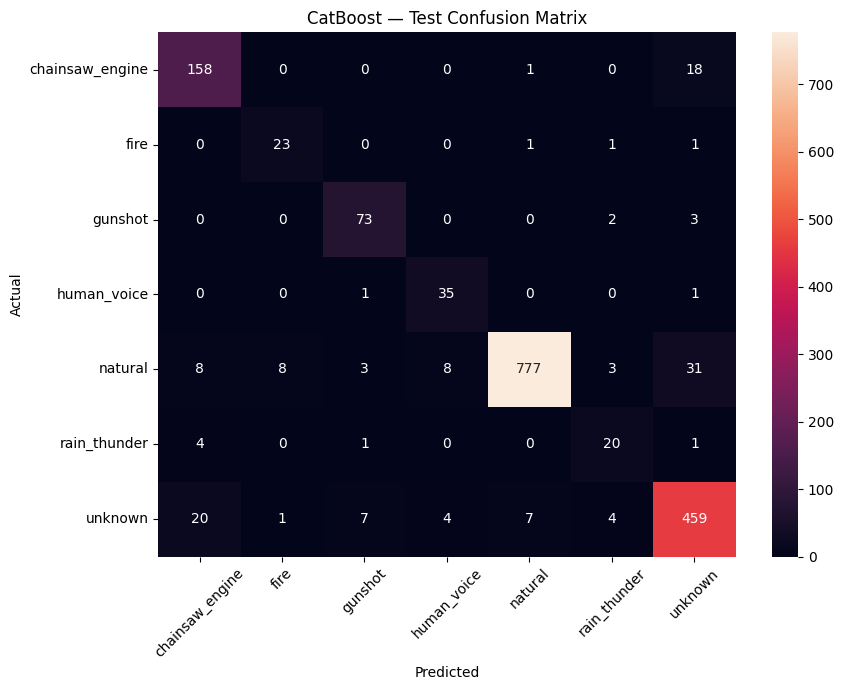

In [33]:
# ==============================================================================
# CONFUSION MATRICES
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

for name, model in final_models.items():

    test_pred = model.predict(X_test)

    test_pred = np.asarray(
        test_pred
    ).astype(int).ravel()

    cm = confusion_matrix(
        y_test,
        test_pred
    )

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(f"{name} — Test Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 💾 3.9 — Save All Models to `models/` Directory

Every final model from Developer B is saved to `/kaggle/working/models/` alongside a `_config.json` with full provenance.

Each saved object is a plain `sklearn Pipeline` (or native model) that can be reloaded with a single `joblib.load()` call and used for inference immediately.

| File | Contents |
|---|---|
| `svm_rbf.joblib` | Final SVM Pipeline (StandardScaler → SVC) |
| `svm_rbf_config.json` | Hyperparams, val macro-F1, class list, versions |
| `xgboost.joblib` | Final XGBClassifier |
| `xgboost_config.json` | Hyperparams, best iteration, val macro-F1, versions |
| `catboost.joblib` | Final CatBoostClassifier |
| `catboost_config.json` | Hyperparams, best iteration, val macro-F1, versions |


In [34]:
# ==============================================================================
# SECTION 3.9 — SAVE ALL DEVELOPER B MODELS TO models/ DIRECTORY
# ==============================================================================
# Every final model is saved with joblib + a companion _config.json.
# The models/ directory is shared with Developer A so all 6 models live together.
# ==============================================================================

import os
import json
import joblib
import sklearn
from datetime import datetime

try:
    import xgboost
    XGB_VERSION = xgboost.__version__
except Exception:
    XGB_VERSION = "unknown"

try:
    import catboost
    CAT_VERSION = catboost.__version__
except Exception:
    CAT_VERSION = "unknown"

MODEL_DIR = "/kaggle/working/models"
os.makedirs(MODEL_DIR, exist_ok=True)

# ------------------------------------------------------------------
# Helper: save model + config
# ------------------------------------------------------------------
def save_model(name, model, config):
    model_path  = os.path.join(MODEL_DIR, f"{name}.joblib")
    config_path = os.path.join(MODEL_DIR, f"{name}_config.json")
    joblib.dump(model, model_path, compress=3)
    with open(config_path, "w") as f:
        json.dump(config, f, indent=2, default=str)
    print(f"  ✅ Saved  {name:<20} -> {model_path}")
    print(f"     Config             -> {config_path}")

print("=" * 70)
print("SAVING DEVELOPER B MODELS")
print("=" * 70)

# ------------------------------------------------------------------
# 1. SVM — RBF
# ------------------------------------------------------------------
svm_config = {
    "model_name"    : "svm_rbf",
    "owner"         : "Developer B — Eng. Jomanah",
    "kernel"        : "rbf",
    "C"             : best_svm["C"],
    "gamma"         : str(best_svm["gamma"]),
    "class_weight"  : "balanced",
    "val_macro_f1"  : round(float(best_svm["val_macro_f1"]), 4),
    "class_names"   : CLASS_LIST,
    "train_folds"   : "2-9",
    "val_fold"      : 1,
    "sample_rate"   : 16000,
    "window_samples": 48000,
    "sklearn_version": sklearn.__version__,
    "created"       : datetime.now().isoformat(timespec="seconds"),
    "api"           : "pipeline.predict(X) / pipeline.predict_proba(X)",
}
save_model("svm_rbf", FINAL_SVM, svm_config)

# ------------------------------------------------------------------
# 2. XGBoost
# ------------------------------------------------------------------
xgb_config = {
    "model_name"    : "xgboost",
    "owner"         : "Developer B — Eng. Jomanah",
    "best_params"   : {k: v for k, v in best_xgb.items() if k != "val_macro_f1"},
    "val_macro_f1"  : round(float(best_xgb_score), 4),
    "class_names"   : CLASS_LIST,
    "train_folds"   : "2-9",
    "val_fold"      : 1,
    "sample_rate"   : 16000,
    "window_samples": 48000,
    "xgboost_version": XGB_VERSION,
    "sklearn_version": sklearn.__version__,
    "created"       : datetime.now().isoformat(timespec="seconds"),
    "api"           : "model.predict(X) / model.predict_proba(X)",
}
save_model("xgboost", FINAL_XGB, xgb_config)

# ------------------------------------------------------------------
# 3. CatBoost
# ------------------------------------------------------------------
cat_config = {
    "model_name"    : "catboost",
    "owner"         : "Developer B — Eng. Jomanah",
    "best_params"   : {k: v for k, v in best_cat.items() if k != "val_macro_f1"},
    "val_macro_f1"  : round(float(best_cat_score), 4),
    "class_names"   : CLASS_LIST,
    "train_folds"   : "2-9",
    "val_fold"      : 1,
    "sample_rate"   : 16000,
    "window_samples": 48000,
    "catboost_version": CAT_VERSION,
    "sklearn_version": sklearn.__version__,
    "created"       : datetime.now().isoformat(timespec="seconds"),
    "api"           : "model.predict(X) / model.predict_proba(X)",
}
save_model("catboost", FINAL_CAT, cat_config)

# ------------------------------------------------------------------
# Summary: list everything now in models/
# ------------------------------------------------------------------
print()
print("=" * 70)
print("ALL MODELS IN models/ DIRECTORY")
print("=" * 70)
all_files = sorted(os.listdir(MODEL_DIR))
for fname in all_files:
    fpath = os.path.join(MODEL_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname:<40}  {size_kb:>8.1f} KB")
print(f"\nTotal files: {len(all_files)}")


SAVING DEVELOPER B MODELS
  ✅ Saved  svm_rbf              -> /kaggle/working/models/svm_rbf.joblib
     Config             -> /kaggle/working/models/svm_rbf_config.json
  ✅ Saved  xgboost              -> /kaggle/working/models/xgboost.joblib
     Config             -> /kaggle/working/models/xgboost_config.json
  ✅ Saved  catboost             -> /kaggle/working/models/catboost.joblib
     Config             -> /kaggle/working/models/catboost_config.json

ALL MODELS IN models/ DIRECTORY
  catboost.joblib                             9547.7 KB
  catboost_config.json                           0.6 KB
  lightgbm.joblib                             4053.4 KB
  lightgbm_config.json                           1.0 KB
  logistic_regression.joblib                    25.2 KB
  logistic_regression_config.json                0.7 KB
  random_forest.joblib                       23879.8 KB
  random_forest_config.json                      0.9 KB
  svm_rbf.joblib                             13003.5 KB
  svm_

---

## 🔬 3.8 — Additional Analysis (Developer B Responsibilities)

The following three sub-sections cover the additional deliverables assigned to Developer B:
XGBoost feature importance, detailed error analysis, and real-time latency profiling.


### 📊 3.8A — XGBoost Feature Importance

XGBoost's built-in `feature_importances_` (gain-based) shows which of the ~292 acoustic
features contribute most to the boosting ensemble's split decisions.
The **top-20 features** are ranked and plotted.


Top 20 XGBoost features:
                 Feature  Importance
  zero_crossing_rate_min    0.130259
        delta_mfcc_3_std    0.058443
   spectral_centroid_min    0.038820
             mfcc_3_mean    0.025282
              mfcc_1_max    0.023064
  spectral_centroid_mean    0.015444
              mfcc_2_max    0.014834
             mfcc_1_mean    0.011661
       delta_mfcc_20_min    0.011409
      spectral_flux_mean    0.010255
       delta_mfcc_15_min    0.009980
       delta_mfcc_19_std    0.009578
             mfcc_14_std    0.009513
      delta2_mfcc_14_std    0.009379
        delta_mfcc_1_max    0.009165
       delta_mfcc_18_min    0.009158
              mfcc_1_std    0.008904
 zero_crossing_rate_mean    0.008432
spectral_contrast_3_mean    0.008326
       spectral_flux_max    0.008291


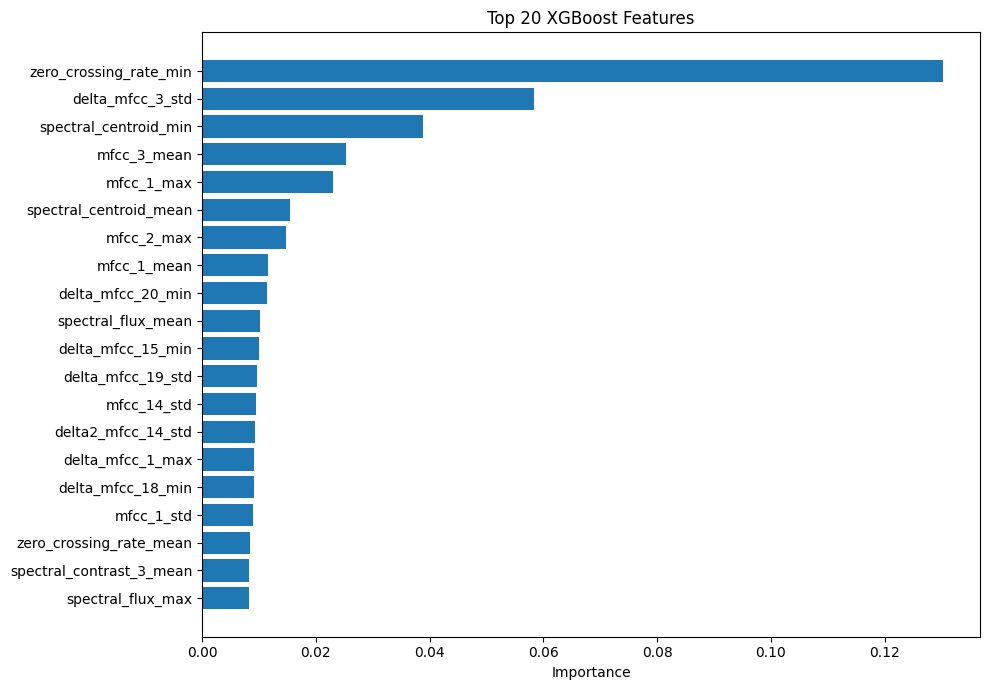

In [35]:
# ==============================================================================
# 6A — XGBOOST FEATURE IMPORTANCE
# ==============================================================================

importance_df = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Importance": FINAL_XGB.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print("Top 20 XGBoost features:")
print(
    importance_df.head(20).to_string(index=False)
)

plt.figure(figsize=(10, 7))

top_features = importance_df.head(20)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Top 20 XGBoost Features")

plt.tight_layout()
plt.show()

### 🔍 3.8B — Error Analysis — Selected Model

Deep dive into where the best-performing model makes mistakes:

- **Classification report** — per-class precision, recall, F1-score, and support
- **Confusion pair ranking** — the 10 most frequent misclassification pairs, ranked by count

This analysis directly informs the next development iteration: if, for example, `human_voice → natural` is a top confusion pair, adding pitch or formant features should be the first priority in the next feature engineering cycle.


In [36]:
# ==============================================================================
# 6B — SELECTED MODEL ERROR ANALYSIS
# ==============================================================================

selected_model = final_models[SELECTED_MODEL]

selected_pred = selected_model.predict(X_test)

selected_pred = np.asarray(
    selected_pred
).astype(int).ravel()

print(
    classification_report(
        y_test,
        selected_pred,
        target_names=label_encoder.classes_
    )
)

cm = confusion_matrix(
    y_test,
    selected_pred
)

confusion_pairs = []

for i in range(len(CLASS_LIST)):

    for j in range(len(CLASS_LIST)):

        if i != j:

            confusion_pairs.append({
                "Actual": label_encoder.classes_[i],
                "Predicted": label_encoder.classes_[j],
                "Count": cm[i, j]
            })

confusion_pairs = pd.DataFrame(
    confusion_pairs
).sort_values(
    "Count",
    ascending=False
)

print("\nMost frequent confusion pairs:")
print(
    confusion_pairs.head(10).to_string(index=False)
)

                 precision    recall  f1-score   support

chainsaw_engine       0.96      0.91      0.93       177
           fire       0.96      0.92      0.94        26
        gunshot       0.94      0.92      0.93        78
    human_voice       0.92      0.89      0.90        37
        natural       0.98      0.97      0.98       838
   rain_thunder       0.83      0.73      0.78        26
        unknown       0.93      0.97      0.95       502

       accuracy                           0.96      1684
      macro avg       0.93      0.90      0.92      1684
   weighted avg       0.96      0.96      0.96      1684


Most frequent confusion pairs:
         Actual       Predicted  Count
        natural         unknown     19
chainsaw_engine         unknown     14
        unknown         natural      7
   rain_thunder         natural      4
        gunshot         unknown      3
   rain_thunder chainsaw_engine      3
        unknown chainsaw_engine      3
        unknown         gu

### ⏱️ 3.8C — Latency Measurement (Real-Time Streaming Constraint)

The deployment target is a **real-time streaming pipeline** that must process one 3-second audio window and produce a prediction before the next window arrives.

This cell measures end-to-end latency on **200 test clips**, decomposed into two phases:

| Phase | What is timed |
|---|---|
| **Feature extraction** | `librosa` MFCC + all spectral descriptors for one 3s window |
| **Model inference** | `model.predict()` call on the resulting feature vector |
| **Total** | Feature extraction + inference combined |

Statistics reported: **Mean · P50 · P95 · P99 · Max**

> The **P95 / P99 tail latencies** are the operationally relevant figures for a real-time > deployment — worst-case behaviour determines whether the system can keep up with the audio stream.


In [37]:
# ==============================================================================
# 6C — FEATURE EXTRACTION + INFERENCE LATENCY
# ==============================================================================

import soundfile as sf

latency_rows = []

test_metadata = metadata_df[
    metadata_df["split"] == "test"
].drop_duplicates(
    subset=["clip_id"]
).head(200)

print(
    f"Measuring latency on {len(test_metadata)} test clips..."
)

for _, row in test_metadata.iterrows():

    try:

        # --------------------------------------------------------------
        # Load audio
        # --------------------------------------------------------------

        wav, sr = sf.read(
            row["file_path"]
        )

        if wav.ndim > 1:
            wav = np.mean(
                wav,
                axis=1
            )

        # --------------------------------------------------------------
        # Feature extraction
        # --------------------------------------------------------------

        feature_start = time.perf_counter()

        frame_features = extract_frame_level_features(
            wav,
            sr
        )

        feature_vector = aggregate_features(
            frame_features
        )

        feature_df = pd.DataFrame(
            [feature_vector]
        )

        feature_df = feature_df.reindex(
            columns=FEATURE_COLUMNS,
            fill_value=0
        )

        feature_time = (
            time.perf_counter()
            - feature_start
        ) * 1000

        # --------------------------------------------------------------
        # Model inference
        # --------------------------------------------------------------

        inference_start = time.perf_counter()

        selected_model.predict(
            feature_df.values
        )

        inference_time = (
            time.perf_counter()
            - inference_start
        ) * 1000

        total_time = (
            feature_time
            + inference_time
        )

        latency_rows.append({
            "feature_extraction_ms": feature_time,
            "inference_ms": inference_time,
            "total_ms": total_time
        })

    except Exception as e:

        print(
            f"Latency failed for {row['clip_id']}: {e}"
        )


latency_df = pd.DataFrame(
    latency_rows
)

print("\n" + "=" * 80)
print("LATENCY RESULTS")
print("=" * 80)

if len(latency_df) > 0:

    for column in latency_df.columns:

        print(
            f"\n{column}"
        )

        print(
            f"Mean : {latency_df[column].mean():.2f} ms"
        )

        print(
            f"P50  : {latency_df[column].quantile(0.50):.2f} ms"
        )

        print(
            f"P95  : {latency_df[column].quantile(0.95):.2f} ms"
        )

        print(
            f"P99  : {latency_df[column].quantile(0.99):.2f} ms"
        )

        print(
            f"Max  : {latency_df[column].max():.2f} ms"
        )

else:

    print("No latency results were collected.")

Measuring latency on 200 test clips...

LATENCY RESULTS

feature_extraction_ms
Mean : 41.53 ms
P50  : 40.54 ms
P95  : 53.70 ms
P99  : 56.14 ms
Max  : 63.21 ms

inference_ms
Mean : 8.80 ms
P50  : 7.68 ms
P95  : 21.09 ms
P99  : 22.62 ms
Max  : 31.13 ms

total_ms
Mean : 50.33 ms
P50  : 48.26 ms
P95  : 74.13 ms
P99  : 76.43 ms
Max  : 77.33 ms


---

# 🧠 Part 4 — Deep Learning Track
### Eng. Mohamed Mansour — Deep Learning Lead

---

## Overview

| Model | Input | Core Idea |
|---|---|---|
| **CRNN** | Log-Mel Spectrogram (64×T) | CNN extracts per-frame features → Bidirectional GRU reads them as a time sequence |

**Why spectrograms?** A log-mel spectrogram is a 2D matrix (time × mel frequency, brightness = energy). Gunshots appear as vertical broadband bursts, chainsaws as periodic low-frequency striping, rain as uniform texture. A CNN frontend captures these spatial patterns, while the subsequent bidirectional GRU models how the sound evolves over time — giving CRNN the best of both worlds.


## ⚙️ Section 1 — Setup & Shared Utilities
### *Owner: Eng. Mohamed Mansour — Deep Learning Lead*

Imports, constants, fixed seeds, DataLoaders (train = folds 2–9, val = fold 1, test = fold 0 frozen), class weights from the training split only, and the shared `train_one_epoch` / `validate` / `log_experiment` helpers used across all deep learning experiments.

| Input | Output |
|---|---|
| `metadata.csv`, `processed_audio/` | `train_loader`, `val_loader`, `test_loader`, `class_weights`, training utilities |


In [43]:
# ============================================================
# Setup & Shared Utilities
# Owner: Eng. Mohamed Mansour — Deep Learning Lead
# Input : /kaggle/working/metadata.csv, ForestDataset (defined earlier)
# Output: DataLoaders, class_weights, train/validate helpers, experiment logger
# ============================================================

import os, json, time, random, warnings, datetime
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as tvmodels
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SAMPLE_RATE = 16_000
WINDOW_SAMPLES = 48_000
N_MELS = 64
N_FFT = 512
HOP_LENGTH = 160
IMG_SIZE = 224
NUM_CLASSES = 7
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_LIST = sorted(["natural", "rain_thunder", "gunshot",
                     "fire", "chainsaw_engine", "human_voice", "unknown"])
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_LIST)}
DEEP_MODEL_DIR = "/kaggle/working/models/deep"
EXP_LOG_PATH = "/kaggle/working/deep_experiments_log.csv"
os.makedirs(DEEP_MODEL_DIR, exist_ok=True)


def fix_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


fix_seeds()

# ---- Data -------------------------------------------------------
metadata_df = pd.read_csv("/kaggle/working/metadata.csv")

train_ds = ForestDataset(metadata_df, split="train")   # folds 2-9
val_ds   = ForestDataset(metadata_df, split="val")     # fold 1
test_ds  = ForestDataset(metadata_df, split="test")    # fold 0 (frozen)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

# ---- Class weights (training split only) ------------------------
y_train_np = metadata_df.loc[metadata_df["split"] == "train", "class"].map(CLASS_TO_IDX).values
class_weights = torch.tensor(
    compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train_np),
    dtype=torch.float32,
).to(DEVICE)

print(f"Device: {DEVICE}")
print(f"train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")
print("Class weights:", dict(zip(CLASS_LIST, class_weights.cpu().numpy().round(3))))


# ---- Shared train / validate -----------------------------------
def _batch_inputs(batch, model_key):
    if model_key == "mobilenet":
        return batch["logmel_img"].to(DEVICE)
    return batch["logmel"].unsqueeze(1).to(DEVICE)


def train_one_epoch(model, loader, optimizer, criterion, device, model_key="cnn", clip_norm=None):
    model.train()
    total_loss, preds, labels = 0.0, [], []
    for batch in loader:
        x = _batch_inputs(batch, model_key)
        y = batch["label"].to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        if clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
        optimizer.step()
        total_loss += loss.item() * len(y)
        preds += logits.argmax(1).cpu().tolist()
        labels += y.cpu().tolist()
    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(labels, preds, average="macro", labels=list(range(NUM_CLASSES)), zero_division=0)
    return avg_loss, macro_f1


@torch.no_grad()
def validate(model, loader, criterion, device, model_key="cnn"):
    model.eval()
    total_loss, preds, labels = 0.0, [], []
    for batch in loader:
        x = _batch_inputs(batch, model_key)
        y = batch["label"].to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * len(y)
        preds += logits.argmax(1).cpu().tolist()
        labels += y.cpu().tolist()
    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(labels, preds, average="macro", labels=list(range(NUM_CLASSES)), zero_division=0)
    return avg_loss, macro_f1


# ---- Experiment logger -----------------------------------------
def log_experiment(model_name, epoch, config, val_macro_f1):
    row = {
        "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
        "model": model_name,
        "epoch": epoch,
        "config": json.dumps(config, default=str, sort_keys=True),
        "val_macro_f1": round(float(val_macro_f1), 4),
    }
    pd.DataFrame([row]).to_csv(EXP_LOG_PATH, mode="a", index=False,
                               header=not os.path.exists(EXP_LOG_PATH))


print("Section 1 ready.")


Device: cuda
train: 13471 | val: 1679 | test: 1684
Class weights: {'chainsaw_engine': np.float32(1.1), 'fire': np.float32(8.553), 'gunshot': np.float32(3.388), 'human_voice': np.float32(5.201), 'natural': np.float32(0.288), 'rain_thunder': np.float32(16.881), 'unknown': np.float32(0.51)}
Section 1 ready.


## 🧠 Section 2 — CRNN (CNN + Bidirectional GRU)
### *Owner: Eng. Mohamed Mansour — Deep Learning Lead*

A CNN frontend compresses the mel axis per frame, then a 2-layer bidirectional GRU models the sequence over time before a linear classifier produces the final class probabilities.

| Input | Architecture | Output |
|---|---|---|
| `(batch, 1, 64, T)` log-mel spectrogram | Conv2D × 3 → MaxPool × 2 → BiGRU(2×256) → Linear(512, 7) | `(batch, 7)` class logits |

Training uses `ReduceLROnPlateau` scheduling and early stopping (patience = 5 epochs) on validation macro-F1.


[CRNN] ep 01 | tr_loss 1.0545 tr_f1 0.4682 | va_loss 0.7852 va_f1 0.6650
[CRNN] ep 02 | tr_loss 0.6424 tr_f1 0.6623 | va_loss 0.4951 va_f1 0.7486
[CRNN] ep 03 | tr_loss 0.4891 tr_f1 0.7377 | va_loss 0.4914 va_f1 0.7762
[CRNN] ep 04 | tr_loss 0.3919 tr_f1 0.7808 | va_loss 0.4980 va_f1 0.7558
[CRNN] ep 05 | tr_loss 0.3242 tr_f1 0.8218 | va_loss 0.3113 va_f1 0.8120
[CRNN] ep 06 | tr_loss 0.2640 tr_f1 0.8405 | va_loss 0.4618 va_f1 0.8336
[CRNN] ep 07 | tr_loss 0.2333 tr_f1 0.8620 | va_loss 0.5266 va_f1 0.8227
[CRNN] ep 08 | tr_loss 0.2094 tr_f1 0.8771 | va_loss 0.5230 va_f1 0.8482
[CRNN] ep 09 | tr_loss 0.1843 tr_f1 0.8804 | va_loss 0.4497 va_f1 0.8672


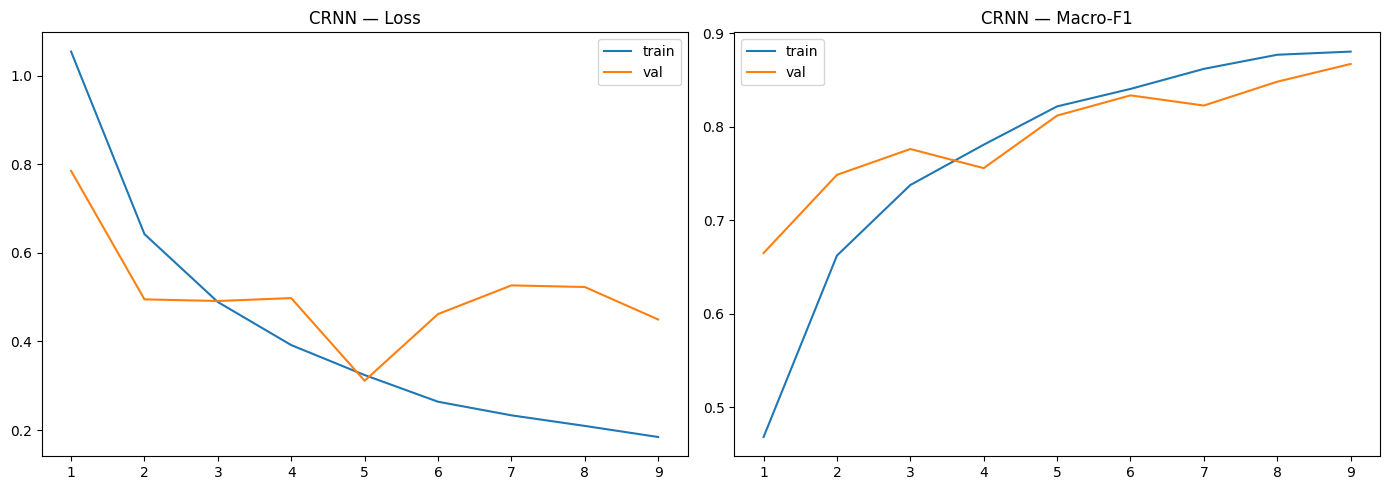

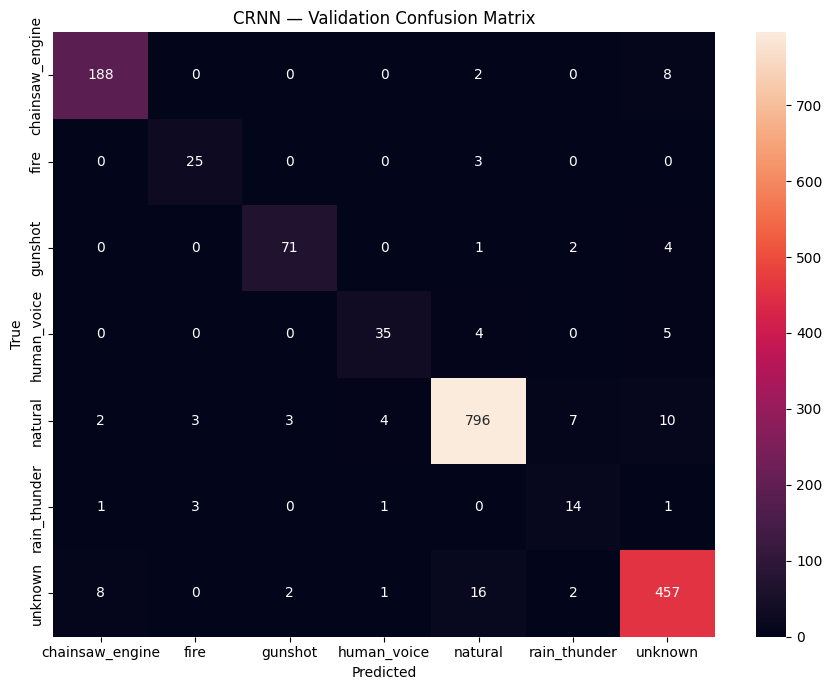

                 precision    recall  f1-score   support

chainsaw_engine       0.94      0.95      0.95       198
           fire       0.81      0.89      0.85        28
        gunshot       0.93      0.91      0.92        78
    human_voice       0.85      0.80      0.82        44
        natural       0.97      0.96      0.97       825
   rain_thunder       0.56      0.70      0.62        20
        unknown       0.94      0.94      0.94       486

       accuracy                           0.94      1679
      macro avg       0.86      0.88      0.87      1679
   weighted avg       0.95      0.94      0.95      1679



In [44]:
# ============================================================
# Section 4 — Model C: CRNN
# Owner: Eng. Mohamed Mansour — Deep Learning Lead
# Input : train_loader / val_loader (logmel, (B,1,64,T))
# Output: /kaggle/working/models/deep/crnn_best.pt, crnn_config.json
# ============================================================

class CRNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)),
        )
        self.gru = nn.GRU(input_size=128 * 16, hidden_size=256, num_layers=2,
                          batch_first=True, dropout=0.3, bidirectional=True)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        f = self.cnn(x)                       # (B, 128, 16, T)
        b, c, h, t = f.shape
        f = f.permute(0, 3, 1, 2).reshape(b, t, c * h)  # (B, T, 128*16)
        out, _ = self.gru(f)
        return self.fc(out.mean(dim=1))


fix_seeds()
crnn = CRNN().to(DEVICE)
opt_crnn = optim.Adam(crnn.parameters(), lr=5e-4)
crnn_criterion = nn.CrossEntropyLoss(weight=class_weights)
crnn_sched = optim.lr_scheduler.ReduceLROnPlateau(opt_crnn, mode="max", patience=5, factor=0.5)

crnn_hist, best_f1, best_epoch, wait = [], -1.0, 0, 0
crnn_ckpt = os.path.join(DEEP_MODEL_DIR, "crnn_best.pt")

for epoch in range(1, 10):
    tr_loss, tr_f1 = train_one_epoch(crnn, train_loader, opt_crnn, crnn_criterion, DEVICE,
                                     "cnn", clip_norm=1.0)
    va_loss, va_f1 = validate(crnn, val_loader, crnn_criterion, DEVICE, "cnn")
    crnn_sched.step(va_f1)
    crnn_hist.append({"epoch": epoch, "tr_loss": tr_loss, "tr_f1": tr_f1,
                      "va_loss": va_loss, "va_f1": va_f1})
    log_experiment("crnn", epoch, {"lr": 5e-4}, va_f1)
    print(f"[CRNN] ep {epoch:02d} | tr_loss {tr_loss:.4f} tr_f1 {tr_f1:.4f} | "
          f"va_loss {va_loss:.4f} va_f1 {va_f1:.4f}")
    if va_f1 > best_f1:
        best_f1, best_epoch, wait = va_f1, epoch, 0
        torch.save(crnn.state_dict(), crnn_ckpt)
    else:
        wait += 1
        if wait >= 5:
            print(f"Early stopping at epoch {epoch}.")
            break

crnn_hist = pd.DataFrame(crnn_hist)
crnn.load_state_dict(torch.load(crnn_ckpt, map_location=DEVICE))

with open(os.path.join(DEEP_MODEL_DIR, "crnn_config.json"), "w") as f:
    json.dump({"model_name": "crnn", "architecture": "CNN(128x16) + BiGRU(2x256) + Linear(512,7)",
               "val_macro_f1": round(float(best_f1), 4), "best_epoch": best_epoch,
               "optimizer": "Adam", "learning_rate": 5e-4, "input_shape": "(1, 64, T)"}, f, indent=2)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(crnn_hist["epoch"], crnn_hist["tr_loss"], label="train")
ax[0].plot(crnn_hist["epoch"], crnn_hist["va_loss"], label="val")
ax[0].set_title("CRNN — Loss"); ax[0].legend()
ax[1].plot(crnn_hist["epoch"], crnn_hist["tr_f1"], label="train")
ax[1].plot(crnn_hist["epoch"], crnn_hist["va_f1"], label="val")
ax[1].set_title("CRNN — Macro-F1"); ax[1].legend()
plt.tight_layout(); plt.show()

y_true, y_pred = collect_preds(crnn, val_loader, "cnn")
cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_LIST, yticklabels=CLASS_LIST)
plt.title("CRNN — Validation Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()
print(classification_report(y_true, y_pred, target_names=CLASS_LIST, zero_division=0))


## 📊 Section 3 — Model Summary & Selection
### *Owner: Eng. Mohamed Mansour — Deep Learning Lead*

Summarises the trained CRNN on the **validation set** — macro-F1, accuracy, and parameter count — and selects it as the model to carry forward to final test-set evaluation. The test set is not touched at this stage.


,Model,Val Macro-F1,Val Accuracy,Parameters
0,CRNN,0.8672,0.9446,"4,821,447"


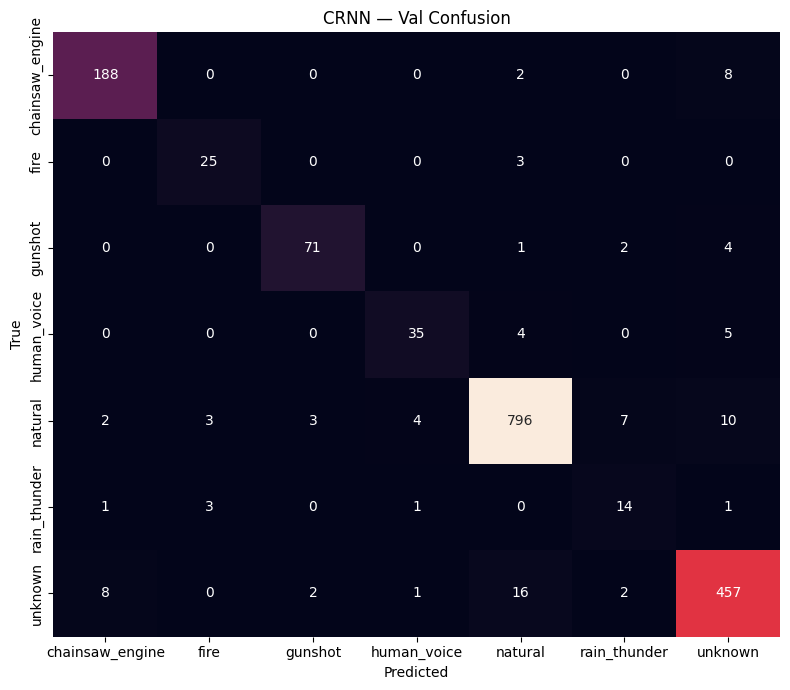

✅ Selected model: CRNN with val macro-F1 = 0.8672


In [45]:
# ============================================================
# Section 5 — Model Comparison & Selection
# Owner: Eng. Mohamed Mansour — Deep Learning Lead
# Input : trained model crnn + val_loader
# Output: comparison table, confusion matrix, selected model name
# ============================================================

def n_params(m):
    return sum(p.numel() for p in m.parameters())

candidates = {
    "CRNN": (crnn, "cnn"),
}

rows, cms = [], {}
for name, (m, key) in candidates.items():
    y_true, y_pred = collect_preds(m, val_loader, key)
    rows.append({
        "Model": name,
        "Val Macro-F1": round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "Val Accuracy": round((y_true == y_pred).mean(), 4),
        "Parameters": f"{n_params(m):,}",
    })
    cms[name] = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))

summary_df = pd.DataFrame(rows)
display(summary_df)

fig, axes = plt.subplots(1, 1, figsize=(8, 7))
axes = [axes]
for ax, (name, cm) in zip(axes, cms.items()):
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, ax=ax,
                xticklabels=CLASS_LIST, yticklabels=CLASS_LIST)
    ax.set_title(f"{name} — Val Confusion"); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()

best_row = summary_df.loc[summary_df["Val Macro-F1"].idxmax()]
SELECTED_DEEP = best_row["Model"]
print(f"✅ Selected model: {SELECTED_DEEP} with val macro-F1 = {best_row['Val Macro-F1']}")


## 🧪 Section 4 — Final Evaluation on Frozen Test Set
### *Owner: Eng. Mohamed Mansour — Deep Learning Lead*

> ⚠️ **This is the only place `fold = 0` (test) is ever accessed.**
> Results produced here are the definitive figures reported in the project model card.

Loads the best CRNN checkpoint, wraps it in the shared `predict(window) -> dict[class, prob]` API, and runs the evaluation harness from Step 6 (Israa): confusion matrix, ROC / PR curves, and robustness under additive noise.


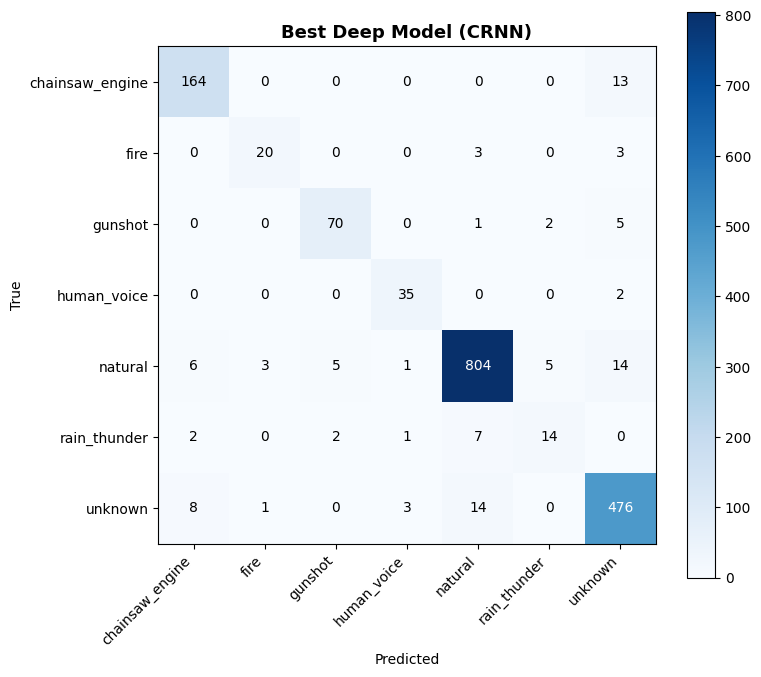


Classification Report:
                 precision    recall  f1-score   support

chainsaw_engine       0.91      0.93      0.92       177
           fire       0.83      0.77      0.80        26
        gunshot       0.91      0.90      0.90        78
    human_voice       0.88      0.95      0.91        37
        natural       0.97      0.96      0.96       838
   rain_thunder       0.67      0.54      0.60        26
        unknown       0.93      0.95      0.94       502

       accuracy                           0.94      1684
      macro avg       0.87      0.86      0.86      1684
   weighted avg       0.94      0.94      0.94      1684

Macro-F1: 0.8613


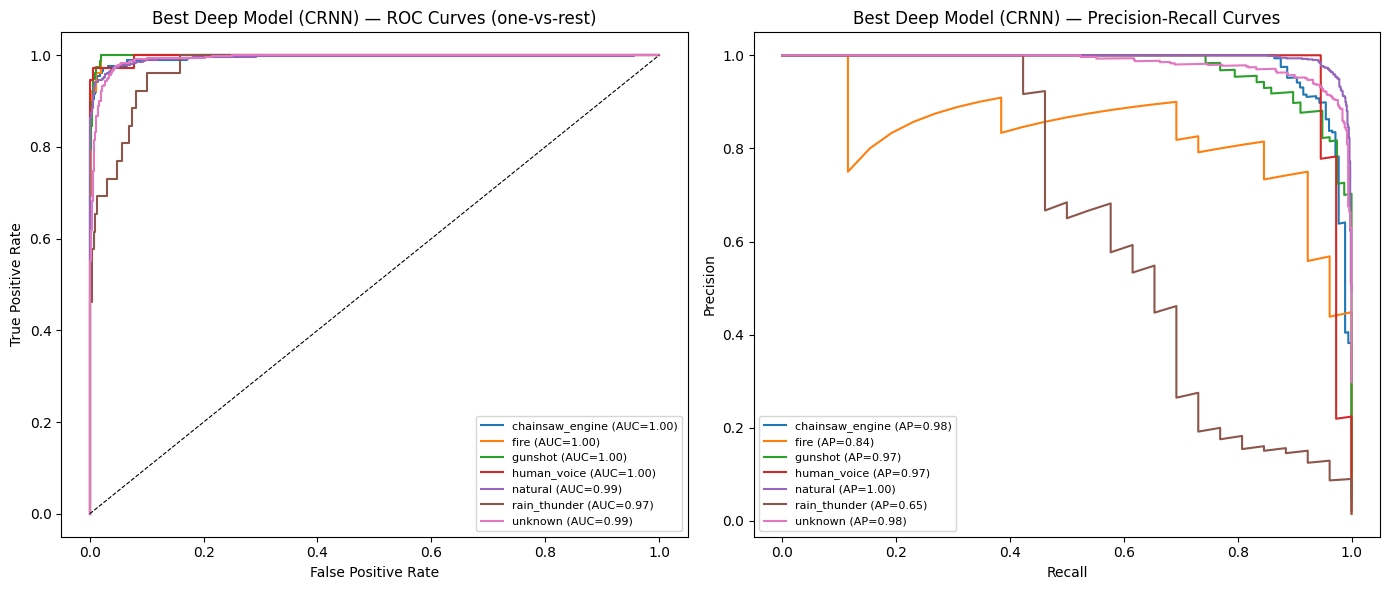

  SNR  20 dB -> accuracy: 0.9400 (n=200)
  SNR  10 dB -> accuracy: 0.9300 (n=200)
  SNR   5 dB -> accuracy: 0.8900 (n=200)


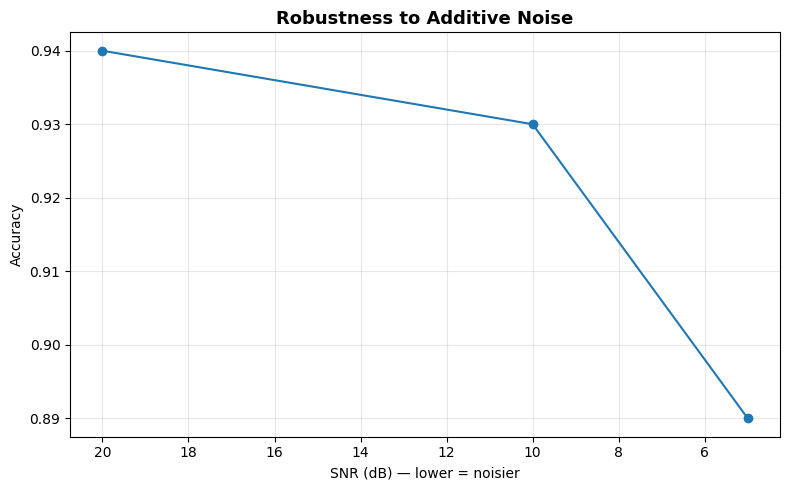


🏁 FINAL TEST MACRO-F1 (CRNN): 0.8613


In [46]:
# ============================================================
# Section 6 — Final Evaluation on Frozen Test Set
# Owner: Eng. Mohamed Mansour — Deep Learning Lead
# Input : best deep checkpoint on disk, metadata_df (fold 0 used ONLY here)
# Output: predict() API, test macro-F1, harness plots
# ============================================================

CKPT_MAP = {
    "CRNN": (CRNN, "crnn_best.pt", "cnn"),
}

cls_ctor, ckpt_name, model_key = CKPT_MAP[SELECTED_DEEP]
best_model = cls_ctor().to(DEVICE)
best_model.load_state_dict(torch.load(os.path.join(DEEP_MODEL_DIR, ckpt_name), map_location=DEVICE))
best_model.eval()


@torch.no_grad()
def predict(window: np.ndarray) -> dict:
    """Shared API: 48000-sample float waveform -> {class_name: probability}."""
    w = np.asarray(window, dtype=np.float32)
    if len(w) < WINDOW_SAMPLES:
        w = np.pad(w, (0, WINDOW_SAMPLES - len(w)))
    w = w[:WINDOW_SAMPLES]
    log_mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=w, sr=SAMPLE_RATE, n_fft=1024,
                                       hop_length=320, n_mels=N_MELS),
        ref=np.max).astype(np.float32)
    x = torch.from_numpy(log_mel).unsqueeze(0).unsqueeze(0).to(DEVICE)
    probs = torch.softmax(best_model(x), dim=1)[0].cpu().numpy()
    return {c: float(p) for c, p in zip(CLASS_LIST, probs)}


test_results = run_model_on_test_set(predict, metadata_df, split="test")
plot_confusion_matrix(test_results, title=f"Best Deep Model ({SELECTED_DEEP})")
plot_roc_pr_curves(test_results, title_prefix=f"Best Deep Model ({SELECTED_DEEP})")
robustness_df = evaluate_noise_robustness(predict, metadata_df)

test_macro_f1 = f1_score(test_results["true_class"], test_results["pred_class"],
                         average="macro", labels=CLASS_LIST, zero_division=0)
print(f"\n🏁 FINAL TEST MACRO-F1 ({SELECTED_DEEP}): {test_macro_f1:.4f}")


## 💾 Section 5 — Save Deep Learning Model
### *Owner: Eng. Mohamed Mansour — Deep Learning Lead*

Writes the final standardised `_config.json` for the CRNN checkpoint in `models/deep/`, then lists all files in that directory.

| File | Contents |
|---|---|
| `crnn_best.pt` | Best CRNN weights (saved during training when val macro-F1 improved) |
| `crnn_config.json` | Architecture, hyperparams, val macro-F1, class list, versions |


In [49]:
# ============================================================
# Section 7 — Save All Deep Models
# Owner: Eng. Mohamed Mansour — Deep Learning Lead
# Input : checkpoints + per-model metrics from Section 4
# Output: standardized *_config.json for each model, directory listing
# ============================================================

created_ts = datetime.datetime.now().isoformat(timespec="seconds")
API_STR = "predict(window: np.ndarray[48000]) -> dict[class, prob]"

specs = {
    "crnn": dict(model_name="CRNN", architecture="CNN + BiGRU(2x256) + Linear(512,7)",
                 val_macro_f1=round(float(best_f1), 4), best_epoch=int(best_epoch),
                 learning_rate=5e-4, input_shape="(1, 64, T)"),
}

for fname, s in specs.items():
    cfg = {
        "model_name": s["model_name"],
        "owner": "Deep Learning Lead — Eng. Mohamed Mansour",
        "architecture": s["architecture"],
        "val_macro_f1": s["val_macro_f1"],
        "best_epoch": s["best_epoch"],
        "optimizer": "Adam",
        "learning_rate": s["learning_rate"],
        "class_names": CLASS_LIST,
        "input_shape": s["input_shape"],
        "sample_rate": 16000,
        "window_samples": 48000,
        "created": created_ts,
        "api": API_STR,
    }
    with open(os.path.join(DEEP_MODEL_DIR, f"{fname}_config.json"), "w") as f:
        json.dump(cfg, f, indent=2)

print("Files in models/deep/:")
saved = sorted(os.listdir(DEEP_MODEL_DIR))
for fn in saved:
    mb = os.path.getsize(os.path.join(DEEP_MODEL_DIR, fn)) / (1024 ** 2)
    print(f"  {fn:<30} {mb:8.3f} MB")

print(f"\n{len(saved)} model files saved in models/deep/")


Files in models/deep/:
  cnn2d_best.pt                     0.399 MB
  cnn2d_config.json                 0.000 MB
  crnn_best.pt                     18.404 MB
  crnn_config.json                  0.001 MB

4 model files saved in models/deep/
